# Import libraries/packages

In [ ]:
# import libraries
import numpy as np
import ast
import scipy
import scipy.stats
from sklearn.cluster import KMeans
import pandas as pd
import sys
import os
import string
import argparse
import json
from datetime import datetime
#import pysam
import copy
import collections
from collections import Counter
import time
from math import isnan
import re
import glob
import matplotlib.patches as mpatches
import seaborn as sns
from decimal import Decimal
from functools import partial
from scipy.cluster import hierarchy
from scipy.spatial.distance import hamming
from natsort import natsorted
import pickle
import dill
#import shelve
from io import StringIO
import itertools

#rom ete3 import Tree
#from Bio import Phylo
#from Bio.Phylo.Applications import PhymlCommandline
#from Bio.Phylo.PAML import codeml
#from Bio.Phylo.PhyloXML import Phylogeny
#from sklearn.cluster import AgglomerativeClustering

from scipy.spatial.distance import pdist
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import cophenet

import matplotlib as mpl
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
#import matplotlib.animation as animation
#from matplotlib.animation import FuncAnimation
import matplotlib.patches as patches
import matplotlib.path as path
import matplotlib.colors as mcolors
mpl.rcParams.update(mpl.rcParamsDefault)
#from IPython.display import HTML
from pylab import *
import random as rndom

# Define functions

In [1]:
## Define functions
def save_obj(obj_to_save, dir='', filename='default'):
    if '.dill' not in filename:
        filename=f'{filename}.dill'
    if dir in filename: ## avoid redundant directory calls       
        f = open(f'{filename}', 'wb') 
    else:
        f = open(f'{dir}/{filename}', 'wb') 
    dill.dump(obj_to_save, f)
    return f'{dir}/{filename}'

def load_obj(filename, dir=''):
    if '.dill' not in filename:
        filename=f'{filename}.dill'
    if dir in filename: ## avoid redundant directory calls
        output = dill.load(open(f'{filename}', "rb"))
    else:
        output = dill.load(open(f'{dir}/{filename}', "rb"))
    return output

def sort_A_using_B(A, B, accending=False):
    sorted_A = [x for _, x in sorted(zip(B, A), reverse=accending)].copy()
    return sorted_A

def random_str(number_of_letters):
    result = ''.join(rndom.choices(string.ascii_lowercase, k=number_of_letters))
    return result

## Define verbose printing functions for debugging and log file
def sel_print(x):
    if report_sel_events:
        print(x)
        if Log == True:
            print(x, file = outlog)
    else:
        pass

## Define fuction to make an epiallele that is diploid and randomly methylated
def make_rand_het(L, mode=0.5):
    random_het = []
    for i in range(L):
        A = rndom.choices([0,1], weights=(1-mode, mode), k=1)[0]
        B = rndom.choices([0,1], weights=(1-mode, mode), k=1)[0]
        #A = np.random.randint(2)
        #B = np.random.randint(2)
        random_het.append((A,B))
    return random_het

## Define Selection criteria for Epimutation event 
def epi_selection_event(epiallele_out):
    if epiallele_out[-2] == 1: #epiallele_out[0:3].count(1) > 2: #epiallele.count(1) > 3: #epiallele_out[2] == 1 and
        return True
    else:
        return False

##Define fuction to randomly generate a selection trigger base on last cycle's unique genome ids
def get_sel_trigger(cells_current_cycle):
    winning_genome_epiallele = rndom.choice(cells_current_cycle)
    winning_genome = winning_genome_epiallele[0]
    sel_trigger = winning_genome[-1]
    return sel_trigger

##Define fuction to randomly generate a selection trigger base on last cycle's unique genome ids
def get_sel_trigger_v2(cells_current_cycle, polyclonal=False, primary_clone=None):                
    if not polyclonal and primary_clone != None: ## not polyclonal and primary mutant clone exists (i.e., first selection event has already occurred)
        subclone = False
        while not subclone: ## pick random cells until you find a subclone of the primary clone and the get sel trigger (to trigger mutation)
            winning_genome_epiallele = rndom.choice(cells_current_cycle) # get random cell from current cycle
            winning_genome = winning_genome_epiallele[0] ## Get genome of winning cell
            if primary_clone in winning_genome: ## only allow genome if it IS a decendent (subclone) of the first mutant clone
                subclone = True
    elif polyclonal and primary_clone != None: #polyclonal and primary mutant clone exists (i.e., first selection event has already occurred)
        subclone = True
        while subclone: ## pick random cells until you find a one that is unrelated to the primary clone and get sel trigger (to trigger mutation)
            winning_genome_epiallele = rndom.choice(cells_current_cycle) # get random cell from current cycle
            winning_genome = winning_genome_epiallele[0] ## Get genome of winning cell
            if primary_clone not in winning_genome: ## only allow genome if it IS NOT a decendent (subclone) of the first mutant clone
                subclone = False
    else: ## primary mutant clone does NOT exist (i.e., first selection event has NOT already occurred)
        winning_genome_epiallele = rndom.choice(cells_current_cycle) # get random cell from current cycle
        winning_genome = winning_genome_epiallele[0] ## Get genome of winning cell
    sel_trigger = winning_genome[-1] ## get last record of winning genome
    return sel_trigger

##Define fuction to randomly generate a selection trigger base on last cycle's unique genome ids
def get_sel_trigger_v3(cells_current_cycle, mutant_clone_dict_prior_cycle={}, branching_model=None):
    ## Note that branching models a is handled by get_sel_trigger_v2 (parameters: polyclonal false, selection events=1)
    if len(list(mutant_clone_dict_prior_cycle.keys())) > 0:
        prior_trigs = []
        for k,v in mutant_clone_dict_prior_cycle.items(): ## get selection triggers used in previous cycle
            trigs = [int(e) for e in k.split("_")]
            for trig in trigs:
                if trig not in prior_trigs:
                    prior_trigs.append(trig)
        if branching_model == "b":
            ## pick random cells from set of those that are unrelated to the prior clones and get sel trigger (to trigger mutation)
            winning_genome_epiallele = rndom.choice([e for e in cells_current_cycle if not set(prior_trigs).issubset(set(e[0]))]) # get random cell from current cycle
            winning_genome = winning_genome_epiallele[0] ## Get genome of winning cell
        elif branching_model == "c":
            print('using branching "c"')
            if len(list(mutant_clone_dict_prior_cycle.keys())) < 2: ## treat as if this is the first branch of model "b"
                print(">>>>>>>>>>>>>>>>>>>>>Using C option 1 list(mutant_clone_dict_prior_cycle.keys()):", list(mutant_clone_dict_prior_cycle.keys()))
                ## pick random cells from set of those that are unrelated to the prior clones and get sel trigger (to trigger mutation)
                winning_genome_epiallele = rndom.choice([e for e in cells_current_cycle if not set(prior_trigs).issubset(set(e[0]))]) # get random cell from current cycle
                winning_genome = winning_genome_epiallele[0] ## Get genome of winning cell
            #elif len(mutant_clone_dict_prior_cycle.keys()) > 2: ## first polyclonal branch has already been made, get sel trigger related to only the first clone
            else:
                print(">>>>>>>>>>>>>>>>>>>>>Using C option 2 list(mutant_clone_dict_prior_cycle.keys()):", list(mutant_clone_dict_prior_cycle.keys()))
                primary_clone_key = list(mutant_clone_dict_prior_cycle.keys())[0] ## get key of primary clone (eg: 2_356)
                primary_clone_trigs = [int(e) for e in primary_clone_key.split("_")] ## get individual triggers (eg: [2,356])
                print('primary_clone_trigs:', primary_clone_trigs)
                ## pick random cells from set of cells from the primary clone and the get sel trigger (to trigger mutation)
                list_of_primary_clones = []
                for e in cells_current_cycle:
                    if set(primary_clone_trigs).issubset(set(e[0])):
                        #print('matching genome',e[0])
                        list_of_primary_clones.append(e)
                winning_genome_epiallele = rndom.choice(list_of_primary_clones) # get random cell from current cycle
                winning_genome = winning_genome_epiallele[0] ## Get genome of winning cell
        elif branching_model == "d":
            print(">>>>>>>>>>>>>>>>>>>>>Using d option 1 - mutant_clone_dict_prior_cycle.keys():", list(mutant_clone_dict_prior_cycle.keys()))
            primary_clone_key = list(mutant_clone_dict_prior_cycle.keys())[-1] ## get key of last clone (eg: 2_356)
            primary_clone_trigs = [int(e) for e in primary_clone_key.split("_")] ## get individual triggers (eg: [2,356])
            print('primary_clone_trigs:', primary_clone_trigs)
            ## pick random cells from set of cells from the last clone and the get sel trigger (to trigger mutation)
            list_of_primary_clones = []
            for e in cells_current_cycle:
                if set(primary_clone_trigs).issubset(set(e[0])):
                    #print('matching genome',e[0])
                    list_of_primary_clones.append(e)
            if len(list_of_primary_clones) == 0:
                return "break"
            winning_genome_epiallele = rndom.choice(list_of_primary_clones) # get random cell from current cycle
            winning_genome = winning_genome_epiallele[0] ## Get genome of winning cell
    else: ## primary mutant clone does NOT exist (i.e., first selection event has NOT already occurred)
        winning_genome_epiallele = rndom.choice(cells_current_cycle) # get random cell from current cycle
        winning_genome = winning_genome_epiallele[0] ## Get genome of winning cell
    sel_trigger = winning_genome[-1] ## get last record of winning genome
    return sel_trigger

## Define selection criteria for Somatic event
def is_mutant_cell(genome_in, sel_trigger):
    if sel_trigger in genome_in:
        #print('genome_in', genome_in)
        #print('sel_trigger', sel_trigger)
        return True
    else:
        return False

## Does the cell genome have the one of the selection triggers present (i.e., is it a mutated cell)
def is_mutant_cell_v2(genome_in, sel_triggers, return_trig=False):
    sel_trig_hits = []
    output = False
    for sel_trigger in sel_triggers:
        if sel_trigger == 0:
            continue
        if sel_trigger in genome_in:
            output = True
            if return_trig:
                sel_trig_hits.append(sel_trigger)
            else:
                return True
    if return_trig:
        return output, sel_trig_hits
    else:
        return False

## Define epimutation functions
def epimutate_haploid(epiallele_in, u, g, dt):
    u_prob_mut = u * dt
    g_prob_mut = g * dt
    u_epiallele_idxs = np.where(np.array([(np.random.randint(int(1/u_prob_mut)) + 1) for i in epiallele_in]) == 1)[0].tolist()
    g_epiallele_idxs = np.where(np.array([(np.random.randint(int(1/g_prob_mut)) + 1) for i in epiallele_in]) == 1)[0].tolist()
    cpgs_out = []
    for idx, cpg_i in enumerate(epiallele_in):
        if cpg_i == 1 and idx in g_epiallele_idxs:
            cpg_o = 0
        elif cpg_i == 0 and idx in u_epiallele_idxs:
            cpg_o = 1
        else:
            cpg_o = cpg_i
        cpgs_out.append(cpg_o)
    return cpgs_out

def epimutate_diploid(epiallele_in, u, g, dt):
    u_prob_mut = u * dt
    g_prob_mut = g * dt
    cpgs_mi = list(zip(*epiallele_in))[0]
    cpgs_pi = list(zip(*epiallele_in))[1]
    u_mi_idxs = np.where(np.array([(np.random.randint(int(1/u_prob_mut)) + 1) for i in cpgs_mi]) == 1)[0].tolist()
    u_pi_idxs = np.where(np.array([(np.random.randint(int(1/u_prob_mut)) + 1) for i in cpgs_pi]) == 1)[0].tolist()
    g_mi_idxs = np.where(np.array([(np.random.randint(int(1/g_prob_mut)) + 1) for i in cpgs_mi]) == 1)[0].tolist()
    g_pi_idxs = np.where(np.array([(np.random.randint(int(1/g_prob_mut)) + 1) for i in cpgs_pi]) == 1)[0].tolist()
    cpgs_mo = []
    cpgs_po = []
    for idx, cpg_i in enumerate(cpgs_mi):
        if cpg_i == 1 and idx in g_mi_idxs:
            cpg_o = 0
        elif cpg_i == 0 and idx in u_mi_idxs:
            cpg_o = 1
        else:
            cpg_o = cpg_i
        cpgs_mo.append(cpg_o)
    for idx, cpg_i in enumerate(cpgs_pi):
        if cpg_i == 1 and idx in g_pi_idxs:
            cpg_o = 0
        elif cpg_i == 0 and idx in u_pi_idxs:
            cpg_o = 1
        else:
            cpg_o = cpg_i
        cpgs_po.append(cpg_o)
    cpgs_out = [(cpgs_mo[i], cpgs_po[i]) for i in range(0, len(cpgs_mo))]
    return cpgs_out

def epimutate_diploid_v2(epiallele_in, u, g, dt, paternal_only= False):
    u_prob_mut = u * dt
    g_prob_mut = g * dt
    cpgs_mi = list(zip(*epiallele_in))[0] #maternal epiallele in
    cpgs_pi = list(zip(*epiallele_in))[1] #paternal epiallele in
    u_pi_idxs = np.where(np.array([(np.random.randint(int(1/u_prob_mut)) + 1) for i in cpgs_pi]) == 1)[0].tolist()
    g_pi_idxs = np.where(np.array([(np.random.randint(int(1/g_prob_mut)) + 1) for i in cpgs_pi]) == 1)[0].tolist()
    cpgs_po = []
    for idx, cpg_i in enumerate(cpgs_pi):
        if cpg_i == 1 and idx in g_pi_idxs:
            cpg_o = 0
        elif cpg_i == 0 and idx in u_pi_idxs:
            cpg_o = 1
        else:
            cpg_o = cpg_i
        cpgs_po.append(cpg_o) #paternal epiallele out
    if not paternal_only:
        u_mi_idxs = np.where(np.array([(np.random.randint(int(1/u_prob_mut)) + 1) for i in cpgs_mi]) == 1)[0].tolist()
        g_mi_idxs = np.where(np.array([(np.random.randint(int(1/g_prob_mut)) + 1) for i in cpgs_mi]) == 1)[0].tolist()
        cpgs_mo = []
        for idx, cpg_i in enumerate(cpgs_mi):
            if cpg_i == 1 and idx in g_mi_idxs:
                cpg_o = 0
            elif cpg_i == 0 and idx in u_mi_idxs:
                cpg_o = 1
            else:
                cpg_o = cpg_i
            cpgs_mo.append(cpg_o) #maternal epiallele out
    else:
        cpgs_mo=cpgs_mi #maternal epiallele out = in
    cpgs_out = [(cpgs_mo[i], cpgs_po[i]) for i in range(0, len(cpgs_mo))]
    return cpgs_out


def epimutate_diploid_v3(epiallele_in, u, g, dt, paternal_only= False, maternal_paternal_epimut_ratio=1):
    u_prob_mut = u * dt
    g_prob_mut = g * dt
    cpgs_mi = list(zip(*epiallele_in))[0] #maternal epiallele in
    cpgs_pi = list(zip(*epiallele_in))[1] #paternal epiallele in
    u_pi_idxs = np.where(np.array([(np.random.randint(int(1/u_prob_mut)) + 1) for i in cpgs_pi]) == 1)[0].tolist()
    g_pi_idxs = np.where(np.array([(np.random.randint(int(1/g_prob_mut)) + 1) for i in cpgs_pi]) == 1)[0].tolist()
    cpgs_po = []
    for idx, cpg_i in enumerate(cpgs_pi):
        if cpg_i == 1 and idx in g_pi_idxs:
            cpg_o = 0
        elif cpg_i == 0 and idx in u_pi_idxs:
            cpg_o = 1
        else:
            cpg_o = cpg_i
        cpgs_po.append(cpg_o) #paternal epiallele out
    if not paternal_only:
        u_mi_idxs = np.where(np.array([(np.random.randint(int(1/(u_prob_mut*maternal_paternal_epimut_ratio))) + 1) for i in cpgs_mi]) == 1)[0].tolist()
        g_mi_idxs = np.where(np.array([(np.random.randint(int(1/(g_prob_mut*maternal_paternal_epimut_ratio))) + 1) for i in cpgs_mi]) == 1)[0].tolist()
        cpgs_mo = []
        for idx, cpg_i in enumerate(cpgs_mi):
            if cpg_i == 1 and idx in g_mi_idxs:
                cpg_o = 0
            elif cpg_i == 0 and idx in u_mi_idxs:
                cpg_o = 1
            else:
                cpg_o = cpg_i
            cpgs_mo.append(cpg_o) #maternal epiallele out
    else:
        cpgs_mo=cpgs_mi #maternal epiallele out = in
    cpgs_out = [(cpgs_mo[i], cpgs_po[i]) for i in range(0, len(cpgs_mo))]
    return cpgs_out

def epimutate_diploid_v4(epiallele_in, u, g, dt, paternal_only= False, maternal_paternal_epimut_ratio=1):
    u_prob_mut = u * dt
    g_prob_mut = g * dt
    cpgs_mi = list(zip(*epiallele_in))[0] #maternal epiallele in
    cpgs_pi = list(zip(*epiallele_in))[1] #paternal epiallele in
    u_pi_idxs = np.where(np.array([(np.random.randint(int(1/u_prob_mut)) + 1) for i in cpgs_pi]) == 1)[0].tolist()
    g_pi_idxs = np.where(np.array([(np.random.randint(int(1/g_prob_mut)) + 1) for i in cpgs_pi]) == 1)[0].tolist()
    cpgs_po = []
    meth_cnt = 0
    demeth_cnt = 0
    for idx, cpg_i in enumerate(cpgs_pi):
        if cpg_i == 1 and idx in g_pi_idxs:
            cpg_o = 0
            demeth_cnt +=1
        elif cpg_i == 0 and idx in u_pi_idxs:
            cpg_o = 1
            meth_cnt +=1
        else:
            cpg_o = cpg_i
        cpgs_po.append(cpg_o) #paternal epiallele out
    if not paternal_only:
        u_mi_idxs = np.where(np.array([(np.random.randint(int(1/(u_prob_mut*maternal_paternal_epimut_ratio))) + 1) for i in cpgs_mi]) == 1)[0].tolist()
        g_mi_idxs = np.where(np.array([(np.random.randint(int(1/(g_prob_mut*maternal_paternal_epimut_ratio))) + 1) for i in cpgs_mi]) == 1)[0].tolist()
        cpgs_mo = []
        for idx, cpg_i in enumerate(cpgs_mi):
            if cpg_i == 1 and idx in g_mi_idxs:
                cpg_o = 0
                demeth_cnt +=1
            elif cpg_i == 0 and idx in u_mi_idxs:
                cpg_o = 1
                meth_cnt +=1
            else:
                cpg_o = cpg_i
            cpgs_mo.append(cpg_o) #maternal epiallele out
    else:
        cpgs_mo=cpgs_mi #maternal epiallele out = in
    cpgs_out = [(cpgs_mo[i], cpgs_po[i]) for i in range(0, len(cpgs_mo))]
    return cpgs_out, meth_cnt, demeth_cnt

## Define cell state change per cycle (death, birth, nothing)
def division(B_in, dt):
    r_birth = B_in * dt 
    r_death = 1 * dt 
    r_static = 1-(r_birth+r_death)
    b_out = rndom.choices([1,2,3], weights=(r_static, r_death, r_birth), k=1)# for output b = 1, b = 2, or b = 3 below P(static, death, or birth) (note that choices returns a list with k samplings)
    return b_out[0]

## Define matrix generator from cells lists for given cycle it will be a list of tuples [([gen_1],[epiallele_1]),...([gen_i],[epiallele_i])]
def matrix_from_list(tuple_list, tuple_index):
    ids = []
    out_matrix = []
    for index, cell in enumerate(tuple_list):
        out = cell[tuple_index].copy()
        out_matrix.append(out)
        ids.append(index)
    return ids, out_matrix

## Create dictionary of unique founding genomes using cycle 0 {genome_ID: 0}
def get_clone_dict(cell_dict):
    clone_dict = {}
    for genome_i, epiallele_i in cell_dict[0]:
        if genome_i[0] == 0: ## See epi-evolution simulator block, section for generate founding population
            clone_dict[genome_i[1]] = 0
        else: ## See epi-evolution simulator block, section for generate founding population
            clone_dict[genome_i[0]] = 0
    return clone_dict

## Create a dictionary of cycles and genomeID:0 {cycle: {genome_ID:0}}
def get_clone_cnts(cell_dict, clone_dict):  # cell dict is the output of the simulator {cycle: [([gen_1],[epiallele_1]),...([gen_i],[epiallele_i])]}; clone dict is list of genome_ids initialized to zero cnts from founding population
    cycle_gen_cnt = {} #{cycle: {genome_ID:0}}
    ## iterate over cycles and count occurrences of founding genomes
    for cycle, cells in cell_dict.items():
        gen_cnt = {}
        gen_matrix = []
        for index, cell in enumerate(cells):
            genome_i = cell[0].copy()
            if genome_i[0] == 0: genome_index = 1 ## See epi-evolution simulator block, section for generate founding population
            else: genome_index = 0 ## See epi-evolution simulator block, section for generate founding population
            gen_matrix.append(genome_i)
        gen_stack= np.stack([genome_i for genome_i in gen_matrix], axis=1)
        for gen_id in clone_dict.keys():
            cnt = gen_stack[genome_index].tolist().count(gen_id) 
            gen_cnt[gen_id] = cnt
        cycle_gen_cnt[cycle] = gen_cnt
    return cycle_gen_cnt

def get_clone_cnts_v2(cell_dict, clone_dict, mutated_clone):  # cell dict is the output of the simulator {cycle: [([gen_1],[epiallele_1]),...([gen_i],[epiallele_i])]}; clone dict is list of genome_ids initialized to zero cnts from founding population
    cycle_gen_cnt = {} #{cycle: {genome_ID:0}}
    ## iterate over cycles and count occurrences of founding genomes
    for cycle, cells in cell_dict.items():
        gen_cnt = {}
        gen_matrix = []
        founder_of_mut_clone = int(mutated_clone.split('_')[0])
        mutated_founder_clone = int(mutated_clone.split('_')[1])
        for index, cell in enumerate(cells):
            #if cycle == 4 and index == 2: print(gen_matrix) ##DEBUG
            genome_i = cell[0].copy()
            if genome_i[0] == 0: genome_index = 1 ## See epi-evolution simulator block/section for generate founding population
            else: genome_index = 0 ## See epi-evolution simulator block/section for generate founding population
            gen_matrix.append(genome_i)
        #gen_stack= np.stack([genome_i for genome_i in gen_matrix], axis=1)
        #if cycle == 4: print(gen_stack) ##DEBUG
        for gen_id in clone_dict.keys():
            if '_' in str(gen_id): ## get count of mutated founding cells
                cnt = len([e[genome_index] for e in gen_matrix if e[genome_index]==founder_of_mut_clone and mutated_founder_clone in e])
            else:
                if gen_id != founder_of_mut_clone:
                    cnt = len([e[genome_index] for e in gen_matrix if e[genome_index]==gen_id])
                else:
                    cnt = len([e[genome_index] for e in gen_matrix if e[genome_index]==gen_id]) - len([e[genome_index] for e in gen_matrix if e[genome_index]==founder_of_mut_clone and mutated_founder_clone in e])
            gen_cnt[gen_id] = cnt
            #if cycle == 4: print(gen_id, cnt) ##DEBUG
        cycle_gen_cnt[cycle] = gen_cnt
    return cycle_gen_cnt

def get_clone_cnts_v3(cell_dict, clone_dict, mutated_clones):  # cell dict is the output of the simulator {cycle: [([gen_1],[epiallele_1]),...([gen_i],[epiallele_i])]}; clone dict is list of genome_ids initialized to zero cnts from founding population
    cycle_gen_cnt = {} #{cycle: {genome_ID:0}}
    founder_of_mut_clones = []
    mutated_founder_clones = []
    for mutated_clone in mutated_clones:
        founder_of_mut_clones.append(int(mutated_clone.split('_')[0])) 
        mutated_founder_clones.append(int(mutated_clone.split('_')[1]))
    ## iterate over cycles and count occurrences of founding genomes
    for cycle, cells in cell_dict.items():
        #print('cycle',cycle) ##DEBUG
        gen_matrix = []
        for index, cell in enumerate(cells):
            #if cycle == 4 and index == 2: print(gen_matrix) ##DEBUG
            genome_i = cell[0].copy()
            if genome_i[0] == 0: genome_index = 1 ## See epi-evolution simulator block/section for generate founding population
            else: genome_index = 0 ## See epi-evolution simulator block/section for generate founding population
            gen_matrix.append(genome_i)
        #gen_stack= np.stack([genome_i for genome_i in gen_matrix], axis=1)
        #if cycle == final_cycle: print(gen_matrix) ##DEBUG
        gen_cnt = {}
        for gen_id in clone_dict.keys():
            if '_' in str(gen_id): ## get count of mutated founding cells
                mutated_founder_clone = int(gen_id.split('_')[1])
                #print(gen_id, mutated_founder_clone) ## DEBUG
                cnt_m = 0
                for e in gen_matrix:
                    #print(e)
                    if mutated_founder_clone in e:
                        cnt_m += 1
                #print(cnt_m) ## DEBUG
                gen_cnt[gen_id] = cnt_m
            else:
                if gen_id not in founder_of_mut_clones:
                    cnt = len([e[genome_index] for e in gen_matrix if e[genome_index]==gen_id])
                else:
                    idx = founder_of_mut_clones.index(gen_id)
                    mutated_founder_clone = int(mutated_founder_clones[idx])
                    cnt = len([e[genome_index] for e in gen_matrix if e[genome_index]==gen_id]) - len([e[genome_index] for e in gen_matrix if e[genome_index]==gen_id and mutated_founder_clone in e])
                gen_cnt[gen_id] = cnt
        cycle_gen_cnt[cycle] = gen_cnt
    return cycle_gen_cnt

def get_clone_cnts_v4(cell_dict, clone_dict, mutant_clone_dict):  # cell dict is the output of the simulator {cycle: [([gen_1],[epiallele_1]),...([gen_i],[epiallele_i])]}; clone dict is list of genome_ids initialized to zero cnts from founding population
    # get ids for all mutant clones at any cycle
    mutant_ids = []
    for cycle, kv in mutant_clone_dict.items():
        for k,v in kv.items():
            if k not in mutant_ids:
                mutant_ids.append(k)
    cycle_gen_cnt = {} #{cycle: {genome_ID:0}}
    ## iterate over cycles and count occurrences of founding genomes
    for cycle, cells in cell_dict.items():
        founder_and_mut_trigs = list(mutant_clone_dict[cycle].keys())
        #print(founder_and_mut_trigs)
        founders = [int(e.split('_')[0]) for e in founder_and_mut_trigs]
        #print(founders)
        #print('cycle',cycle) ##DEBUG
        gen_matrix = []
        for index, cell in enumerate(cells):
            #if cycle == 4 and index == 2: print(gen_matrix) ##DEBUG
            genome_i = cell[0].copy()
            if genome_i[0] == 0: genome_index = 1 ## See epi-evolution simulator block/section for generate founding population
            else: genome_index = 0 ## See epi-evolution simulator block/section for generate founding population
            gen_matrix.append(genome_i)
        #gen_stack= np.stack([genome_i for genome_i in gen_matrix], axis=1)
        #if cycle == final_cycle: print(gen_matrix) ##DEBUG
        gen_cnt = {}
        for gen_id in clone_dict.keys():
            cnt = len([e[genome_index] for e in gen_matrix if e[genome_index]==gen_id]) ## get count of cell with founder gen_id (includes all subclones)
            mut_cnt = 0 ## initialize subclone counter
            #if cycle == 6: print(gen_id, founders)
            if gen_id in founders: ## Check if cell mutated and subtract number of subclones
                #print('hit >>>>>>>>>>>>>>>>>>>>>>>>>>>>> 1')
                for k,v in mutant_clone_dict[cycle].items():
                    if str(gen_id)+"_" in k: ## look for subclones in mutant clone dictionary and subtract associated cell counts (remaining count will then be wildtype only)
                        mut_cnt += v[0]
            gen_cnt[gen_id] = (cnt-mut_cnt)
        for id in mutant_ids:
            if id in mutant_clone_dict[cycle].keys(): ## does the mutant clone id have an entry for a givn cycle (expected not to before it is born)? 
                gen_cnt[id] = mutant_clone_dict[cycle][id][0] # if yes, get the count and set in output dict
            else:
                gen_cnt[id] = 0 #if not, set to 0 in output dict
        cycle_gen_cnt[cycle] = gen_cnt
        ## add the counts for each
    return cycle_gen_cnt, mutant_ids

## Convert clone counts to riverplot format
def covert_for_river(cycle_gen_cnt):
    clone_cnts_matrix_dict = {} #{genome_id : [cnt_cycle_1, cnt_cycle_2, ... cnt_cycle_N]}
    for cycle, cnts in cycle_gen_cnt.items():
        #print(cycle,cnts) ## DEBUG
        for clone, cnt in cnts.items():
            #if clone == '140_1659': print(clone)
            if cycle == 0:
                clone_cnts_matrix_dict[clone] = [cnt]
            else:
                clone_cnts_matrix_dict[clone].append(cnt)
    X = list(cycle_gen_cnt.keys())
    Y = []
    gen_ids = []
    for cycle, genome_i in clone_cnts_matrix_dict.items(): # generated a matrix or square list of lists: each row is a genome_id and each column the cnts for that gen_id at each cycle
        Y.append(genome_i)
        gen_ids.append(cycle)
    return X, Y, gen_ids

## Report population genomes for given cycle:
def get_genomes_for_cycle(cell_dict, cycle, print_opt=False, separate_diploids = True):
    ## Note m = maternal chrom and p = paternal chrom (for diploid epialleles)
    genome_list = []
    epi_list = [] ## if diploid == False
    epi_list_m = []
    epi_list_p = []
    epi_list_mp = []
    cells_sorted = sorted(cell_dict[int(cycle)]).copy() ## Sort genomes by cycle marker
    #print(f'\nid \t genome_i \t epiallele')
    if print_opt:
        print(f'\nid \t genome')
    if diploid:
        for index, cell in enumerate(cells_sorted):
                genome_i = cell[0].copy()
                epiallele_m = [m for m,_ in cell[1].copy()]
                epiallele_p = [p for _,p in cell[1].copy()]
                epiallele_mp = [(m,p) for m,p in cell[1].copy()]
                genome_list.append(genome_i)
                epi_list_m.append(epiallele_m)
                epi_list_p.append(epiallele_p)
                epi_list_mp.append(epiallele_mp)
                #print(f'{index}\t{genome}\t{epiallele}')
                if print_opt:
                    print(f'{index}\t{genome}\t{epiallele_m}\t{epiallele_p}\t{epiallele_mp}')
        if separate_diploids:
            return genome_list, epi_list_m, epi_list_p
        else:
            return genome_list, epi_list_mp
    else:
        for index, cell in enumerate(cells_sorted):
            genome_i = cell[0].copy()
            epiallele_i = cell[1].copy()
            genome_list.append(genome_i)
            epi_list.append(epiallele_i)
            #print(f'{index}\t{genome}\t{epiallele_i}')
            if print_opt:
                print(f'{index}\t{genome_i}')
        return genome_list, epi_list

## Generate list of founding genomes present in final population
def get_founding_genomes_for_cycle(cell_dict, cycle):
    founder_list = []
    for genome_i, epiallele_i in cell_dict[cycle]:
        if genome_i[0] == 0:
            founder_list.append(genome_i[1])
        else:
            founder_list.append(genome_i[0])
    return founder_list

## Define get_genomes_for_cycle_mut_wt
def get_genomes_for_cycle_mut_wt(cell_dict, cycle, sel_trigger, print_opt=False, separate_diploids = True):
    ## Note m = maternal chrom and p = paternal chrom (for diploid epialleles)
    mut_genome_list = []
    wt_genome_list = []
    mut_epi_list = [] ## if diploid == False
    wt_epi_list = [] ## if diploid == False
    mut_epi_list_m = []
    mut_epi_list_p = []
    mut_epi_list_mp = []
    wt_epi_list_m = []
    wt_epi_list_p = []
    wt_epi_list_mp = []
    cells_sorted = sorted(cell_dict[int(cycle)]).copy() ## Sort genomes by cycle marker
    #print(f'\nid \t genome_i \t epiallele')
    if print_opt:
        print(f'\nid \t genome')
    if diploid:
        for index, cell in enumerate(cells_sorted):
            genome_i = cell[0].copy()
            epiallele_m = [m for m,_ in cell[1].copy()]
            epiallele_p = [p for _,p in cell[1].copy()]
            epiallele_mp = [(m,p) for m,p in cell[1].copy()]
            if sel_trigger in genome_i:
                mut_genome_list.append(genome_i)
                mut_epi_list_m.append(epiallele_m)
                mut_epi_list_p.append(epiallele_p)
                mut_epi_list_mp.append(epiallele_mp)
            else:
                wt_genome_list.append(genome_i)
                wt_epi_list_m.append(epiallele_m)
                wt_epi_list_p.append(epiallele_p)
                wt_epi_list_mp.append(epiallele_mp)
        if separate_diploids:
            return mut_genome_list, wt_genome_list, mut_epi_list_m, mut_epi_list_p, wt_epi_list_m, wt_epi_list_p
        else:
            return mut_genome_list, wt_genome_list, mut_epi_list_mp, wt_epi_list_mp
    else:
        for index, cell in enumerate(cells_sorted):
            genome_i = cell[0].copy()
            epiallele_i = cell[1].copy()
            if sel_trigger in genome_i:
                mut_genome_list.append(genome_i)
                mut_epi_list.append(epiallele_i)
            else:
                wt_genome_list.append(genome_i)
                wt_epi_list.append(epiallele_i)
            if print_opt:
                print(f'{index}\t{genome_i}')
        return wt_genome_list, wt_epi_list, mut_genome_list, mut_epi_list

## Define meth_fractions
def meth_fractions(cell_dict, cycle=100): ## get mean methylation at given cycle
    if diploid:
        _, epi_list_m, epi_list_p  = get_genomes_for_cycle(cell_dict, int(cycle))
        epi_list_final = epi_list_m + epi_list_p
    else:
        _, epi_list_final = get_genomes_for_cycle(cell_dict, int(cycle))
    #print(epi_list_final)
    data = [np.mean(i) for i in np.matrix(epi_list_final).T] 
    return data

## Convert genome matrix to newick format (needs cleaning up and annotation)
def matrix_to_newick(matrix_in, out_path='./', out_name=None):
    test = np.array(matrix_in)
    test_reverse = arr = np.fliplr(test)

    def get_cell_id(cell_ids, genome_marks, cnt_dict):
        cell_ids_for_func = cell_ids.copy()
        #print(f'Count Dictionary: {cnt_dict}')
        #print(f'Genome Marks: {genome_marks}')
        cell_ids_out = []
        genome_marks_to_query = []
        for k,v in cnt_dict.items(): ## Create list of current genome marks to query if there are more than one of the same mark in a cycle (indicating a node or branch)
            if v > 1:
                genome_marks_to_query.append(k)
            #print(f'genome_marks_to_query: {genome_marks_to_query}')
        for genome_mark in genome_marks_to_query:
            #print(f'genome_mark: {genome_mark}')
            #print(f'cell_ids: {cell_ids_for_func}')
            #idx = genome_marks.index(genome_mark)
            idx = np.where(genome_marks == genome_mark)[0]
            #print(f'INDEX: {idx}')
            query_return = cell_ids_for_func[idx].copy()
            #print(f'query_return: {query_return}')
            cell_ids_out.append(query_return) #.tolist()
        return cell_ids_out

    num_cells = len(test_reverse[:,0])
    num_cycles = len(test_reverse[0,:])
    arrt = arr.T.copy()
    #print(arrt,'\n')
    cell_ids = arrt[0].copy()
    cell_start_ids = arrt[-2].copy()
    node_idx = node_idx_first = max(cell_ids.tolist())+1
    out_dict = {}
    node_dict = {}
    node_len_dict = {}

    for cycle in range(1, num_cycles):
        genome_marks = arrt[cycle,:].tolist()
        cnt_dict = Counter(arrt[cycle,:])
        #print(cnt_dict)
        cell_ids_out = get_cell_id(cell_ids, genome_marks, cnt_dict)
        #print(cell_ids_out)
        if len(cell_ids_out) > 0: 
            for cell_id_list in cell_ids_out:
                #print(f'node_dict: {node_dict}')
                if str(cell_id_list) not in node_dict.keys():
                    node_dict[str(cell_id_list)] = node_idx
                    node_len_dict[node_idx] = cycle
                    #print(f'node_len_dict: {node_len_dict}')
                else:
                    cell_id_list = [node_dict[str(cell_id_list)]]
                #print(f'cell_id_list: {cell_id_list}')
                if np.mean(cell_id_list) == cell_id_list[0]: continue
                else: 
                    out_dict[node_idx] = {}
                    for cell_id in cell_id_list:
                        cell_ids[cell_ids == cell_id] = node_idx
                        #cell_ids.replace(cell_id, node_id[node_idx])
                        if cell_id >= node_idx_first:
                            #print(f'cycle: {cycle}, node_idx: {node_idx}, node_len_dict[node_idx]: {node_len_dict[node_idx]}')
                            out_dict[node_idx][cell_id] = cycle - node_len_dict[cell_id]
                        else:
                            out_dict[node_idx][cell_id] = cycle
                    #print('OUT_DICT:', out_dict)
                    node_idx += 1
                    #print('NODE:', node_idx)
        #print(out_dict)

    ## Generate leaf_naming dict:
    naming_dict = {}
    index = 0
    for id in arrt[0]:
        new_id = cell_start_ids[index]
        naming_dict[id] = new_id
        index += 1

    ## rename last key in dictionary (i.e, last node) to 'root'
    final_dict = {}
    for k,v in out_dict.items():
        if k == node_idx - 1:
            final_dict['root'] = v
        else:
            final_dict[k] = v

    ## Rename leaves in dict
    final_dict_rename = {}
    for k,v in final_dict.items():
        final_dict_rename[k] = {}
        for k1, v1 in v.items():
            if k1 in naming_dict.keys():
                new_k1 = naming_dict[k1]
                final_dict_rename[k][new_k1] = v1
            else:
                final_dict_rename[k][k1] = v1
    
    print(cell_start_ids)
    print(cell_ids)
    print(naming_dict)
    print(final_dict_rename)
    test_tree_dict = final_dict_rename

    ## From: https://stackoverflow.com/questions/50003007/how-to-convert-python-dictionary-to-newick-form-format
    def newickify(node_to_children, root_node) -> str:
        visited_nodes = set()
        def newick_render_node(name, distance: float) -> str:
            assert name not in visited_nodes, "Error: The tree may not be circular!"
            if name not in node_to_children:
                # Leafs
                return F'{name}:{distance}'
            else:
                # Nodes
                visited_nodes.add(name)
                children = node_to_children[name]
                children_strings = [newick_render_node(child, children[child]) for child in children.keys()]
                children_strings = ",".join(children_strings)
                return F'({children_strings}){name}:{distance}'
        newick_string = newick_render_node(root_node, 0) + ';'
        # Ensure no entries in the dictionary are left unused.
        assert visited_nodes == set(node_to_children.keys()), "Error: some nodes aren't in the tree"
        return newick_string

    newick_out = newickify(test_tree_dict, root_node='root')
    if out_name == None:
        out_name = random_str(5)
    with open(f'{out_path}/{out_name}.newick', 'w') as text_file:
        print(f'{newick_out}', file=text_file)

    return Phylo.read(f'{out_path}/{out_name}.newick', "newick")

def get_cpg_locs_from_ref(fasta, chr, start, stop, positive_orientation=True): ## hg38 CpG locations generated here were confirmed correct against ucsc genome browser
    # usage: fa_cpg_chr_pos, fa_cpg_locs = get_cpg_locs_from_ref(fasta, chr, start, stop)
    seq = str(fasta[str(chr)][start-1:stop+1]) ## this tool is exclusive so expand search region by 1
    if positive_orientation:
        fa_cpg_chr_pos = [str(chr)+':'+str(start+i) for i in findall('CG', seq)] ## output position for CpG on positive strand is negative strand position - 1 (i.e., CpG on neg strand is 913459, on pos strand it will be 913458)
        fa_cpg_locs = [int(start+i) for i in findall('CG', seq)]
    else:
        fa_cpg_chr_pos = [str(chr)+':'+str(start+i+1) for i in findall('CG', seq)]
        fa_cpg_locs = [int(start+i+1) for i in findall('CG', seq)]
    #idx_seq_context = [(i, start+i, seq[i:i+2], seq[i-2:i+3]) for i in findall('GC', seq)] + [(i, start+i, seq[i:i+2], seq[i-2:i+3]) for i in findall('CG', seq)]
    return fa_cpg_chr_pos, fa_cpg_locs


def epi_obj_to_epiallele_string(epiallele_object):
    epiallele_string = ''.join([str(e) for e in epiallele_object.cpg_states])
    return epiallele_string

def build_epiallele_matrix(epiallele_objects, ## takes a set of epiallele objects and outputs a matrix of epialleles 
                            chromosome=None,
                            qstart=0, # start of epiallele query range (inclusive)
                            qstop=1000000000, # end of epiallele query range (inclusive)
                            hap='none', # haplotype 
                            use_these_CpGs_only=[], # list of cpg positions; overides qstart and qstop if provided
                            as_strings=False, #
                            check_against_ref=False,
                            min_fract=1,
                            ):
    if check_against_ref:
        ref_fasta = '/home/groups/CEDAR/boniface/ref_files/hg19.fa'
        fasta = Fasta(ref_fasta, sequence_always_upper=True)

    chromosome = chromosome.replace('chr','')
    if hap==None: hap='none'
    matrix_objects = [] # initialize list of epiallele objects (returns only those used to build matrix)
    matrix_readnames = [] # initialize readname list to return
    epiallele_matrix = [] # initialize epiallele matrix (list of epialleles) to return
    if len(use_these_CpGs_only) != 0: # use list of cpgs if provided
        qstart = use_these_CpGs_only[0] # overide input qstart 
        qstop = use_these_CpGs_only[-1] # overide input qstop 
        for epi_obj in epiallele_objects: # iterate through epiallele objects
            if epi_obj.chromosome != chromosome: continue # check chromosome match
            if epi_obj.epistart > qstart or epi_obj.epistop < qstop: continue # check that epiallele object covers input cpgs
            if hap != 'none' and epi_obj.hap != hap: continue # check haplotype
            epiallele = [] # initialize epiallele
            for cpg in use_these_CpGs_only: # iterate through cpg positions in provided list
                if cpg not in epi_obj.cpg_dict.keys(): break # if cpg is not covered in epiallele object, go to next epi object
                epiallele.append(epi_obj.cpg_dict[cpg]) # get cpg state from pos:state dictionary
            counts = Counter(epiallele)
            if (counts[0]+counts[1])/len(epiallele) >= min_fract and len(epiallele) == len(use_these_CpGs_only): # check if epiallele is complete (covers all cpgs in list) - I think this is redundant with above check
                if as_strings:
                    epiallele = ''.join([str(e) for e in epiallele]) 
                matrix_objects.append(epi_obj)
                matrix_readnames.append(epi_obj.readname)
                epiallele_matrix.append(epiallele)
    else: # if no list of cpgs is provided, make epialleles from cpgs in query range (between qstart and qstop)
        for epi_obj in epiallele_objects: # iterate through epiallele objects
            if epi_obj.chromosome != chromosome: continue # check chromosome match
            if epi_obj.epistart > qstart or epi_obj.epistop < qstop: continue # check that epiallele object covers query range
            if hap != 'none' and epi_obj.hap != hap: continue # check haplotype
            epiallele = [] # initialize epiallele
            for cpg, state in epi_obj.cpg_dict.items(): # iterate through cpg_pos:cpg_state dictionary and get epi states for each position in query range
                if cpg >= qstart and cpg <= qstop: # ignore positions not in query range
                    epiallele.append(state) # append cpg state to epiallele
            if check_against_ref:
                fa_cpg_chr_pos, fa_cpg_locs = get_cpg_locs_from_ref(fasta, f'chr{chromosome}', qstart, qstop)
                assert len(epiallele) >= len(fa_cpg_locs), f'Epiallele does not cover reference CpGs. Likely a code bug.\n Offending epiallele: {epi_obj.readname}'
            counts = Counter(epiallele)
            if (counts[0]+counts[1])/len(epiallele) >= min_fract and len(epiallele) > 0: 
                if as_strings: 
                    epiallele = ''.join([str(e) for e in epiallele]) # convert list of states [0,1,0] to string '010'
                matrix_objects.append(epi_obj)
                matrix_readnames.append(epi_obj.readname)
                epiallele_matrix.append(epiallele)
    assert len(matrix_objects) == len(matrix_readnames) == len(epiallele_matrix), 'error, length of outputs do not match'
    return matrix_objects, matrix_readnames, epiallele_matrix



In [2]:
## Define epiallele class - Required
class epiallele_obj:
    def __init__(self,
                object_version = 'v1.2', 
                builder_version = '',
                library_id = '', # str, sequencing library id (eg: "SLX-22810.A3")
                donor_id = '', # str, donor ID (eg: 'C92_008')
                timepoint = '', # str, time point (eg: 's10')
                age = 0,  #float, age (in years) at time of collection
                matched_ctrl = '', # str, sequencing library id of matched control
                nametag = '', # str, user specified string that is embeded into epiallele objects filename
                readname = '', # str, read name from Bismark methylation extractor output file, eg: CpG_context_sorted_SLX-22810.A3**.txt.gz (eg: 'A00489:1689:HNHMGDSX5:3:1101:3369:15875_1:N:0:CCAGTTGA+ATGACGTC')
                chromosome = '', # str, chromosome read mapped to (accept 'chrN' and 'N'?)
                epistart = 0, # int, always left-most CpG position covered by read
                epistop = 0, # int, always right-most CpG position covered by read
                length = 0, # int, epistop - epistart
                readstrand = '', # str, orientation of read ('+' or '-')
                ref_genome = 'hg19', # str, reference genome of cpg positions in cpg_poses attribute
                hap = '', # str, assigned haplotype of read ('H1','H2', or 'none')
                mut_read = False, # bool, does the read carry a somatic variant ('True' or 'False')
                snps = {}, # dict, meant to be a dictionary of SNPs positions:'ref' or 'alt' (future-proofing?)
                snvs = {}, # dict, meant to be a dictionary of somatic SNVs position:'ref' or 'alt' (future-proofing?)
                mutations = {},  # dict, meant to be a dictionary of mutations and vafs for the given time point (eg: 'DNMT3A_p.R882H': 0.48)
                clonal_cf = 0, # float, value 0-1 for clonal cell fraction (typically the most abundant mutational VAF*2 for a heterzygous mutation in a diploid cell)
                cpg_poses = [], # list, list of CpG positions covered by read in positive orientation, (eg: [140202835, 140202846, 140202849, 140202857, 140202861, 140202865, 140202871, 140202878])
                cpg_states = [], # list, list of CpG states for CpGs covered by read, ie, in cpg_locs (eg: [1,0,0,1,0,0,1,1])
                ):
        self.object_version = object_version
        self.builder_version = builder_version
        self.library_id = library_id # str, sequencing library id (eg: "SLX-22810.A3")
        self.donor_id = donor_id # str, donor ID (eg: 'C92_008')
        self.timepoint = timepoint # str, time point (eg: 's10')
        self.age = age #float or int, age (in years) at time of collection
        self.matched_ctrl = matched_ctrl  # str, sequencing library id of matched control
        self.nametag = nametag # str, user specified string that is embeded into epiallele objects filename
        self.readname = str(readname) # str, read name from Bismark methylation extractor output file, eg: CpG_context_sorted_SLX-22810.A3**.txt.gz (eg: 'A00489:1689:HNHMGDSX5:3:1101:3369:15875_1:N:0:CCAGTTGA+ATGACGTC')
        self.chromosome = str(chromosome).replace('chr','')
        self.epistart = int(epistart) # int, always left-most CpG position covered by read
        self.epistop = int(epistop) # int, always right-most CpG position covered by read
        self.length = int(length) # int, epistop - epistart
        self.readstrand = str(readstrand) # str, orientation of read ('+' or '-')
        self.ref_genome = str(ref_genome) # str, reference genome of cpg positions in cpg_poses attribute
        self.hap = str(hap) # str, assigned haplotype of read ('H1','H2', or 'none')
        self.mut_read = mut_read # bool, does the read carry a somatic variant ('True' or 'False')
        self.snps = snps # dict, meant to be a dictionary of SNPs positions:'ref' or 'alt' (future-proofing?)
        self.snvs = snvs # dict, meant to be a dictionary of somatic SNVs position:'ref' or 'alt' (future-proofing?)
        self.mutations = mutations # dict, meant to be a dictionary of mutations and vafs for the given time point (eg: 'DNMT3A_p.R882H': 0.48)
        self.clonal_cf = clonal_cf # float, value 0-1 for clonal cell fraction (typically the most abundant mutational VAF*2 for a heterzygous mutation in a diploid cell)
        self.cpg_poses = cpg_poses
        self.cpg_states = cpg_states
        self.cpg_dict = {pos:state for pos, state in zip(cpg_poses,cpg_states)} # dict, from positions and states {'cpg_locs[i]':cpg_states[i]}

In [3]:
## Define functions (from /home/groups/CEDAR/boniface/blundell_lab/UKCTOCS_Epialleles/epiallele_tools/k-means_2_inference_methods_using_002_250313.ipynb)

def save_obj(obj_to_save, dir='', filename='default.dill'):
    if '.dill' not in filename:
        filename=f'{filename}.dill'
    if dir in filename: ## avoid redundant directory calls       
        f = open(f'{filename}', 'wb') 
    else:
        f = open(f'{dir}/{filename}', 'wb') 
    dill.dump(obj_to_save, f)
    return f'{dir}/{filename}'

def load_obj(filename, dir=''):
    if '.dill' not in filename:
        filename=f'{filename}.dill'
    if dir in filename: ## avoid redundant directory calls
        output = dill.load(open(f'{filename}', "rb"))
    else:
        output = dill.load(open(f'{dir}/{filename}', "rb"))
    return output

def epi_obj_to_epiallele_string(epiallele_object):
    epiallele_string = ''.join([str(e) for e in epiallele_object.cpg_states])
    return epiallele_string

def build_epiallele_matrix(epiallele_objects, ## takes a set of epiallele objects and outputs a matrix of epialleles 
                            chromosome=None,
                            qstart=0, # start of epiallele query range (inclusive) ## ignored if provided CpG list as use_these_CpGs_only
                            qstop=1000000000, # end of epiallele query range (inclusive) ## ignored if provided CpG list as use_these_CpGs_only
                            hap='none', # haplotype 
                            use_these_CpGs_only=[], # list of cpg positions; overides qstart and qstop if provided
                            as_strings=False, #
                            check_against_ref=False, ## use CpG positions between qstart and qstop that are found in reference genome
                            min_fract=1,
                            debug = False,
                            ref_fasta = '/home/groups/CEDAR/boniface/ref_files/hg19.fa', # ignored if check_against_ref == false
                            ):
    if check_against_ref:
        fasta = Fasta(ref_fasta, sequence_always_upper=True)

    chromosome = chromosome.replace('chr','')
    if hap==None: hap='none'
    matrix_objects = [] # initialize list of epiallele objects (returns only those used to build matrix)
    matrix_readnames = [] # initialize readname list to return
    epiallele_matrix = [] # initialize epiallele matrix (list of epialleles) to return
    if len(use_these_CpGs_only) != 0: # use list of cpgs if provided
        qstart = use_these_CpGs_only[0] # overide input qstart 
        qstop = use_these_CpGs_only[-1] # overide input qstop 
        for epi_obj in epiallele_objects: # iterate through epiallele objects
            if epi_obj.chromosome != chromosome: continue # check chromosome match
            if epi_obj.epistart > qstart or epi_obj.epistop < qstop: continue # check that epiallele object covers input cpgs
            if hap != 'none' and epi_obj.hap != hap: continue # check haplotype
            epiallele = [] # initialize epiallele
            for cpg in use_these_CpGs_only: # iterate through cpg positions in provided list
                if cpg not in epi_obj.cpg_dict.keys(): break # if cpg is not covered in epiallele object, go to next epi object
                epiallele.append(epi_obj.cpg_dict[cpg]) # get cpg state from pos:state dictionary
            counts = Counter(epiallele)
            if (counts[0]+counts[1])/len(epiallele) >= min_fract and len(epiallele) == len(use_these_CpGs_only): # check if epiallele is complete (covers all cpgs in list) - I think this is redundant with above check
                if as_strings:
                    epiallele = ''.join([str(e) for e in epiallele]) 
                matrix_objects.append(epi_obj)
                matrix_readnames.append(epi_obj.readname)
                epiallele_matrix.append(epiallele)
    else: # if no list of cpgs is provided, make epialleles from cpgs in query range (between qstart and qstop)
        for epi_obj in epiallele_objects: # iterate through epiallele objects
            if epi_obj.chromosome != chromosome: continue # check chromosome match
            if epi_obj.epistart > qstart or epi_obj.epistop < qstop: continue # check that epiallele object covers query range
            if hap != 'none' and epi_obj.hap != hap: continue # check haplotype
            epiallele = [] # initialize epiallele
            for cpg, state in epi_obj.cpg_dict.items(): # iterate through cpg_pos:cpg_state dictionary and get epi states for each position in query range
                if cpg >= qstart and cpg <= qstop: # ignore positions not in query range
                    epiallele.append(state) # append cpg state to epiallele
            if check_against_ref:
                fa_cpg_chr_pos, fa_cpg_locs = get_cpg_locs_from_ref(fasta, f'chr{chromosome}', qstart, qstop)
                if debug:
                    print(fa_cpg_locs)
                assert len(epiallele) >= len(fa_cpg_locs), f'Epiallele does not cover reference CpGs. Likely a code bug.\n Offending epiallele: {epi_obj.readname}'
            counts = Counter(epiallele)
            if (counts[0]+counts[1])/len(epiallele) >= min_fract and len(epiallele) > 0: 
                if as_strings: 
                    epiallele = ''.join([str(e) for e in epiallele]) # convert list of states [0,1,0] to string '010'
                matrix_objects.append(epi_obj)
                matrix_readnames.append(epi_obj.readname)
                epiallele_matrix.append(epiallele)
    assert len(matrix_objects) == len(matrix_readnames) == len(epiallele_matrix), 'error, length of outputs do not match'
    return matrix_objects, matrix_readnames, epiallele_matrix

def findall(p, s):
    '''Yields all the positions of the pattern p in the string s.'''
    i = s.find(p)
    while i != -1:
        yield i
        i = s.find(p, i+1)

def get_cpg_locs_from_ref(fasta, chr, start, stop, positive_orientation=True): ## hg38 CpG locations generated here were confirmed correct against ucsc genome browser
    # usage: fa_cpg_chr_pos, fa_cpg_locs = get_cpg_locs_from_ref(fasta, chr, start, stop)
    seq = str(fasta[str(chr)][start-1:stop+1]) ## this tool is exclusive so expand search region by 1
    if positive_orientation:
        fa_cpg_chr_pos = [str(chr)+':'+str(start+i) for i in findall('CG', seq)] ## output position for CpG on positive strand is negative strand position - 1 (i.e., CpG on neg strand is 913459, on pos strand it will be 913458)
        fa_cpg_locs = [int(start+i) for i in findall('CG', seq)]
    else:
        fa_cpg_chr_pos = [str(chr)+':'+str(start+i+1) for i in findall('CG', seq)]
        fa_cpg_locs = [int(start+i+1) for i in findall('CG', seq)]
    #idx_seq_context = [(i, start+i, seq[i:i+2], seq[i-2:i+3]) for i in findall('GC', seq)] + [(i, start+i, seq[i:i+2], seq[i-2:i+3]) for i in findall('CG', seq)]
    return fa_cpg_chr_pos, fa_cpg_locs

def hamming_distance(top2_list):
    seq1, seq2 = top2_list
    # Ensure both sequences are of the same length
    if len(seq1) != len(seq2):
        raise ValueError("Sequences must be of the same length")
    
    # Count the number of differing positions
    return sum(el1 != el2 for el1, el2 in zip(seq1, seq2))


In [4]:
## Define barcode consensus sequence function

def get_consensus_barcode(epiallele_matrix=[], min_fract=0.7, min_depth = 20, return_str=True, quiet=True):
    e_cnt = len(epiallele_matrix)
    if e_cnt < min_depth:
        return f'Depth is {e_cnt}x, required {min_depth}x... set min_depth <= {e_cnt}'
    if not quiet:
        print(len(np.stack(epiallele_matrix)[0]))
    con_out = []
    for i, col_i in enumerate(np.stack(epiallele_matrix).T):
        
        if np.sum([1 for e in col_i if e==0])/e_cnt >= min_fract:
            con = 0
        elif np.sum([1 for e in col_i if e==1])/e_cnt >= min_fract:
            con = 1
        else:
            con = 'N'
        if not quiet:
            print(i, np.sum([1 for e in col_i if e==0])/e_cnt, np.sum([1 for e in col_i if e==1 ])/e_cnt, con)
        con_out.append(con)
    if not quiet:
        print(con_out)
    if return_str:
        con_str = ''.join([str(e) for e in con_out])
        if not quiet:
            print(con_str)
        return con_str
    else:
        if not quiet:
            print(con_out)
        return con_out

#get_consensus_barcode(v_h1)


### Define Plotting functions

In [5]:
## Define dendrogram plot
def dendro_plot_l(data, labels_in, k=3, method='complete', metric='hamming', optimal_ordering=True, title='', show_plot=True):
    print('Note: cluster colors are not intended to match genome colors in previous plots (this is non-trivial to implement)\n')
    wd = 20
    ht = 5
    if len(labels_in) > 201:
        p = 200
    else:
        p = len(labels_in)
    title = f'{title} method={method}, metric={metric}, optimal_ordering={optimal_ordering}'   
    print(title)
    X = data 
    d = scipy.spatial.distance.pdist(X, metric=metric)
    #print(f'd {d}')
    Z = sch.linkage(d, method=method, optimal_ordering=optimal_ordering)
    #print(f'Z {Z}')
    T = sch.fcluster(Z, k, 'maxclust')
    #print(f'T {T}')
    # calculate labels
    labels=list('' for i in range(len(T)))
    for i in range(len(T)):
        labels[i]=str(labels_in[i])+ ',' + str(T[i])
    # calculate color threshold
    ct=Z[-(k-1),2]  
    c, coph_dists = cophenet(Z, pdist(X))
    print(f'Cophenet distance: {c}')
    #plot
    fig = plt.figure(figsize = (wd, ht))
    dendro_data = sch.dendrogram(Z, p=p, truncate_mode='lastp', labels=labels, color_threshold=ct, show_leaf_counts=True, show_contracted=True, leaf_font_size=6, leaf_rotation=90.) 
    plt.title(f'{title}  (cophenet dist: {c})')
    if show_plot:
        plt.show()
    plt.clf()
    return Z, dendro_data

## define BioPython Phylo tree plot (color clade by mutated and founding genome)
def plot_tree_colors(treedata, ht=20, wd=10, file=False, clone='', iDs=[], color_dict = {}): #, output_file
    #handle = StringIO(treedata)  # parse the newick string
    if file:
        tree = Phylo.read(treedata, "newick")
    else:
        tree = treedata
    clade_color_dict = {}
    if len(color_dict) == 0:
        tab_color_names = list(mcolors.TABLEAU_COLORS.keys())
        popped = tab_color_names.pop(3)
        if len(iDs) != 0:
            cnt = 0
            for iD in iDs:
                founder_id = iD.split('_')[0]
                if founder_id not in color_dict.keys():
                    color_dict[founder_id] = tab_color_names[cnt]
                    cnt += 1
        print(f'Assigned {cnt} founding genomes unique colors')
        if cnt > 9:
            print('More clades than available colors. Some colors were reused (starting with blue)')
        for idx, clade in enumerate(tree.get_terminals()):
            #if str(clone)+"_" in clade.name:
            if str(clade.name).split('_')[0] == str(clone):
                clade.color = 'red'
                clade_color_dict[clade.name] = 'red'
            else:
                if len(iDs) != 0:
                    clade_color_dict[clade.name] = color_dict[str(clade.name).split('_')[0]]
                else: 
                    clade_color_dict[clade.name] = 'k'
    else:
        for idx, clade in enumerate(tree.get_terminals()):
            if int(clade.name.split('_')[0]) in color_dict:
                clade_color_dict[clade.name] = color_dict[int(clade.name.split('_')[0])]
            else:
                clade_color_dict[clade.name] = 'gray'

    plt.rc('font', size=6)
    # set the size of the figure
    fig = plt.figure(figsize=(wd, ht), dpi=100)
    # alternatively
    # fig.set_size_inches(10, 20)
    axes = fig.add_subplot(1, 1, 1)
    Phylo.draw(tree, axes=axes, label_colors=clade_color_dict)
    plt.show()
    #plt.savefig(output_file, dpi=100)
    terminals = tree.get_terminals()
    return clade_color_dict, terminals

## Define meth freq plot
def meth_plot(cell_dict, cycle=100, label='final', bins = 20):
    ht = 5
    wd = 10
    num_bins=bins
    parameters = f'\nSimulation Parameters:\n mu: {u}\n gamma: {g}\n Number of CpGs (L): {L}\n Founding population size (N): {N}\n Number of cycles: {cycles} \n Selective advantage (s): {sel_adv} \n t_m (time to 0.5 meth): {1/u:.1f} \n t_s (time to clonal sweep): {(np.log(N)/sel_adv)+trigger_cycle:.1f}'
    
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(wd,ht))
    ax1.cla()
    if diploid:
        _, epi_list_m, epi_list_p  = get_genomes_for_cycle(cell_dict, int(cycle))
        epi_list_final = epi_list_m + epi_list_p
    else:
        _, epi_list_final = get_genomes_for_cycle(cell_dict, int(cycle))
    #print(epi_list_final)
    data = [np.mean(i) for i in np.matrix(epi_list_final).T] 
    #print(data)
    #data = np.matrix(epi_list_final).mean(0) ## generate means of all CpGs on each allele
    #data = np.array(data)[0].tolist() ## generate means of all CpGs on each allele

    #plt.text(0, 0, f'Cycle:{int(cycle)}', fontsize=16)
    ax1.set_xlim(0,1)
    ax1.set_title(f'T:{cycle/10}   Cycle:{int(cycle)}')
    ax1.set_xlabel(f'Methylation (u={u})')
    ax1.set_ylabel('Probability density')
    ax2.text(0,0.3, parameters, fontsize=16)
    #plt.ylabel('Density')
    if num_bins != None:
        ax1.hist(data, num_bins,
            density = 1,
            color ='blue',
            alpha = 0.7)
    else:
        ax1.hist(data, 
            density = 1,
            color ='blue',
            alpha = 0.7)
    ax2.axis('off')
    plt.xlim(0, 1)
    plt.show()

## define BioPython Phylo tree plot
def plot_tree(treedata, ht=20, wd=10, file=False, clone=''): #, output_file
    #handle = StringIO(treedata)  # parse the newick string
    if file:
        tree = Phylo.read(treedata, "newick")
    else:
        tree = treedata
    color_dict = {}
    for clade in tree.get_terminals():
        #if str(clone)+"_" in clade.name:
        if str(clade.name).split('_')[0] == str(clone):
            clade.color = 'red'
            color_dict[clade.name] = 'red'
        else:
            color_dict[clade.name] = 'k'
    plt.rc('font', size=6)
    # set the size of the figure
    fig = plt.figure(figsize=(wd, ht), dpi=100)
    # alternatively
    # fig.set_size_inches(10, 20)
    axes = fig.add_subplot(1, 1, 1)
    Phylo.draw(tree, axes=axes, label_colors=color_dict )
    plt.show()
    #plt.savefig(output_file, dpi=100)
    return

## Define methylation distribution facet plot
def meth_dist_facet(cell_dict, cycle_list=[], bins = 20, rows = 2, cols = 10, ht = 2, wd = 1):

    #parameters = f'\nSimulation Parameters:\n mu: {u}\n gamma: {g}\n Number of CpGs (L): {L}\n Founding population size (N): {N}\n Number of cycles: {cycles} \n Selective advantage (s): {sel_adv} \n t_m (time to 0.5 meth): {1/u:.1f} \n t_s (time to clonal sweep): {(np.log(N)/sel_adv)+trigger_cycle:.1f}'

    ## Initialize plot:
    wd = wd * cols # scale width by number of columns
    row_cnt = 0
    col_cnt = 0
    if rows > 1:
        ht = ht*rows*1.3 # scale ht by number of rows
        fig, ax1 = plt.subplots(rows, cols, figsize=(wd,ht))
        
        ## Iterate through cycles in cycle list and plot meth distribution
        for cycle in cycle_list:
            ## Get data for meth distribution in given cycle
            if diploid:
                _, epi_list_m, epi_list_p  = get_genomes_for_cycle(cell_dict, int(cycle))
                epi_list_final = epi_list_m + epi_list_p
            else:
                _, epi_list_final = get_genomes_for_cycle(cell_dict, int(cycle))
            #print(epi_list_final)
            data = [np.mean(i) for i in np.matrix(epi_list_final).T] 
            # plot data
            ax1[row_cnt, col_cnt].hist(data, 
                                        bins=bins, 
                                        #color=colors[0], 
                                        color='b',
                                        alpha=0.6, 
                                        density=True, 
                                        histtype='step', 
                                        linewidth=(2),
                                        #stacked=True,
                                        )#,linestyle = '--')#'''
            ax1[row_cnt, col_cnt].set_xlim(0,1)
            
            ## Titles and axis labels
            ax1[row_cnt, col_cnt].set_title(f'T:{cycle/10} c:{int(cycle)}')
            ax1[row_cnt, col_cnt].set_yticks([])
            if col_cnt == 5 and row_cnt == 1:
                ax1[row_cnt, col_cnt].set_xlabel(f'Methylation (u={u})')
            if row_cnt != rows-1:
                ax1[row_cnt, col_cnt].set_xticks([])
                ax1[row_cnt, col_cnt].set_xticklabels([])
            else:
                ax1[row_cnt, col_cnt].set_xticks([0,0.5,1])
                ax1[row_cnt, col_cnt].set_xticklabels([0,0.5,1])
            
            ## Move row and col counters forward
            col_cnt += 1
            if col_cnt == cols: ## start new row if at last col
                col_cnt = 0
                row_cnt += 1
    
    else: ## If only one row - you can't have multiple indexes called in ax1 (stupid, but I did think you can get around it)
        ht = ht
        fig, ax1 = plt.subplots(1,cols, figsize=(wd,ht))
        
        ## Iterate through cycles in cycle list and plot meth distribution
        for cycle in cycle_list:
            ## Get data for meth distribution in given cycle
            if diploid:
                _, epi_list_m, epi_list_p  = get_genomes_for_cycle(cell_dict, int(cycle))
                epi_list_final = epi_list_m + epi_list_p
            else:
                _, epi_list_final = get_genomes_for_cycle(cell_dict, int(cycle))
            #print(epi_list_final)
            data = [np.mean(i) for i in np.matrix(epi_list_final).T] 
            # plot data
            ax1[col_cnt].hist(data, 
                                        bins=bins, 
                                        #color=colors[0], 
                                        color='b',
                                        alpha=0.6, 
                                        density=True, 
                                        histtype='step', 
                                        linewidth=(2),
                                        #stacked=True,
                                        )#,linestyle = '--')#'''
            ax1[col_cnt].set_xlim(0,1)
            
            ## Titles and axis labels
            ax1[col_cnt].set_title(f'{cycle/10}')
            ax1[col_cnt].set_yticks([])
            if col_cnt == 5 and row_cnt == 1:
                ax1[col_cnt].set_xlabel(f'Methylation (u={u})')
            if row_cnt != rows-1:
                ax1[col_cnt].set_xticks([])
                ax1[col_cnt].set_xticklabels([])
            else:
                ax1[col_cnt].set_xticks([0,0.5,1])
                ax1[col_cnt].set_xticklabels([0,0.5,1])
            
            ## Move col counter forward
            col_cnt += 1

    #ax1.set_ylabel('Probability density')
    plt.xlim(0, 1)
    plt.show()

def get_dendro_leaves(dendro_data):
    ## Get labels in order of leaves plotted in dendogram (required step)
    dendro_ordered_reads_cluster = dendro_data['ivl']
    dendro_ordered_read_ids = [read_cluster.split(',')[0] for read_cluster in dendro_ordered_reads_cluster]
    return dendro_ordered_read_ids

#### Define riverplot_dt

In [6]:
## Define riverplot_dt:
def riverplot_dt(X, Y, all_gen_ids, idxs_to_label, n_cycle=None, final_cycle=None, baseline='zero', log=False, mut_clones=[], color_map='gist_rainbow', top10_color_map='hsv', clone_colors=['darkgrey']):
    #baseline options are ["zero", "sym", "wiggle", "weighted_wiggle"]
    # n_cycle: last cycle to plot (i.e., plot cycle 0 to n_cycle), final_cycle: defines x-axis max

    if n_cycle != None:
        y = [i[:n_cycle] for i in Y]
        x = X[:n_cycle]
    else:
        y=Y
        x=X
    if final_cycle != None:
        x_max = final_cycle
    else:
        if n_cycle == None:
            print('Please provide final_cycle or n_cycle (USING 200 as default!!)')
            x_max=200
        else:
            x_max = n_cycle
    
    ## get colors for genome ids
    id_color_dict = {}    
    labels = []
    colors = []
    n = len(all_gen_ids)
    cmap = cm.get_cmap(color_map, n)
    color_list = [matplotlib.colors.rgb2hex(cmap(i)[:3]) for i in range(cmap.N)]
    n = 12
    top10_cmap = cm.get_cmap(top10_color_map, n)
    top10_color_list = [matplotlib.colors.rgb2hex(top10_cmap(i)[:3]) for i in range(top10_cmap.N)]
    if len(mut_clones) == 0:
        #pallette = ['blue', 'orange', 'green', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan','salmon']
        pallette = color_list
    else:
        #pallette = ['blue', 'orange', 'green', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'red']
        pallette = color_list + ['red']
    
    cnt = 1
    for idx, e in enumerate(all_gen_ids):        
        if e in idxs_to_label:
            labels.append(str(e))
            #if '_' not in str(mut_clone) and e == mut_clone:
            if type(e) is int and e > 100000: continue
            elif e in mut_clones:
                idx_1 = mut_clones.index(e) ## get index positions of mutant clone in mut_clones list and use to pull color from clone_colors
                color = clone_colors[idx_1] #'gray' #'red'
                colors.append(color)
                id_color_dict[e] = color
            #elif '_' in str(mut_clone) and e == mut_clone:
            else:
                color = top10_color_list[cnt]
                #color = rndom.choice(pallette)
                colors.append(color)
                id_color_dict[e] = color
                cnt += 1
        else:
            labels.append('_'+str(e))
            #color = rndom.choice(pallette)
            color = pallette[idx]
            colors.append(color)
            id_color_dict[e] = color
    
    ## Plot
    fig, ax = plt.subplots(figsize=(12,6))
    r = plt.stackplot(x, *y, baseline=baseline, labels=labels, colors=colors)
    #plt.title(f'plot baseline type: {baseline}')
    if log: 
        plt.yscale("log")
    ax.set_xlim(0, x_max)
    plt.xticks(np.arange(0, x_max, step=10),np.arange(0, x_max*dt, step=1))
    current_values = np.arange(0, x_max*dt, step=1)
    ax.set_xticklabels(['{:.0f}'.format(x) for x in current_values], rotation=45, ha='center')
    ax.set_xlabel('Time (years)')
    ax.set_ylabel('Number of Cells')
    #ax.legend(title = 'Founding Genome ID', bbox_to_anchor=(0.2,1), ncol = 1)
    ax.legend(title = 'Founding Genome ID', bbox_to_anchor=(1,1), ncol = 1)
    plt.axis('tight')
    #plt.show()
    return id_color_dict


#### Define iqtree pileup plotter

In [7]:
## Define Plotter for pileup of epiallele matrix

def load_iqtree_file(filename, dir=''):
    treefile = f'{dir}/{filename}'
    #treefile = '/scratch/Chris/prometh_testing/Calum_bams/data/epiallele_output_19_51887556_51888159.phy.treefile'
    tree = Phylo.read(treefile, "newick") ## point to newick file and load
    return tree

def plot_iqtree_pileup(input_matrix, 
                       id_labels=None, 
                       sorted_ids=None, 
                       plot_read_color=False, 
                       save=False, 
                       results_path='', 
                       x_range=None, 
                       xpad=0, 
                       max_reads=300, 
                       tree_type = 'iqtree',# 'hclust'
                       treefile=None, 
                       ylabel_id_colors_dict=None, # dictionary {genome_id[0]:color}
                       hap_dict = None , # dict of haplotype for each read ({id_label: 0 or 1})
                       cycle = None,
                       color_mut_clone = False,
                       no_read_labels = False,
                       ):
        # input_matrix = dip2hap_epiallele_matrix
        # id_labels = subsampled_genome_list (list of clade labels, ie founding genome, in the same order as the epiallele input_matrix)
        # sorted_ids = list(clade_color_dict.keys()) (list of the id_labels, but in the order you want to plot the epialleles. Used after clustering to match the dendrogram order)
        
        # to do: read_hap when plotting both haplotypes in one pileup

        epiallele_dict = {}
        if id_labels != None:
            for id_label, epiallele_i in zip(id_labels,input_matrix):
                epiallele_dict[id_label] = epiallele_i
        else:
            id_labels = []
            for idx, epiallele_i in enumerate(input_matrix):
                id_labels.append(idx)
                epiallele_dict[idx] = epiallele_i
        print("UPDATED 3")

        cpg_plotting_gap = 5 #gap to add between simulated CpGs (just for plotting aesthetics)

        try:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        except:
            timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        qstart = 0
        epiallele_len = len(input_matrix[0])
        qstop = epiallele_len * cpg_plotting_gap
        synthetic_root = None

        if x_range != None: ## Use provided x-coordinates for left and right as list (i.e., x_range=[x-min, x-max])
            x_left = int(x_range[0])
            x_right = int(x_range[1])
        else:
            x_left = qstart
            x_right = qstop

        if xpad != 0 and x_range == None: ## Note: xpad can be either number of bases to add to x-min and x-max (single integer value) or a multiplier (float)
            if isinstance(xpad, float):
                x_delta = x_right - x_left
                x_left = int(qstart - (x_delta*xpad))
                x_right = int(qstop + (x_delta*xpad))
            else:
                x_left = int(qstart - xpad)
                x_right = int(qstop + xpad)
        if x_left >= x_right: ## QC test x-axis range
            print(f'Plot Range Error - x_range stop needs to be at least 2 units greater than x_range start! Currently: {x_left}-{x_right}={x_right-x_left} (min. required = 2)') 
            print('Please change the x_range values [x-min, x-max] to cover a range >= 2, or use xpad instead.')
            return

        ####### Initialize plot
        y = 1 ## where to start plotting read on y axis (used in formatting, shouldn't need to change from 1)
        ref_y = 1 ## where to plot reference CpGs (used in formatting, shouldn't need to change from 1)
        step = 1
        wd = 11 ## plot width
        ht = 8 ## plot height
        dpi = 100 ## pdf outfile dpi
        cpg_ht_mult = 1 ## height of cpgs as a mulitplier of the height of the read track (i.e., read_ht) to read lines (1-1.5 suggested, use with read_ht argument)
        cpg_wd = 2 ## width of cpgs (1:1 ratio with x-axis units - so a value of 1 covers 1 base, 2 covers two bases, etc.) 
        # Setting this value to '2' is recommended (i.e., CpG is 2 bases), however a larger value may be helpful to 
        # highlight CpGs that may not plot well when x-axis range is very large (they can get lost at low resolution,
        # and faint or hard to see in pdfs without zooming). Also controls SNV and SNP marker width.
        #mpl.warnings.filterwarnings("ignore")
        fig = plt.figure(figsize=(wd, ht))
        plt.rcParams['figure.dpi'] = dpi
        
        ht_adj = 0.82
        wd_adj = 0.82

        ##### Plot Denrogram/Tree
        ## Check tree type
        if tree_type == 'iqtree' or tree_type == 'IQTree':
            # Add an axes at position rect and plot dendrogram tree if treefile is provided
            if treefile != None: 
                tree = load_iqtree_file(treefile, dir=results_path)
                phylip_file = f'{results_path}/{treefile}'
                ax_d = fig.add_axes([0.09, 0.1416, 0.188, 0.996*ht_adj]) #[left, bottom, width, height]
                leaf_ids = [] 
                for leaf in tree.get_terminals(): ## Get leaf ids from tree to determine which reads to plot and in what order
                    leaf_ids.append(leaf.name)
                def get_label(leaf): ## set leaf labels to '' so they are not plotted on tree
                    return ''
                mpl.rcParams['lines.linewidth'] = 1 ## set linewidth for tree branches
                if synthetic_root != None: ## Remove clade for synthetic epiallele
                    tree = tree.prune('0_0') 
                Phylo.draw(tree, axes=ax_d, label_func=get_label, do_show=False) ## plot tree
                y0, y1 = ax_d.get_ylim() ## get ylimits of dendrogram 
                ax_d.set_ylim(y0, y1) ## set limits of y-axis to match pileup
                x0, x1 = ax_d.get_xlim() ## get xlimits of dendrogram 
                ax_d.set_xlim(x0, x1) ## sets limits to x0,x1
                ax_d.spines['top'].set_visible(False) ## Remove boarder around dendro plot
                ax_d.spines['right'].set_visible(False) ## Remove boarder around dendro plot
            else:
                print('Please provide a tree file if using iqtree')

        elif tree_type == 'hclust': ## Ignores treefile if given
            k = 1
            p = len(id_labels)
            ## Create axis for dendrogram (or tree) plot
            ax_d = fig.add_axes([0.09, 0.1416, 0.188, 0.996*ht_adj]) #[left, bottom, width, height]
            #ax_d = fig.add_axes([0.28, 0.14, 0.73*wd_adj, 1*ht_adj]) #[left, bottom, width, height]
            ## Hierarchically cluster epialleles to generate distance and linkage matrices
            #distance_data = scipy.spatial.distance.pdist(input_matrix, metric='hamming')# metric= 'euclidean')# ## infer distances (see dendro plot below)
            #linkage_data = sch.linkage(distance_data,'complete' , optimal_ordering=True) #'single' ## Infer linkages (see dendro plot below)
            #ct=linkage_data[-(k-1),2]  # calculate color threshold (defined by number of k or clusters above)
            #synth_cut = linkage_data[-(3-1),2]
            if synthetic_root != None:
                print(f'Synthetic root option detected. Using root pruning at distance = {synth_cut}')
            X = input_matrix
            metric='hamming'
            method='complete'
            d = scipy.spatial.distance.pdist(X, metric=metric)
            Z = sch.linkage(d, method=method, optimal_ordering=True)
            T = sch.fcluster(Z, k, 'maxclust')
            labels=list('' for i in range(len(T)))
            #print(len(T))
            for i in range(len(T)):
                labels[i]=str(id_labels[i])+ ',' + str(T[i])
            # calculate color threshold
            ct=Z[-(k-1),2]  
            c, coph_dists = cophenet(Z, pdist(X))
            print(f'Cophenet distance: {c}')
            #dendro_data = sch.dendrogram(Z, p=p, truncate_mode='lastp', labels=labels, color_threshold=ct, show_leaf_counts=True, show_contracted=True, leaf_font_size=6, leaf_rotation=90.) 
            dendro_data = sch.dendrogram(Z, p=p, 
                    truncate_mode='lastp', 
                    labels=labels, #id_labels, #
                    color_threshold=ct, 
                    show_leaf_counts=True, 
                    show_contracted=True, 
                    leaf_font_size=12, 
                    leaf_rotation=0., 
                    orientation='left')
            leaf_ids = get_dendro_leaves(dendro_data) ## Get read ids in order of dendrogram for pileup plot
            d_xticks = ax_d.get_xticks()
            ax_d.set_xticks(d_xticks[1:]) ## do not plot "0.0" in dendro distances (the rotated y-axis)
            ax_d.set_yticks([]) ## do not show leaf labels (see dendrogram plot, here they are ugly - in future I could make an option to display on right y-axis next to pileup)
            ax_d.spines['top'].set_visible(False) ## Remove box around dendro plot
            ax_d.spines['right'].set_visible(False)
            ax_d.spines['bottom'].set_visible(False)
            ax_d.spines['left'].set_visible(False)
            y0,y1 = ax_d.get_ylim() ## get ylimits of dendrogram (should be len(of read list) * 10)
            if synthetic_root != None: ## Adjust denrdogram axis to "prune" synthetic branch
                ax_d.set_xlim(synth_cut + 0.008, ax_d.get_xlim()[1]) ## remove synth epiallele branch 
                ax_d.set_ylim(+10, y1+5) ## set limits of y-axis to match pileup (removing 15 extra units at y0, vs y0 without syth, to prune the synthetic branch)
            else:        
                ax_d.set_ylim(-5, y1+5) ## set limits of y-axis to match pileup (original)
        
        print('Number of leaf ids:',len(leaf_ids))

        ## Filter epialleles to those included in tree construction above (i.e., leaves)
        queried_epialleles = input_matrix
        print(f'Plotting {len(queried_epialleles)} reads found in input matrix with {len(queried_epialleles[0])} CpG sites each...')

        ####### Create pileup axis
        ax_p = fig.add_axes([0.28, 0.14, 0.73*wd_adj, 1*ht_adj]) #[left, bottom, width, height]

        ## set width of read line in plot based on total # of reads to be plotted
        if len(queried_epialleles) <= 20: read_ht = 10
        elif len(queried_epialleles) <= 60: read_ht = 7.5
        elif len(queried_epialleles) <= 100: read_ht = 2
        elif len(queried_epialleles) <= 200: read_ht = 2.5
        elif len(queried_epialleles) <= 300: read_ht = 2
        else: read_ht = 1

        ## Iterrate through reads in queried epialleles object and plot cpg states in pileup
        cnt = 1
        if sorted_ids != None and id_labels != None and (tree_type == 'iqtree' or tree_type == 'IQTree'): ## This 'if' section sorts the epialleles, using the id_label list for their respective ids, to the same order as the sorted_ids input list
            assert len(sorted_ids) == len(id_labels), f"Error - number of sorted_ids does not match number of id_labels"
            epiallele_dict = {}
            for idx, id_label in enumerate(id_labels):
                epiallele_dict[id_label] = queried_epialleles[idx]
            sorted_epialleles = []
            for sorted_id in sorted_ids:
                sorted_epialleles.append(epiallele_dict[sorted_id])
            queried_epialleles = sorted_epialleles # redefine plotter input epiallele matrix to the newly ordered ones
            id_labels = sorted_ids # redefine plotter input id list to the ordered ones
        elif tree_type == 'hclust':
            leaf_ids = leaf_ids[::-1]
            for i, id in enumerate(leaf_ids):
                read_i = epiallele_dict[id]
                if hap_dict != None:
                    read_hap = str(hap_dict[id])
                else:
                    read_hap = None
                    plot_read_color=False
                #queried_epialleles.append(epiallele_dict[id])
                #for i, read_i in enumerate(queried_epialleles):
                #print(id, read_i)
                if i+1 > max_reads: continue
                #if cnt % 10 == 0: print(f'Plotting {cnt} of {len(leaf_ids)} total reads')
                cnt += 1 
                read_offset = 0 ## Debug
                cpg_pos = [0] + [x*cpg_plotting_gap for x in np.arange(1, epiallele_len).tolist()]
                cpg_states = read_i
                id_start = qstart
                id_stop = qstop
                
                #create color list and color CpGs based on methylation state
                colors = [] 
                C_col = '#6AA84F'  # 'green':  unmeth ("0" in data)
                mC_col = '#ab306d' #'purple':  meth ("1" in data)
                pcr_col = '#afafb9' # 'grey':  no info ("-" in data)
                for cpg in cpg_states:
                    if cpg == 1 or cpg == '1': colors.append(mC_col)
                    elif cpg == 0 or cpg == '0': colors.append(C_col)
                    elif cpg == '-': colors.append(pcr_col) ## missing data
                    else: colors.append('white') ## for '.' which are CpGs not covered by a given read (included in epiallele to insure proper alignment)

                ## Plot read line
                if plot_read_color:
                    if '1' in read_hap: read_color= '#a6defe' #'#ead5f0' #"#d5c1fd" #(pastel lilacs and pinks)
                    else: read_color= '#d5c9ff' #"#a0e9f2" #(pastel blues)
                else: read_color="lightgrey"
                ax_p.hlines(y + read_offset, id_start, id_stop, color=read_color, linewidth=read_ht)
                
                # yet another way to color code by clone...
                if color_mut_clone:
                    if '.' in id:
                        ax_p.hlines(y + read_offset, id_stop-.5, id_stop, color='red', linewidth=read_ht)
                    else:
                        ax_p.hlines(y + read_offset, id_stop-.5, id_stop, color='grey', linewidth=read_ht)
                
                ## plot cpg marker with color status
                for idx, cpg_i in enumerate(cpg_pos):
                    ax_p.hlines(y + read_offset, xmin=int(cpg_i), xmax=int(cpg_i)+cpg_wd, color=colors[idx], linewidth=read_ht*cpg_ht_mult)#, zorder=2)
                
                y += step ## Advance one unit in y-axis and go to next read

        ## Format pileup axis (ax_p) and y-axis labels:
        ax_p.spines['top'].set_visible(False) ## Remove lines top, bot, left around pileup
        ax_p.spines['bottom'].set_visible(False) ## Remove lines top, bot, left around pileup
        ax_p.spines['left'].set_visible(False) ## Remove lines top, bot, left around pileup        
        ax_p.spines['right'].set_visible(False) ## Remove lines top, bot, left around pileup        
        ax_p.set_xlim(x_left, x_right)
        ax_p.set_ylim(0, len(queried_epialleles)+1)
        ax_p.set_xticks([])
        if id_labels != None:
            ax_p.set_yticks(np.arange(1, len(leaf_ids)+1), leaf_ids)
        else:
            ax_p.set_yticks([1, len(queried_epialleles)], [1, len(queried_epialleles)])

        if treefile == None: 
            ax_p.yaxis.tick_right()
        ax_p.yaxis.set_label_position("right")
        if no_read_labels:
            ax_p.set_yticks([])
        ax_p.set_ylabel(f'Epiallele Reads', fontsize=12)
        ax_p.set_ylim(ax_p.get_ylim()[::-1]) ## reverses axis (order of reads) to match Phylo plot
        ax_p.set_title(f'Simulation bulk reads (subsampled)  t={cycle/10} years (cycle:{cycle})', fontsize=12)

        ####### Create axis for reference cpgs line below pileup:
        ax_r = fig.add_axes([0.28, 0.1, 0.73*wd_adj, 0.04]) #[left, bottom, width, height]

        ## Plot reference line of CpGs of interest at bottom of plot:
        ref_read_ht = read_ht
        ref_sites = cpg_pos
        ax_r.hlines(ref_y, min(ref_sites), max(ref_sites), color="b", linewidth=ref_read_ht)
        for idx, cpg_i in enumerate(ref_sites):
            ax_r.hlines(ref_y, xmin=int(cpg_i), xmax=int(cpg_i)+cpg_wd, color='k', linewidth=ref_read_ht*2)

        ## Remaining formatting for axis, ticks, etc...
        ax_r.ticklabel_format(useOffset=False)
        ax_r.ticklabel_format(style='plain') 
        ax_r.set_xlim(x_left, x_right) 
        ax_r.set_xticks(np.arange(1, cpg_plotting_gap*len(colors)+1, cpg_plotting_gap))
        ax_r.set_xticklabels(np.arange(1, len(colors)+1, 1))
        ax_r.set_yticks([])
        ax_r.set_ylim(ref_y-4, ref_y+10)
        ax_r.set_xlabel(f'CpG position', fontsize=12)
        ax_r.spines['top'].set_visible(False) ## Remove lines top, right, left around reference
        ax_r.spines['right'].set_visible(False) ## Remove lines top, right, left around reference
        ax_r.spines['left'].set_visible(False) ## Remove lines top, right, left around reference

        ####### Create axis for text annotation
        ax_t = fig.add_axes([0.88, 0.1, 0.01, 0.0035]) #[left, bottom, width, height]
        annot_2 = ''#'Reference CpGs'
        ax_t.text(0, ref_y, annot_2, ha='left') #, wrap=True)
        ax_t.spines['top'].set_visible(False)
        ax_t.spines['right'].set_visible(False)
        ax_t.spines['bottom'].set_visible(False)
        ax_t.spines['left'].set_visible(False)
        ax_t.set_xticks([])
        ax_t.set_yticks([])

        if ylabel_id_colors_dict != None:
            for ytick in ax_p.get_yticklabels():
                #print(ytick.get_text())
                id_i = ytick.get_text().split("_")[0]
                if '.' in id_i:
                    ytick.set_color(ylabel_id_colors_dict[id_i.replace('.','_')]) ## annotate with clone color
                    #ytick.set_color(ylabel_id_colors_dict[id_i.replace('.','_')]) ## annotate with 'red'
                else:
                    ytick.set_color(ylabel_id_colors_dict[int(id_i)]) ## annotate with clone color
                    
        

        ## Save/show plot
        region_plotted = f'simulation_{x_left}-{x_right}'
        outfile = f'{results_path}/CpG_DendroPileup_{region_plotted}_hap_{hap}_{timestamp}.pdf'
        #plt.savefig(outfile, bbox_inches='tight')#, pad_inches=2)
        #print(f'\nPileup plot regions: {region_plotted}')
        #print(f'\nPileup plot timestamp: {timestamp}')
        #print(f'\nPlot file: {outfile}')
        if treefile != None:
            print(f'Used treefile: {phylip_file}')
        #'''
        plt.show()


# Define simulator

In [8]:
# Define epi-evolution simulator a/o 3/14/2025 v8.3 CloneWars
def simulator(
        seed_i = None, #132 ## Set to None to randomly seed
        pop_lim = 10000000, ## stop simulation at this population (if occurs below final cycle)
        vaf_lim = 0.42,
        min_cf_first_clone = 0.04, ## if multiple selection events will occur, this sets the minimum cell fraction (cf) that clone must reach before for the second event is allowed (cf=0.1 ~ vaf=0.05)
        center_mode = 0.5,
        dt = 0.1,
        log_file = 'log.file',
        L=10,
        N=500,
        cycles = 100,
        u=0.001,
        g=0.001,
        u_2=0.001,
        g_2=0.001,
        new_rate_cycle = 2,
        couple_epimut=False,
        found_w_clonal_epiallele = False,
        use_epiallele_f= False,
        epiallele_f=[],
        two_rate= True,
        selection = True,
        sel_type = 'somatic',
        diploid= True,
        epimutate_paternal_only = False,
        maternal_paternal_epimut_ratio = 1,
        restart_on_mut_death= False,
        branching_model = None,
        polyclonal = False, ## TRUE/FALSE
        number_of_selection_events= 1, ## (int)
        sel_advs=[0.512], ## (list) CURRENTLY THIS SCRIPT ONLY USES THE FIRST VALUE FOR ALL MUTANT CLONES
        trigger_cycles=[10], ## (list)
        ):

    np.seterr(all="ignore")

    ## QC the inputs for selection events, trigger cycles, fitnesses and clonality
    if number_of_selection_events > 0:
        assert number_of_selection_events >= 0 and number_of_selection_events <=8, 'Please set number_of_selection_events between 0 and 8'
        assert len(sel_advs) == number_of_selection_events, f'sel_adv list length needs to match the number of selection events (sel_adv: {sel_advs} and number_of_selection_events: {number_of_selection_events})'
        assert len(trigger_cycles) == number_of_selection_events, f'Please enter a single integer value or a list for trigger_cycle variable that matches the number of selection events (trigger_cycle: {trigger_cycles} and number_of_selection_events: {number_of_selection_events})'
        selection=True
        if number_of_selection_events > 1:
            assert isinstance(sel_advs,list), 'Please provide a list of fitnesses that is the same length as the number of selection events for the variable "sel_adv"...'
            assert isinstance(trigger_cycles,list), 'Please provide a list of trigger cycles that is the same length as the number of selection events for the variable "trigger_cycle"...'
    else: # number_of_selection_events == 0
        selection=False
    if polyclonal and number_of_selection_events == 1: 
        print('Note: polyclonal is "True" but the number of selection events (i.e., mutant (sub)clones) is only 1... that is impossible, setting polyclonal to "False"...')
        polyclonal = False

    #   a    0       d   0
    #        │           │
    #        1           1
    #                    │
    #   b    0           2
    #      / │ \         │
    #     1  2  n        n
    #
    #   c    0    
    #        │    
    #      1─┴─2  
    #      │      
    #      3      

    if branching_model == 'a':
        polyclonal = False
        number_of_selection_events = 1
        print('Using branching model "a":')
        print('\t0\n\t|\n\t1')
    elif branching_model == 'b':
        polyclonal = True
        assert number_of_selection_events > 1, 'Branching model set to "b" which is polyclonal - please make sure the number of selection events is between 2 and 8 (specifically >1)'
        print(f'Using branching model "b" with {number_of_selection_events} independent selection events:')
        print('\t   0   \n\t / │ \ \n\t1  2  n')
    elif branching_model == 'c':
        polyclonal = True
        number_of_selection_events = 3
        print('Using branching model "c":')
        print('\t    0    \n\t    │    \n\t  1─┴─2  \n\t  │      \n\t  3      ')
    elif branching_model == 'd':
        polyclonal = False
        assert number_of_selection_events > 1, 'Branching model set to "d" which is linear with >1 selection events - please make sure the number of selection events is between 2 and 8'
        print('Using branching model "d" with {number_of_selection_events} linear/subclonal selection events:')
        print('\t0\n\t|\n\t1\n\t|\n\tn')

    # initialize some outputs
    tot_divisions = 0
    mutant_divisions = 0
    non_mutant_divisions = 0

    ## Check if logging is on
    outlog = open(f'{path}/{log_file}', 'w')
    def printLog(text):
        print(text)
        if outlog:
            outlog.write(str(text))

    ## Check for non-random seed
    if seed_i != None: np.random.seed(seed_i)
    extinct = True

    debug_cnt = 0
    max_debug = 200
    while extinct:
        VAFs = [] 
        cycle_vaf_8_40 = []    
        Bs = []
        mutated_cells = []
        ## Report parameters
        printLog(f'\nSimulation Parameters: \
              \n seed: {seed_i} \
              \n mu: {u} \
              \n gamma: {g} \
              \n mu_2: {u_2} \
              \n gamma_2: {g_2} \
              \n trigger cycle for second rate: {new_rate_cycle} \
              \n dt/cycle: {dt}\
              \n Number of CpGs (L): {L}\
              \n Founding population size (N): {N} \
              \n Number of cycles: {cycles} \
              \n Center mode: {center_mode} \
              \n VAF Limit: {vaf_lim} \
              \n Population Limit: {pop_lim} \
              \n Couple epimutation to division: {couple_epimut}')
        if selection:
                print(f' Mutation(s) initiated on cycle(s): {trigger_cycles} \n Selection advantage(s): {sel_advs}')
        printLog(f' t_m (approx. time to 0.5 meth): {1/(u*dt):.1f} \
                \n Found with clonal epiallele: {found_w_clonal_epiallele}'
                )
        #printLog(f' t_s (approx. time to clonal sweep): {(np.log(N)/sel_advs[0])+trigger_cycles[0]:.1f}')

        ## Generate founding population
        if found_w_clonal_epiallele:
            clonal_epiallele = make_rand_het(L, mode=0.5)
        else:
            clonal_epiallele = None
            #printLog(f' Founding epiallele: Diploid, random heterozygous (heterogeneous)')

        cells = []
        genome_id_counter = 1
        for ind in range(N):
            genome_id_counter += 1
            if found_w_clonal_epiallele:
                if use_epiallele_f:
                    cells.append(([genome_id_counter], epiallele_f)) ## all zeros
                    if ind == 0: printLog(f' Founding is clonal epiallele(s):\n{epiallele_f}')
                else:
                    cells.append(([genome_id_counter], clonal_epiallele))
                    if ind == 0: printLog(f' Founding epiallele is clonal:\n{clonal_epiallele}')
            else:
                cells.append(([genome_id_counter], make_rand_het(L, mode=center_mode))) ## rand heterozygous
                if ind == 0: printLog(f' Founding epiallele is random hetergeneous (center mode = {center_mode})')

        ## initialize simulation and output data
        cycle = 0
        cell_count = 0
        cell_dict = {}
        cell_dict[cycle] = cells
        epimutation_record = {}
        epimutation_record[cycle] = [0,0]
        mutant_clone_dict = {}
        mutant_clone_dict[cycle] = {}
        ## {cycle:{[sel_trigs]:(cnt,cumulative fitness)}}
        N_current = N
        selection_event_cycle_record = []
        clone_cell_cnt_fitness = {}
        mean_fitness = [] ## initialize mean fitness of first cycle (neutral)
        mut_statuses = [False] * number_of_selection_events ## initialize a list of states for each selection trigger
        sel_triggers = [0] * number_of_selection_events ## initialize a list of states for each selection trigger
        mutated_genomes = [0] * number_of_selection_events 
        num_mut_cells = 0
        next_selection_ok = False
        fraction_all_mut_clones = 0.0
        fraction_mut_clones = 0.0
        
        ## Run simulation
        for cycle in range(cycles):
            #mutant_clone_dict[cycle] = {} ## {cycle:{[sel_trigs]:(cnt,cumulative fitness)}}
            if two_rate and cycle >= new_rate_cycle:
                if cycle == new_rate_cycle:
                    print(f'Epimutation rate changed from u={u} and g={g} to u={u_2} and g={g_2}')
                u_cur = u_2
                g_cur = g_2
            else:
                u_cur = u
                g_cur = g
            diversity = len(set(get_founding_genomes_for_cycle(cell_dict, cycle)))
            new_cycle = cycle+1
            cell_dict[new_cycle] = [] #initialize dictionary entry for new cycle
            epimutation_record[new_cycle] = [0,0]
            mutant_clone_dict[new_cycle] = {}
            if cycle > 1:
                for mutant_genome_key in list(mutant_clone_dict[cycle].keys()):
                    mutant_clone_dict[new_cycle][mutant_genome_key] = [0,0.0] ## initialize count and fitness using keys from previous cycle (to maintain order)
            ### mean fitness = sum {(clonal freq (fraction cells with certain genotype) * relative fitness) for each genotype}
            ## Calculate mean fitness by assuming that B-D=0 for all non-mutants
            ## mean fitness = sum{ 0 + (fraction of mutant clones * (B-D)} = sum{ 0 + (fraction of mutant clones * sel_adv)}
            if cycle >= trigger_cycles[0] and num_mut_cells != 0 and len(mutant_clone_dict[cycle-1])>0: ## last one should be true if first one is true
                mut_fit_list = []
                fraction_all_mut_clones = num_mut_cells/len(cell_dict[cycle-1])
                for k,v in mutant_clone_dict[cycle-1].items():
                    fraction_mut_clones = v[0]/len(cell_dict[cycle-1])
                    sel_adv = v[1]
                    relative_fit = v[1]/max(list(mutant_clone_dict[cycle-1].values())[0])
                    #print('>>>>> sel_adv , rel fit', sel_adv, relative_fit)
                    #mut_fitness = fraction_mut_clones * sel_adv # note this is really "0 + mutant fitness" (mean fitness of healthy cells, which = 0, + the mean fitness of the mutant clones)
                    mut_fitness = fraction_mut_clones * relative_fit
                    #mut_cnt_list.append(v[0])
                    mut_fit_list.append(mut_fitness)
                    if fraction_mut_clones >= min_cf_first_clone:
                        next_selection_ok = True
                #print('<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<',mut_fit_list)
            else:
                fraction_all_mut_clones = 0.0
                mut_fit_list = 0
            mean_fitness.append(np.sum(mut_fit_list))  # list of mean fitnesses (index = cycle)

            ## Define primary clone (if mutation has occurred)
            if sel_triggers[0] == 0:
                primary_clone = None
            else:
                primary_clone = sel_triggers[0]

            for idx, trigger_cycle in enumerate(trigger_cycles):
                ## get selection trigger (which cell to mutate) if this is the cycle to mutate (used below)
                sel_trigger = sel_triggers[idx]
                if cycle >= trigger_cycle and sel_trigger == 0: 
                    if idx == 0:
                        if branching_model in [None, 'a']:
                            sel_triggers[idx] = get_sel_trigger_v2(cell_dict[cycle], polyclonal=polyclonal, primary_clone=primary_clone)
                            #sel_triggers[idx] = get_sel_trigger_v2_1(cell_dict[cycle], polyclonal=polyclonal, primary_clone=primary_clone, epiallele_requirement=NEED TO BUILD)
                        else:
                            sel_triggers[idx] = get_sel_trigger_v3(cell_dict[cycle], mutant_clone_dict_prior_cycle=mutant_clone_dict[cycle], branching_model=branching_model)
                    elif next_selection_ok: ## wait until the first clone is big enough (set by min_cf_first_clone) before allowing second sel_trigger
                        if branching_model in [None, 'a']:
                            sel_triggers[idx] = get_sel_trigger_v2(cell_dict[cycle], polyclonal = polyclonal, primary_clone=primary_clone)
                        else:
                            sel_triggers[idx] = get_sel_trigger_v3(cell_dict[cycle], mutant_clone_dict_prior_cycle=mutant_clone_dict[cycle], branching_model=branching_model)
                    else:
                        sel_triggers[idx] = 0
                    next_selection_ok = False ## allow one selection event per cycle
            if "break" in sel_triggers:
                print(f'Lineage requirements for selected model ({branching_model}) not met - restarting simulation...')
                break 

            ## Report current cycle cell/population states
            if cycle != 0 and (cycle == 1 or cycle % 10 == 0):# > 80:#
                #print(mutant_clone_dict[cycle-1])
                printLog(f'T: {cycle/10}   Cycle: {cycle}  selection trigs: {sel_triggers} Mean fit (prior cyc): {mean_fitness[cycle]} Pop size: {len(cell_dict[cycle])}  Diversity: {diversity}  Mean mut b rate (B): {np.mean(Bs):0.02f}')
                printLog(f'Mut Cells (prior cyc): {mutant_clone_dict[cycle-1]}' )

            ## Check size of current cell population
            if len(cell_dict[cycle]) == 0: ## No cells survived previous cycle 
                printLog(f'Extinction at cycle: {cycle}')
                break
            if len(cell_dict[cycle]) > pop_lim: ## cell population exceeds user limit
                printLog(f'Population limit exceeded!')
                printLog(f'Cycle: {cycle}   Population size: {len(cell_dict[cycle])}   Population limit: {pop_lim}   Diversity: {diversity}')
                #extinct = False
                break
            
            ## Iterate through cells in current cycle/generation, epimutate and die/static/divide
            num_mut_cells = 0
            Bs = []

            for cell in cell_dict[cycle]:
                is_mut_cell = False
                cell_count += 1
                B = 1
                genome_i = cell[0].copy()
                epiallele_in = cell[1].copy()                
                ## Update birth/death probablities based on selective advantage
                # Somatic mutation
                if selection:
                    is_mut_cell, sel_trig_hits = is_mutant_cell_v2(genome_i, sel_triggers, return_trig=True) ## returns true if any of the cell genome contains ANY of the selection triggers
                    if is_mut_cell:
                        #print(">>>>>>>>>>>>>>>>MUTANT CELL!!!")
                        if genome_i[0] == 0: gen_idx = 1 ## for backward compatibility
                        else: gen_idx = 0
                        mutant_genome_key = '_'.join([str(e) for e in [genome_i[gen_idx]]+sel_trig_hits])
                        #print(mutant_genome_key)
                        if mutant_genome_key not in mutant_clone_dict[new_cycle].keys():
                            mutant_clone_dict[new_cycle][mutant_genome_key] = [1,0.0] ## count and fitness 
                        else:
                            mutant_clone_dict[new_cycle][mutant_genome_key][0] += 1
                    #if polyclonal: ## each mutated cell has unique fitness 
                    if is_mut_cell and len(sel_trig_hits) == 1:
                        num_mut_cells += 1
                        idx = sel_triggers.index(sel_trig_hits[0])
                        #if idx > 0: print(idx) ##DEBUG
                        mut_status = mut_statuses[idx] 
                        B = 1 + sel_advs[idx]
                        if not mut_status: # if selection event has not occurred yet
                            printLog(f'Somatic Selection event! Cycle: {cycle}   mutation event: {idx+1}   Selective advantage :  {sel_advs[idx]}   genome trigger: {sel_trigger}')# genome: {genome} \n')
                            print(f'Newly mutated genome ({idx}):\n maternal: {list(zip(*epiallele_in))[0]}\n paternal: {list(zip(*epiallele_in))[1]} \n{genome_i}')
                            mutated_cells.append(cell)
                            actual_selection_cycle = cycle
                            mut_statuses[idx]  = True
                        mutated_genomes[idx] = genome_i
                        selection_event_cycle_record.append(cycle)
                        Bs.append(B)
                        mutant_clone_dict[new_cycle][mutant_genome_key][1] = sel_advs[idx]
                        cumulative_sel_adv = None
                    elif is_mut_cell and len(sel_trig_hits) > 1: ## fitnesses of subclones stack
                        num_mut_cells += 1
                        cumulative_sel_adv = 0
                        for sel_trig_hit in sel_trig_hits:
                            idx = sel_triggers.index(sel_trig_hit)
                            #if idx > 0: print(idx) ##DEBUG
                            mut_status = mut_statuses[idx] 
                            cumulative_sel_adv += sel_advs[idx]
                            #print('>>>>>>>>>>>>>>>cumulative_sel_adv, sel_advs[idx]', cumulative_sel_adv, sel_advs[idx]) #DEBUG
                            if not mut_status: # if selection event has not occurred yet
                                printLog(f'Somatic Selection event! Cycle: {cycle}   mutation event: {idx+1}   Selective advantage :  {sel_advs[idx]}   genome trigger: {sel_trigger}')# genome: {genome} \n')
                                print(f'Newly mutated genome ({idx}): \n maternal: {list(zip(*epiallele_in))[0]}\n paternal: {list(zip(*epiallele_in))[1]} \n{genome_i}')
                                mutated_cells.append(cell)
                                actual_selection_cycle = cycle
                                mut_statuses[idx]  = True
                            mutated_genomes[idx] = genome_i
                            selection_event_cycle_record.append(cycle)
                        mutant_clone_dict[new_cycle][mutant_genome_key][1] = cumulative_sel_adv
                        B = 1 + cumulative_sel_adv
                        Bs.append(B)
                    else:
                        B = 1
                        cumulative_sel_adv = None
                else:
                    assert B == 1
                    mutated_genome = []

                ## Define cell state change per cycle (death, birth, nothing)
                '''def division(B, dt):
                    r_birth = B * dt 
                    r_death = 1 * dt 
                    r_static = 1-(r_birth+r_death)
                    b_out = rndom.choices([1,2,3], weights=(r_static, r_death, r_birth), k=1)# for output b = 1, b = 2, or b = 3 below P(static, death, or birth) (note that choices returns a list with k samplings)
                    return b_out[0]'''

                ## determine cell fate (b = 1, 2, or 3, ?)
                div_in = (B-mean_fitness[cycle])
                b = division(div_in, dt)
                if cumulative_sel_adv != None and cycle > 160 and B > 1 and debug_cnt < max_debug:
                    print('>>>>>>>>>>>>>>>B, mean_fitness[cycle], div_in, cumulative_sel_adv', B, mean_fitness[cycle], div_in, cumulative_sel_adv)
                    debug_cnt += 1
                
                ## check if epimutations should be independent of cell division
                if couple_epimut:
                    epiallele_out = epiallele_in
                else:
                    # Get freaky (epimutate)
                    if diploid:
                        #epiallele_out = epimutate_diploid_v2(epiallele_in, u_cur, g_cur, dt, paternal_only=epimutate_paternal_only)
                        #epiallele_out = epimutate_diploid_v3(epiallele_in, u_cur, g_cur, dt, paternal_only=epimutate_paternal_only, maternal_paternal_epimut_ratio=maternal_paternal_epimut_ratio)
                        epiallele_out, meth_cnt, demeth_cnt = epimutate_diploid_v4(epiallele_in, u_cur, g_cur, dt, paternal_only=epimutate_paternal_only, maternal_paternal_epimut_ratio=maternal_paternal_epimut_ratio)
                        epimutation_record[new_cycle][0]+= meth_cnt
                        epimutation_record[new_cycle][1]+= demeth_cnt
                        #if demeth_cnt > 0: print('>>>>>>>>>>>>>>>>>>>>> 1>0')
                    else:
                        epiallele_out = epimutate_haploid(epiallele_in, u_cur, g_cur, dt)

                ## Check cell state and write next generation
                if b == 1: # Static (no death/division) 
                    ## generate new unique genome_id and append
                    genome_id_counter += 1
                    genome_i.append(genome_id_counter)
                    #print(f'Unique int: {genome_id_counter}')
                    cell_dict[new_cycle].append((genome_i, epiallele_out)) 
                if b == 2: # Cell death
                    N_current -= 1
                if b == 3: ## Cell division 
                    tot_divisions += 1
                    if selection:
                        mutant_divisions += 1
                    else:
                        non_mutant_divisions += 1
                    N_current += 1
                    ## Generate daughter genome
                    genome_id_counter += 1
                    genome_m = genome_i.copy()
                    genome_m.append(genome_id_counter)
                    genome_id_counter += 1
                    ## Pass (i.e., regenerate) mother genome to next generation
                    genome_d = genome_i.copy()
                    genome_d.append(genome_id_counter)
                    if couple_epimut: #if epimutations are ccoupled to cell division, epimutate daughter only
                        # Get freaky (epimutate)
                        if diploid:
                            epiallele_out = epimutate_diploid(epiallele_in, u_cur, g_cur, dt)
                        else:
                            epiallele_out = epimutate_haploid(epiallele_in, u_cur, g_cur, dt)
                        cell_dict[new_cycle].extend([(genome_m, epiallele_in), (genome_d, epiallele_out)]) ## only epimutated daughter cell
                    else:
                        cell_dict[new_cycle].extend([(genome_m, epiallele_out), (genome_d, epiallele_out)]) 
            if sel_triggers[0] !=0 and num_mut_cells == 0:
                if restart_on_mut_death:
                    printLog('Mutant clone died. Restarting simulation...')
                    extinct = True
                    break
                else:
                    printLog('Mutant clone died. Repeating somatic selection event on next cycle...')
                    sel_triggers[0] = 0
                    mut_statuses[0] = False
            final_cycle = cycle ## update final_cycle so if I interupt, last cycle will get output regardless
            vaf = num_mut_cells/len(cell_dict[final_cycle])/2
            
            VAFs.append(vaf)
            if vaf >= 0.08 and len(cycle_vaf_8_40) == 0:
                cycle_vaf_8_40.append(cycle)
            if vaf >= 0.41 and len(cycle_vaf_8_40) == 1:
                cycle_vaf_8_40.append(cycle)
            
            ## Check for restarts
            if vaf >= vaf_lim: 
                print(f'VAF limit reached...')
                if len(list(mutant_clone_dict[final_cycle].keys())) != number_of_selection_events:
                    printLog('Not all subclones survived. Restarting simulation...')
                    extinct = True
                    break
                else:
                    extinct = False
                    break
            if branching_model == 'd':
                #printLog(f'checking dictionary: {list(mutant_clone_dict[cycle].items())}')
                if len(list(mutant_clone_dict[cycle].keys())) > 1 and list(mutant_clone_dict[cycle].items())[-1][1][0] == 0:
                    printLog('Last subclone died. Restarting simulation...')
                    extinct = True
                    break

            if cycle % 10 == 0:## print log
                printLog(f'cf: {fraction_all_mut_clones}  VAF: {vaf} ')
                #print(mutant_clone_dict[cycle])
                        
        if len(list(mutant_clone_dict[final_cycle].keys())) != number_of_selection_events: extinct = True
        if final_cycle > cycles-2 or vaf >= vaf_lim: extinct = False
    
    final_cycle = cycle
    founder_list = get_founding_genomes_for_cycle(cell_dict, final_cycle)
    
    ## Report simulation summary (stdout)
    printLog('\n****Simulation Complete!****' )
    printLog(f'Number of cycles carried out: {len(cell_dict)-1}')
    if selection:
        try: 
            printLog(f'Actual trigger cycle: {actual_selection_cycle}')
            #printLog(f'Mutated genome: {mutated_genome[0:selection_event_cycle_record[0]+2]}')
            printLog(f'Mutated genomes: \n{mutated_genomes}')
            printLog(f'Mutated Cells: {num_mut_cells}')
            printLog(f'VAF with heterozygous mutation: {num_mut_cells/len(cell_dict[final_cycle])/2*100:.03f}%')
            printLog(f'Cycles at VAF 8% and 41%: {cycle_vaf_8_40}')
            printLog(f'Delta Cycles for VAF 8% and 41%: {cycle_vaf_8_40[1]-cycle_vaf_8_40[0]}')
        except:
            printLog(f'Mutated genome: N/A')
    else:
        mutated_genome = []
        sel_trigger = []
        selection_event_cycle_record = []
        actual_selection_cycle = 0

    printLog(f'Number of cells in final population: {len(cell_dict[final_cycle])}')
    printLog(f'Final Diversity: {len(set(get_founding_genomes_for_cycle(cell_dict, final_cycle)))}')

    #report final popualtion (this can be big)
    #get_genomes_for_cycle(cell_dict, final_cycle)
    outlog.close()
    division_cnts = [tot_divisions, mutant_divisions, non_mutant_divisions, cell_count]
    return cell_dict, final_cycle, clone_cell_cnt_fitness, sel_triggers, mutated_genomes, mutant_clone_dict, selection_event_cycle_record, founder_list, clonal_epiallele, VAFs, cycle_vaf_8_40, division_cnts, actual_selection_cycle, epimutation_record, mutated_cells

# Define parameters

### Define general simulation parameters: (Note that these are present but commented out in "other simulation parametes" below)

In [9]:
## Parameters (1)
L = 20 # Set number of fCpGs
N = 1000 # set number of individual clones for founding population 
cycles = 1000 # Set max number of cycles for simulation (10 cycles = 1 year)
u = g = 0.05 # initial mutation rates u = 0->1 and g = 1->0 (suggested 0.05, takes ~300 cycles to get to 0.5 with 100 CpGs) ; VALUE CANNOT BE 0 (use 0.0000001)
two_rate = False# True# # False = simulation ignores second rate
new_rate_cycle = 80  # trigger new mutation rates (u_2 and g_2) 
u_2 = g_2 = 0.005 ## second mutation rates u_2 = 0>1 and g_2 = 1>0; VALUE CANNOT BE 0 (use 0.0000001)
u=g=u_2=g_2=0.008
use_epiallele_f = False #True # use epiallele_f for founding population
found_w_clonal_epiallele = False #True# False # all starting cells have the same epiallele state (if False, currently means "random heterozygous (heterogeneous)"; and "all zeros" if True)
restart_on_mut_death = True
branching_model =  "a"# "b"#  #None
polyclonal =  False# True#
number_of_selection_events = 2 ## (int)
sel_advs= [0.5, 0.7, 0.5] ## (list) CURRENTLY THIS SCRIPT ONLY USES THE FIRST VALUE FOR ALL MUTANT CLONES
trigger_cycles= [3, 40, 80] ## (list)
min_cf_first_clone = 0.05
vaf_lim=0.45

### Define all/remaining simulation parameters:

In [10]:
## Define simulation parameters (2)

## NOTE: SAVING CURRENTLY NOT WORKING ON RELOAD (something with dill)
save_session_after_sim = False# False# True# ## saves entire session (including data) after simulation is complete
save_session = False ## just save parameters set here (ie, saves at end of this code block)

## General parameters
seed_i = None #132 ## Set to None to randomly seed
pop_lim = 10000000 ## stop simulation at this population (if occurs below final cycle)
vaf_lim = 1
center_mode = 0.5
dt = 0.1 ## normally shouldn't change from 0.1 

# Defined in previous cell
#L = 5 #50# 500# ## Set number of fCpGs
#N = 1000 ## set number of individual clones for founding population 
#cycles = 300 ## Set max number of cycles
#u = 0.005 ## Set spontaneous meth rate (can't handle 0, use 0.000000001)
#g = 0.000000000000001 #0.01 #0.001  ## Set spontaneous demeth rate (can't handle 0, use 0.000000001)
#u = g = 0.05 # 0.012 #0.00001 ## Or set both together
#two_rate = False#
#new_rate_cycle = 200
#u_2 = 0.05
#g_2 = 0.05

## Couple epimutation event to cell division only (epimutation does not occur outside!
couple_epimut = False# True#

## Set selection parameters
selection = True# False# ## is there a selection event? (note there are issue with mutant genome variable if there is no selection - as there is no mutated cell - I usually set that manually to the first genome still present at the final cycle, see cells below)
sel_type = 'somatic'
#trigger_cycle = 400 # cycle of selection event - Defined in previous cell
#sel_adv = 0.512 ## selective advantage of somatic mutation event (recommended 0.512)
restart_on_mut_death = False ## False = continue simulation and try selection event again in the next cycle

## Define some possible allele states for founding population
diploid = True# False# 
#found_w_clonal_epiallele = False #True# False # all starting cells have the same epiallele state
## generate epiallele(s) for founding population
if diploid:
    all_zero = [(0,0) for i in range(L)]
    all_ones = [(1,1) for i in range(L)]  ## all ones 
    heterozygotic = [(0,1) for i in range(L)]   ## all ones 
    random_hom = []
    for i in range(L):
        A = B = np.random.randint(2)
        random_hom.append((A,B))
    ## See also function "make_rand_het()"
else:
    all_zero = [0] * L  ## all zeros 
    all_ones = [1] * L  ## all ones 
    random_mol = [np.random.randint(2) for i in range(L)] ## random 
## Set initial clone states (from epialleles generated above)
epiallele_f = all_zero ## recommended "all_zero"
#print('starting epiallele:', epiallele_f)
#use_epiallele_f = False #True # use epiallele_f for founding population

## Set output and log files
report_sel_events = False # True
#Log = True# False# True
#save_cell_dict = True# False# 
try:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
except:
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
#path = '/scratch/Chris/meth_simulator_files/230918' #for J10
path = '/home/groups/CEDAR/boniface/blundell_lab/epiallele_simulator/files_240816' #for J10
log_file = f'/simulator_log_{timestamp}.txt'
cell_dict_file = f'/simulator_cell_dict_{timestamp}.txt'

## set verobosity 
v = 0 # 0, 1, or 2 ## Caution: often crashes at v=2

## Save session ## CURRENTLY NOT WORKING ON RELOAD (something with dill) NEED TO FIX
if save_session: 
    session_file = f'my_session_{timestamp}'
    dill.dump_session(f'{path}/{session_file}.pkl')
    print(f'Session saved as {path}/{session_file}.pkl')

NameError: name 'np' is not defined

## Pick branching model:

# Run Simulator

In [ ]:
## Run simulator (5~90min depending on starting population size and epiallele length)
## Parameters - repeat of (1) above for Fast access: Define general simulation parameters
L = 2 # Set number of fCpGs
N = 1000 # set number of individual clones for founding population 
cycles = cycles_total = 200 # Set max number of cycles for simulation (10 cycles = 1 year)
#u = g = 0.01 # initial mutation rates u = 0>1 and g = 1>0 (suggested 0.05, takes ~300 cycles to get to 0.5 with 100 CpGs) ; VALUE CANNOT BE 0 (use 0.0000001)
two_rate = False# True# # False = simulation ignores second rate
new_rate_cycle = 80  # trigger new mutation rates (u_2 and g_2) 
u_2 = g_2 = 0.005 ## second mutation rates u_2 = 0>1 and g_2 = 1>0; VALUE CANNOT BE 0 (use 0.0000001)
u = g = u_2 = g_2 = 0.02 #0.0039
#u = u_2 = 0.002
#g = g_2 = 0.00000001
#epiallele_f = c92_033_PCDHAC1 =  [(0,0),(0,0),(0,0),(0,0),(0,0),(0,0),(0,0),(0,0),(0,1),(0,0),(0,0),(0,0)] 
use_epiallele_f = found_w_clonal_epiallele = False# True# use epiallele_f for founding population
#found_w_clonal_epiallele = False #True# False # all starting cells have the same epiallele state (if False, currently means "random heterozygous (heterogeneous)"; and "all zeros" if True)
restart_on_mut_death = True
branching_model = "d" #"a"# "b"#  #None
polyclonal =  False# True#
number_of_selection_events = 2# 1# #(int) ## Must match number of sel_advs; remember that sel_adv is additive if monoclonal
sel_advs= [1.2, 2] ## (list) #1.95 for 033 subclone (0 to 100% CCF in 4 years)
trigger_cycles= [10, 80] ## (list)
min_cf_first_clone = 0.8
vaf_lim= 1 #.45
epimutate_paternal_only = False
maternal_paternal_epimut_ratio = 1 # .39
selection=True

'''
polyclonal = False
number_of_selection_events = 1 ## (int) between 0 and 8
sel_advs= [0.512] ## (list) CURRENTLY THIS SCRIPT ONLY USES THE FIRST VALUE FOR ALL MUTANT CLONES
trigger_cycles= [10] ## (list)
#'''

cell_dict, final_cycle, clone_cell_cnt_fitness, sel_triggers, mutated_genomes, mutant_clone_dict, selection_event_cycle_record, founder_list, clonal_epiallele, VAFs, cycle_vaf_8_40, division_cnts, actual_selection_cycle, epimutation_record, mutated_cells\
    = simulator(seed_i=seed_i,    
                pop_lim=pop_lim,
                vaf_lim=vaf_lim,
                min_cf_first_clone = min_cf_first_clone,
                center_mode=center_mode,
                dt=dt,
                log_file=log_file,
                L=L,
                N=N,
                cycles=cycles,
                u=u,
                g=g,
                u_2=u_2,
                g_2=g_2,
                new_rate_cycle=new_rate_cycle,
                couple_epimut=couple_epimut,
                found_w_clonal_epiallele=found_w_clonal_epiallele,
                use_epiallele_f=use_epiallele_f,
                epiallele_f=epiallele_f,
                epimutate_paternal_only = epimutate_paternal_only,
                maternal_paternal_epimut_ratio = maternal_paternal_epimut_ratio,
                two_rate=two_rate,
                sel_type=sel_type,
                selection = selection,
                diploid=diploid,
                restart_on_mut_death=restart_on_mut_death,
                branching_model = branching_model,
                polyclonal=polyclonal,
                number_of_selection_events=number_of_selection_events,
                sel_advs=sel_advs,
                trigger_cycles=trigger_cycles
                )

Using branching model "d" with {number_of_selection_events} linear/subclonal selection events:
	0
	|
	1
	|
	n

Simulation Parameters:               
 seed: None               
 mu: 0.02               
 gamma: 0.02               
 mu_2: 0.02               
 gamma_2: 0.02               
 trigger cycle for second rate: 80               
 dt/cycle: 0.1              
 Number of CpGs (L): 2              
 Founding population size (N): 1000               
 Number of cycles: 200               
 Center mode: 0.5               
 VAF Limit: 1               
 Population Limit: 10000000               
 Couple epimutation to division: False
 Mutation(s) initiated on cycle(s): [10, 80] 
 Selection advantage(s): [1.2, 2]
 t_m (approx. time to 0.5 meth): 500.0                 
 Found with clonal epiallele: False
 Founding epiallele is random hetergeneous (center mode = 0.5)
cf: 0.0  VAF: 0.0 
T: 0.1   Cycle: 1  selection trigs: [0, 0] Mean fit (prior cyc): 0 Pop size: 1009  Diversity: 909  Mean mut b r

/home/users/boniface/miniforge3/envs/jup1/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


T: 1.0   Cycle: 10  selection trigs: [10985, 0] Mean fit (prior cyc): 0 Pop size: 1078  Diversity: 521  Mean mut b rate (B): nan
Mut Cells (prior cyc): {}
Somatic Selection event! Cycle: 10   mutation event: 1   Selective advantage :  1.2   genome trigger: 0
Newly mutated genome (0):
 maternal: (1, 1)
 paternal: (1, 1) 
[571, 1580, 2586, 3604, 4642, 5693, 6730, 7767, 8832, 9907, 10985]
cf: 0.0  VAF: 0.00046382189239332097 
T: 2.0   Cycle: 20  selection trigs: [10985, 0] Mean fit (prior cyc): 0.0011162790697674418 Pop size: 1081  Diversity: 338  Mean mut b rate (B): 2.20
Mut Cells (prior cyc): {'571_10985': [4, 1.2]}
cf: 0.004651162790697674  VAF: 0.0032377428307123032 
T: 3.0   Cycle: 30  selection trigs: [10985, 0] Mean fit (prior cyc): 0.001098901098901099 Pop size: 1088  Diversity: 265  Mean mut b rate (B): 2.20
Mut Cells (prior cyc): {'571_10985': [7, 1.2]}
cf: 0.008241758241758242  VAF: 0.004136029411764706 
T: 4.0   Cycle: 40  selection trigs: [10985, 0] Mean fit (prior cyc): 0.0


KeyboardInterrupt



# Process data

In [ ]:
## (Req) Prepare results for plotting and analysis

## Create dictionary of unique founding genomes using cycle 0 {genome_ID: 0}
clone_dict = get_clone_dict(cell_dict)
#mutated_clone = str(mutated_genome[0])+'_'+str(sel_trigger) # example '781_91105' (means founding id 781 and mutated genome contains 91105)
#clone_dict[mutated_clone] = 0 ## add entry for mutated clone 
#mutated_clones=[]
#for idx, mutated_genome in enumerate(mutated_genomes):
#    mutated_clones.append(str(mutated_genome[0])+'_'+str(sel_triggers[idx])) # example '781_91105' (means founding id 781 and mutated genome contains 91105)

#for e in mutated_clones:
#    clone_dict[e] = 0 ## add entry for mutated clone 

## Create a dictionary of cycles and genomeID:0 {cycle: {genome_ID:0}}
#cycle_gen_cnt = get_clone_cnts(cell_dict, clone_dict) ## ouput is {cycle:{genome_id: cnt}}
#cycle_gen_cnt = get_clone_cnts_v2(cell_dict, clone_dict, mutated_clone) ## ouput is {cycle:{genome_id: cnt}}
cycle_gen_cnt, mutant_ids = get_clone_cnts_v4(cell_dict, clone_dict, mutant_clone_dict) ## ouput is {cycle:{genome_id: cnt}}

## convert cycle_gen_cnt to riverplot input format 
X, Y, all_gen_ids = covert_for_river(cycle_gen_cnt)

## Get IDs for top 10 clonal populations and assign a color for plots
color_cycle = final_cycle
idxs_to_label = list(dict(sorted(cycle_gen_cnt[color_cycle].items(), key=lambda x:x[1], reverse=True)).keys())[0:10]# + mutated_clones
'''for mutated_genome in mutated_genomes: ## remove base genomes from index list if mutated (if "781" and "781_91105" are both in list it removes "781")
    if mutated_genome[0] in idxs_to_label:
        print(mutated_genome[0])
        idxs_to_label.remove(mutated_genome[0]'''

for mutant_id in mutant_ids:
    if mutant_id not in idxs_to_label:
        idxs_to_label.append(mutant_id)
print(idxs_to_label)


['8733_108750_1115513', '8733_108750', 8733, 1977, 8608, 37, 98, 130, 186, 386]


# Riverplot

['8733_108750', '8733_108750_1115513']
['8733_108750_1115513', '8733_108750', 8733, 1977, 8608, 37, 98, 130, 186, 386]


/home/groups/CEDAR/boniface/java_tmp/ipykernel_1493484/864869958.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(color_map, n)
/home/groups/CEDAR/boniface/java_tmp/ipykernel_1493484/864869958.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  top10_cmap = cm.get_cmap(top10_color_map, n)
/home/users/boniface/miniforge3/envs/jup1/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


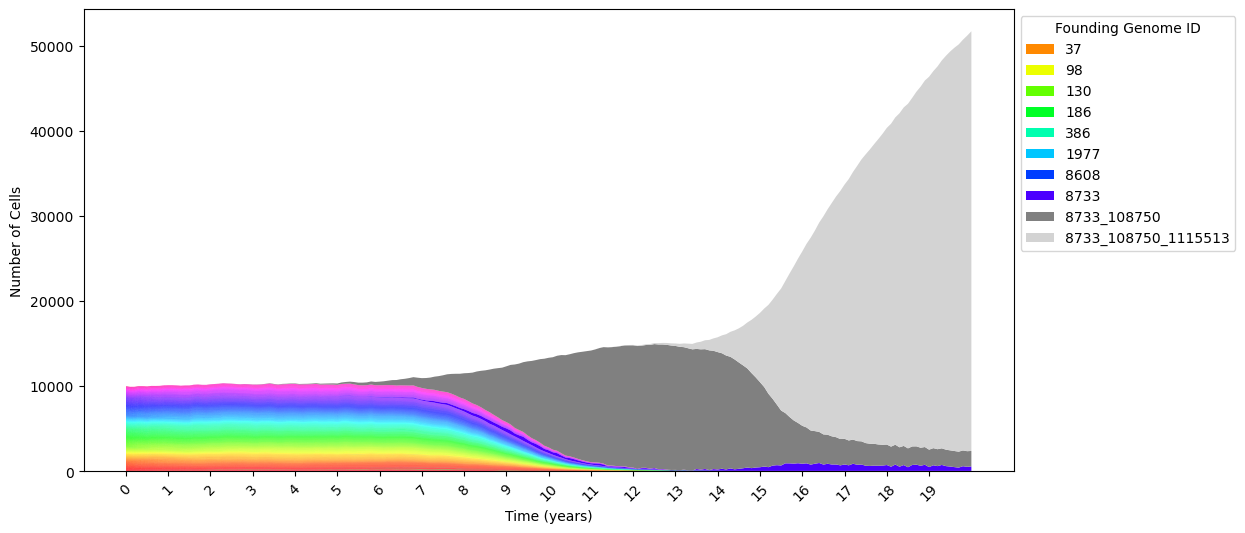

In [ ]:
## (Req) Generate riverplot and VAF plot 
# (TODO: Combine river, VAF and meth distribution plots)
print(mutant_ids)
print(idxs_to_label)
color_dict = riverplot_dt(X, Y, all_gen_ids, idxs_to_label, final_cycle=final_cycle, baseline='zero', log=False, mut_clones=mutant_ids, clone_colors=['grey','lightgrey','k'], color_map='gist_rainbow', top10_color_map='hsv')
plt.show()

# Subsampling

In [ ]:
## *(R) Option 3 - Hand pick cycles

#cycles = [300,325,340,355,370,390,410,425, 435, 445] ## for 30 yrs
#cycles = [e-50 for e in [300,325,340,355,370,390,410,425, 435, 445]] ## for 30 yrs
#cycles = [e for e in [265,275,285,295,305,315,325,335]] ## for 30 yrs
#cycles = [e for e in [275,285,295,305,315,325,335,345,355,365]]#,375,385]] ## for 30 yrs
#cycles = [10,40,80,100,120,140,160,180,200,220,240,260,280,300]
#cycles = [10,100,312,325]#,336

cycles = [e for e in range(0, cycles_total , 10)]
cycles.append(cycles_total)
cycles = cycles[:20]
clone_id = None
K = 300 ## Number of subsamples to take
C = 10 ## Number of CpGs sampled per epiallele (first 1 through C positions)

In [ ]:
# view only
for k,v in epimutation_record.items():
    if v[1] >0: print(k,v)

1 [208, 202]
2 [215, 184]
3 [214, 212]
4 [189, 183]
5 [218, 196]
6 [178, 218]
7 [226, 201]
8 [184, 207]
9 [189, 202]
10 [190, 192]
11 [206, 169]
12 [196, 180]
13 [206, 195]
14 [193, 208]
15 [222, 194]
16 [182, 200]
17 [204, 209]
18 [237, 212]
19 [185, 203]
20 [202, 179]
21 [203, 211]
22 [191, 213]
23 [210, 186]
24 [196, 194]
25 [198, 189]
26 [215, 220]
27 [216, 226]
28 [204, 211]
29 [206, 190]
30 [219, 209]
31 [194, 217]
32 [224, 190]
33 [214, 219]
34 [197, 196]
35 [196, 215]
36 [201, 186]
37 [221, 211]
38 [187, 206]
39 [197, 212]
40 [203, 215]
41 [190, 221]
42 [194, 212]
43 [215, 208]
44 [192, 188]
45 [195, 218]
46 [220, 202]
47 [198, 210]
48 [206, 201]
49 [205, 206]
50 [199, 218]
51 [206, 194]
52 [208, 230]
53 [208, 227]
54 [216, 221]
55 [206, 219]
56 [211, 191]
57 [205, 229]
58 [208, 184]
59 [219, 209]
60 [210, 192]
61 [208, 224]
62 [215, 215]
63 [223, 225]
64 [243, 178]
65 [233, 235]
66 [219, 200]
67 [217, 194]
68 [219, 219]
69 [232, 234]
70 [208, 210]
71 [248, 207]
72 [248, 211]
7

8733_108750
8733_108750_1115513


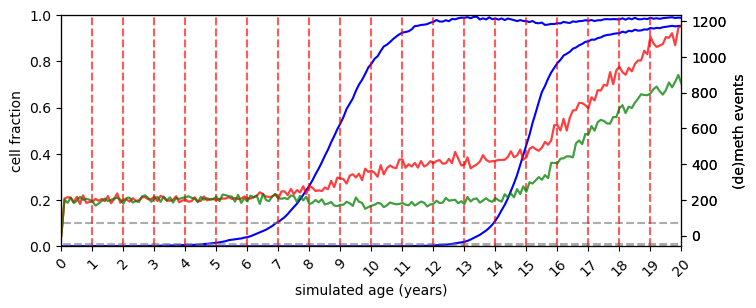

In [ ]:
## ** Plot Cell fractions with time point markers and generate dictionary for subclone cell fractions; get cell fractions
plot_FULL_RANGE = True
mut_id_cf = {}
fig, ax = plt.subplots(figsize=(8, 3))
for mutant_id in mutant_ids:
    mut_id_cf[mutant_id] = []
    print(mutant_id)
    if polyclonal:
        y = []
        cnt = 0
        for cycle, kv in cycle_gen_cnt.items():
            cf = kv[mutant_id]/sum(list(kv.values()))
            vaf = cf/2
            #y.append(vaf)
            y.append(cf)
            mut_id_cf[mutant_id].append(cf)
    else:
        y = []
        y2 = []
        y3 = []
        mut_trig = mutant_id.split("_")[-1]
        for cycle, kv in cycle_gen_cnt.items():
            counts = 0
            for k,v in kv.items():
                try:
                    if "_" in str(k):
                        if mut_trig in k.split("_"):
                            counts += v
                except:
                    print(k,v)
            cf = counts/sum(list(kv.values()))
            vaf = cf/2
            #y.append(vaf)
            y.append(cf)
            mut_id_cf[mutant_id].append(cf)

            # get fraction of epimutations
            #y2.append((epimutation_record[cycle][0]/(sum(list(kv.values())*L)))) ## epuimutation fraction of CpGs METH
            #y3.append((epimutation_record[cycle][1]/(sum(list(kv.values())*L)))) ## epuimutation fraction of CpGs DEMETH
            
            ### Get raw count of epimutions at each cycles
            y2.append(epimutation_record[cycle][0]) ## epimutation raw count METH
            y3.append(epimutation_record[cycle][1]) ## epimutation raw count DEMETH

    x = [idx/10 for idx, vaf in enumerate(y)]#[212:]
    ax.plot(x,y,color='blue')
    ax.hlines(0.001,-1,100, linestyles='--', color='grey', alpha=0.4)
    ax.hlines(0.01,-1,100, linestyles='--', color='grey', alpha=0.4)
    ax.hlines(0.1,-1,100, linestyles='--', color='grey', alpha=0.4)
    ax2 = ax.twinx()
    #ax2.plot(x,y2,color='r', alpha=0.5) ## meth events
    #ax2.plot(x,y3,color='g', alpha=0.5) ## demeth events

    for cycle_i in cycles:
        ax.vlines(cycle_i/10, 0.0001,1, linestyles='--', color='r', alpha=0.4)


    #ax.set_yscale("log")
    #ax.set_ylim(0.0001,1)
    ax.set_ylim(0,1)
    ax.set_xticks(np.arange(0,100,1))
    if plot_FULL_RANGE:
        ax.set_xlim(0,int((final_cycle)/10+1)) ## FULL RANGE of cycles
    else:
        ax.set_xlim(27,int((final_cycle)/10)) 
    ax.tick_params(axis='x', labelrotation=45)
    ax.set_xlabel('simulated age (years)')
    ax.set_ylabel('cell fraction')
    ax2.set_ylabel('(de)meth events')
plt.show()#'''

## Subsample multiple cycles and save as text or dill files

In [ ]:
# Show cycle list fo subsampling
print('time points (cycles):',cycles)
print('epiallele length:', C)
print('number of reads:', K)

time points (cycles): [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190]
epiallele length: 10
number of reads: 300


### Subsample epialleles from select cycles and convert to epiallele_object and save as dill files (optional)

Current sampling cycle: 0
300
pop Diversity: 10000
Clonal cell fraction: 0.0001
SAVE OPTION OFF - DILL FILE NOT SAVED
Current sampling cycle: 10
300
pop Diversity: 4790
Clonal cell fraction: 0.0015827480462953804
SAVE OPTION OFF - DILL FILE NOT SAVED
Current sampling cycle: 20
300
pop Diversity: 3259
Clonal cell fraction: 0.002348106838861168
SAVE OPTION OFF - DILL FILE NOT SAVED
Current sampling cycle: 30
300
pop Diversity: 2459
Clonal cell fraction: 0.0026470588235294116
SAVE OPTION OFF - DILL FILE NOT SAVED
Current sampling cycle: 40
300
pop Diversity: 1990
Clonal cell fraction: 0.005134663824840147
SAVE OPTION OFF - DILL FILE NOT SAVED
Current sampling cycle: 50
300
pop Diversity: 1632
Clonal cell fraction: 0.017251405311106804
SAVE OPTION OFF - DILL FILE NOT SAVED
Current sampling cycle: 60
300
pop Diversity: 1416
Clonal cell fraction: 0.04356078580241055
SAVE OPTION OFF - DILL FILE NOT SAVED
Current sampling cycle: 70
300
pop Diversity: 1275
Clonal cell fraction: 0.11608366060827

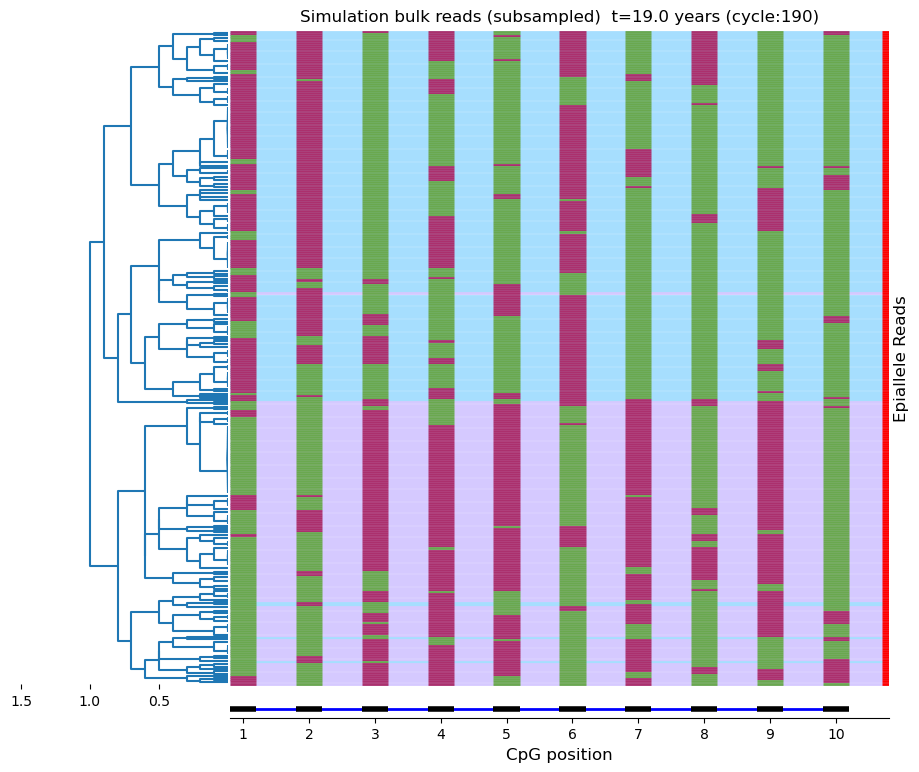

hap 1:
UPDATED 3
Cophenet distance: 0.7009387308232258
Number of leaf ids: 127
Plotting 127 reads found in input matrix with 10 CpG sites each...


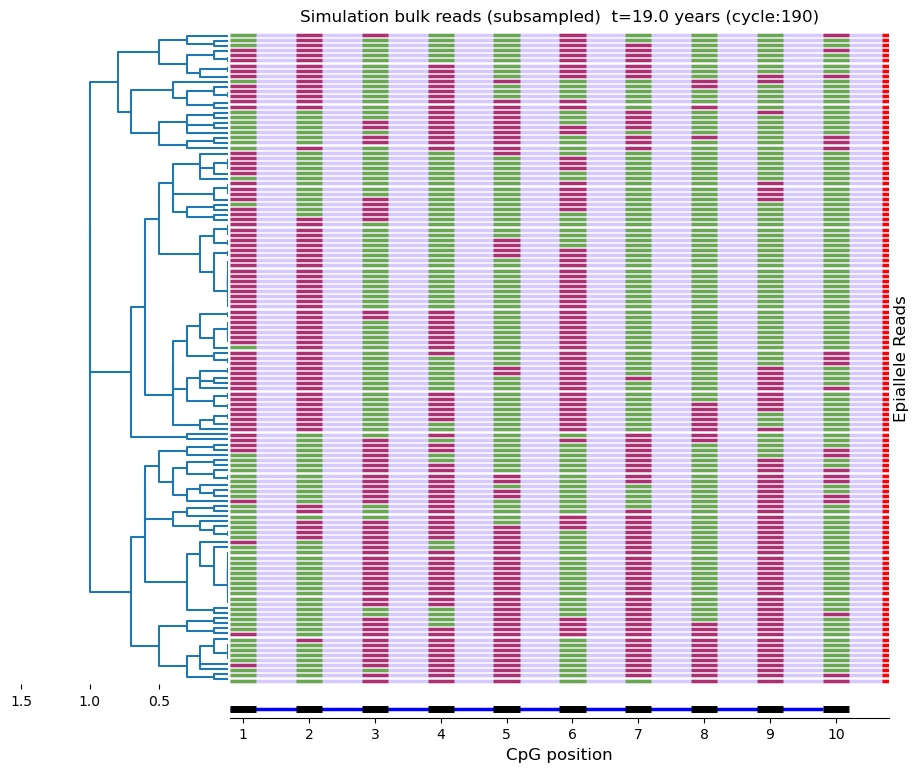

hap 2:
UPDATED 3
Cophenet distance: 0.8604138388535658
Number of leaf ids: 173
Plotting 173 reads found in input matrix with 10 CpG sites each...


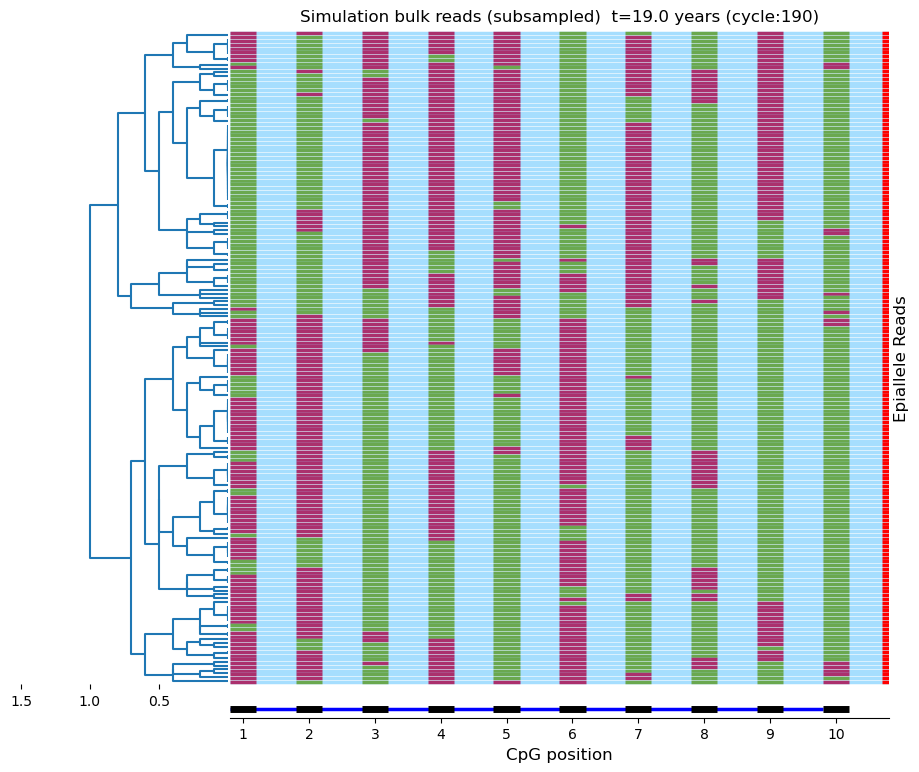

In [ ]:
## Dill files AND plots: Subsample select cycles and write as epiallele objects in dill files
## NOW with no-contiguous CpG subsampling option!

save=False
plot_pileup = False
plot_bar = False
clone_idx = 0 ##0=1st, 1=2nd, 2=3rd,...
sample_contiguous_cpgs =  True#False#

from datetime import datetime
run_i = datetime.now().strftime("%Y%m%d_%H%M")
mock_patient = 'model_a'

epiallele_objects_selected_cycles = []
cnt = 0
pick_hap = None# 1# 0# None# 

if not sample_contiguous_cpgs:
    import random
    positions = random.sample(range(epiallele_len_sub), C)
    # Sort them in ascending order
    positions.sort()
    print('non-contiguous CpG positions to sample:',positions)


cycle_subsampled_cells = {}
for cycle in cycles:
    cycle_subsampled_cells[cycle] = []
    #print('Current sampling cycle:', cycle, cnt)
    if cnt > 0 and cnt <= len(cycles): 
        cnt+=1
        #continue ## plot 1st and last time point in cycles list
    print('Current sampling cycle:', cycle)
    ## Subsample final population:
    ## Option to Subsample specific clone only
    ## Needs updating with new functions

    # variables defined in previous cell
    #clone_id = None# ## NOTE: turn use dummy to False below
    #K = 200 ## Number of subsamples to take
    #C = 10 ## Number of CpGs sampled per epiallele (first 1 through C positions)
    #cycle = 0
    #cycle = cycle_vaf_8_40[1]
    #print(cycle)
    #cycle = cycle_vaf_8_40[1]
    #cycle = final_cycle

    #if cycle < color_cycle:
    #    print(f'Please enter a cycle equal to or greater than {color_cycle}')

    ## Get founding epiallele of expanded clone and epiallele at expansion:
    mut_gen_0 = mutated_genomes[0][clone_idx] ##0=1st, 1=2nd, 2=3rd,...
    mutated_clone = mutant_ids[clone_idx] ##0=1st, 1=2nd, 2=3rd,...
    for cell in cell_dict[0]:
        if cell[0][0] == mut_gen_0:
            exp_clone_founding_cell = cell

    for cell in cell_dict[actual_selection_cycle]:
        if set([int(e) for e in mutated_clone.split('_')]).issubset(cell[0]):
            exp_clone_selection_cell = cell

    ## Prepare data for given cycle
    cell_dict_cycle = []
    for cell in cell_dict[cycle]:
        genome_i = cell[0].copy()
        epiallele_len_sub = len(cell[1])
        if '_' not in str(clone_id):
            if clone_id != None and genome_i[0] != clone_id: continue ## Remove all non-clonal cells if clone_id specified
            cell_dict_cycle.append(cell)
        else:
            if set([int(e) for e in mutated_clone.split('_')]).issubset(cell[0]):
                cell_dict_cycle.append(cell)
    if K != None and K > len(cell_dict_cycle):
        k = len(cell_dict_cycle)
    else:
        k = K

    ## Subsample data (randomly)
    #make a pool of cells and epialleles 
    cell_pool = []
    for cell in cell_dict_cycle:
        genome_i = cell[0].copy()
        #epiallele_i = cell[1].copy()[0:C]
        if sample_contiguous_cpgs:
            epiallele_i = cell[1].copy()[0:C]
        else:
            #print(cell[1])
            epiallele_i = [cell[1][position] for position in positions]
        for hap_i in [0,1]:
            epiallele_seq = []
            for tuple_i in epiallele_i: ## each tuple is a CpG from a single cell, the first tuple position is haplotype 0 and the the second is hap 1
                epiallele_seq.append(tuple_i[hap_i])
            cell_pool.append([genome_i, hap_i, epiallele_seq])

    integer_list = list(range(0, len(cell_pool))) # make a list of integers from 0 to N, where N is the number of cells in the given cycle
    
    ## actual subsampling step:  (this should be sampling from each allele/haplotype independently as would be expected in bulk sequencing)
    subsample_idx_list = rndom.sample(integer_list, k=k)  ## randomly select k integers for subsampling below (new list will be used to match the index for the iterator below)
    subsampled_founder_list = []
    subsampled_founders_for_iqtree = [] ## depricated, use subsampled_unique_genome_id instead
    subsampled_genome_list = []
    subsampled_unique_genome_id = []
    subsampled_epi_list = []
    subsampled_hap_list = []
    subsampled_genome_f = []
    last_id = ''
    subsampled_counter = 0
    for index in subsample_idx_list:
        #print(cell)
        cell = cell_pool[index] ## get "haploid cell" (genome, haplotype, and epiallele) from cell list generated above for given cycle based on index position using randomly generated list of indices
        cycle_subsampled_cells[cycle].append(cell)
        genome_i = cell[0]
        hap_i = cell[1]
        epiallele_i = cell[2].copy()[0:C]
        subsampled_genome_list.append(genome_i)       
        subsampled_hap_list.append(hap_i)
        subsampled_epi_list.append(epiallele_i)
        if set([int(e) for e in mutated_clone.split('_')]).issubset(genome_i):
            genome_id = mutated_clone.replace('_','.')
        else:
            if genome_i[0] == 0:
                genome_id =  str(genome_i[1])
            else:
                genome_id =  str(genome_i[0])
            if genome_id != last_id: ## reset sub-id counter if genome was derived from a different founder (all founders will have same id with _0 to _n sub-id)
                cnt = 0
            subsampled_founders_for_iqtree.append(genome_id+'_'+str(cnt))
        subsampled_founder_list.append(genome_id)        
        subsampled_unique_genome_id.append(genome_id+'_'+str(cnt))
        cnt += 1
        last_id = genome_id
    print(len(subsampled_genome_list))

    ## Print summary
    '''print('Subsampling data from simulation...')
    print(f'Cycle sampled: {cycle}')
    print(f' Number of subsamples: {K} of {len(cell_dict[cycle])} cells')
    print(f' Number of CpGs subsampled per epiallele: {C} of {L}')
    print(f' Epialleles of founding cell of expanded clone: \n\tgenome id: {exp_clone_founding_cell[0]}\n\tHap 0: {"".join([str(h0[0]) for h0 in exp_clone_founding_cell[1]])}\n\tHap 1: {"".join([str(h1[1]) for h1 in exp_clone_founding_cell[1]])}')
    print(f' Epialleles of expanded clone AT SELECTION EVENT: \n\tgenome id: {exp_clone_selection_cell[0]}\n\tHap 0: {"".join([str(h0[0]) for h0 in exp_clone_selection_cell[1]])}\n\tHap 1: {"".join([str(h1[1]) for h1 in exp_clone_selection_cell[1]])}')
    print('Origin Simulation Parameters:')
    print(f' seed: {seed_i} \n mu: {u}\n gamma: {g}\n Number of CpGs (L): {L}\n Founding population size (N): {N}\n Number of cycles: {cycles} \n Population Limit: {pop_lim} \n Selection advantage: {sel_advs}')# \n Founding epiallele: {epiallele_f}')
    print(f'\n Number of cycles carried out: {len(cell_dict)-1}')
    print(f' Final Population Diversity (before subsampling): {len(set(founder_list))+1}')
    print(f' Subsampled Diversity: {len(set(subsampled_founder_list))}')'''

    ## Get Cell fractions and plot histogram with subsampled genome ids
    ## Create dictionary of unique founding genomes using cycle 0 {genome_ID: 0}
    clone_dict = get_clone_dict(cell_dict)
    clone_dict[mutated_clone] = 0 ## add entry for mutated clone 

    ## Create a dictionary of cycles and genomeID:0 {cycle: {genome_ID:0}}
    cycle_gen_cnt_i = get_clone_cnts_v2({final_cycle:cell_dict_cycle}, clone_dict, mutated_clone) ## ouput is {cycle:{genome_id: cnt}}
    
    wd = 12
    ht = 3
    data = {}
    total = 0 
    max_clones_to_plot = 1000

    gen_cnt = cycle_gen_cnt_i[final_cycle]
    data = {}
    total = 0 
    for id, cnt in gen_cnt.items():
        #print(id)
        if cnt > 0:
            data[str(id)] = cnt
        total += cnt
    print(f'pop Diversity: {len(data.keys())}')

    pre_y = [cnt/total for cnt in data.values()]
    pre_x = [str(id) for id in data.keys()]
    y = sorted_founders = sorted(pre_y, reverse=True)
    x = sort_A_using_B(pre_x, pre_y, accending=True)
    color = []
    for id in x:
        if int(id) in color_dict.keys():
            color.append(color_dict[int(id)])
        elif id in color_dict.keys():
            color.append(color_dict[id])
        else:
            color_dict[int(id)] = 'lightgray'
    if plot_bar:
        fig, ax = plt.subplots(figsize=(wd, ht))
        ax.bar(x[:max_clones_to_plot],y[:max_clones_to_plot],color=color) #, density=True)
        ax.set_ylabel('Fraction of Total Cells')
        ax.set_xlabel('Genome ID')
        ax.set_xticks(ax.get_xticks())
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')
        #ax.ticklabel_format(useOffset=False)
        #ax.ticklabel_format(style='plain') 
        plt.margins(0.01, 0.01)    
        plt.show()
    clonal_cell_fraction = [e for e in y][0]
    print('Clonal cell fraction:', clonal_cell_fraction)

    #print('genome ids:', x,'\n')
    #print('cell fractions plotted:', y,'\n')
    #print('VAFs from cell fraction:', [e/2 for e in y])

    ## Covert subsampled epialleles to epiallele_object dill file

    # initialize epiallele object variables
    builder_version = 'simulator_beta_v1.1'
    library_id = f'simulation_{mock_patient}_c{cycle:04d}_{run_i}' ## note this f'{cycle:04d}' trick adds leading 0s to cycle number out to 4 digits to make uniform length for maintaining cycle order when reading back files
    donor_id = f'simulation_{mock_patient}_{run_i}'
    timepoint = f'c{cycle}'
    age = cycle/10
    matched_ctrl = ''
    ref_genome = 'hg19'
    if u_2 <= 0.000001:
        u_2 = 0
    if g_2 <= 0.000001:
        g_2 = 0
    nametag = f'u_{u_2}_g_{g_2}'
    outdir = '/home/groups/CEDAR/boniface/blundell_lab/epiallele_simulator/epiallele_object_dill_files/'
    epiallele_objects = [] 
    region = [1,C]
    object_idx = 0
    successfully_haplotyped = 0

    if nametag == 'default':
        nametag = datetime.now().strftime("%Y%m%d_%H%M")

    epi_matrix_for_tp = []
    epi_matrix_for_tp_hap1 = []
    epi_matrix_for_tp_hap2 = []
    iD_list = subsampled_unique_genome_id
    readname_list = []
    readname_list_hap1 = []
    readname_list_hap2 = []
    hap_dict = {}
    for idx, epiallele_i in enumerate(subsampled_epi_list):
        ## Get epiallele of current cell
        hap = subsampled_hap_list[idx]
        if pick_hap != None and str(pick_hap) not in str(hap): continue
        readname = f'{iD_list[idx]}_{hap+1}'        
        if hap == 0:
            epi_matrix_for_tp_hap1.append(cpg_states)
            readname_list_hap1.append(readname)
        if hap == 1:
            epi_matrix_for_tp_hap2.append(cpg_states)
            readname_list_hap2.append(readname)
        readname_list.append(readname)
        hap_dict[readname] = hap
        chromosome = 'S'
        epistart = 1
        epistop = C
        length = C
        readstrand = '+'
        mutations = {}
        cpg_poses = [e for e in range(1,C+1)]
        cpg_states = epiallele_i
        epi_matrix_for_tp.append(cpg_states)
        if iD_list[idx].split('_')[0] == mutated_clone.replace('_','.'):
            mut_read = True
        else:
            mut_read = False
        snps = {} # future proofing
        snvs = {} # future proofing
        #print(iD_list[idx], hap, epiallele)
        epiallele_objects.append(epiallele_obj(
                    builder_version = builder_version,
                    library_id = library_id, # str, sequencing library id (eg: "SLX-22810.A3")
                    donor_id = donor_id, # str, donor ID (eg: 'C92_008')
                    timepoint = timepoint, # str, time point (eg: 's10')
                    age = age,
                    matched_ctrl = matched_ctrl,
                    nametag = nametag, # str, user specified string that is embeded into epiallele objects filename (defaults to date-time stamp)
                    readname = readname, # str, read name from Bismark methylation extractor output file, eg: CpG_context_sorted_SLX-22810.A3**.txt.gz (eg: 'A00489:1689:HNHMGDSX5:3:1101:3369:15875_1:N:0:CCAGTTGA+ATGACGTC')
                    chromosome = chromosome, # str, chromosome read mapped to (accept 'chrN' and 'N'?)
                    epistart = epistart, # int, always left-most CpG position covered by read
                    epistop = epistop, # int, always right-most CpG position covered by read
                    length = length, # int, epistop - epistart
                    readstrand = readstrand, # str, orientation of read ('+' or '-')
                    ref_genome = ref_genome, # str, reference genome of cpg positions in cpg_poses attribute
                    hap = f'HP{hap+1}', # str, assigned haplotype of read ('H1','H2', 'HP1', 'HP2', or, 'none')
                    mut_read = mut_read, # bool, does the read carry a somatic variant ('True' or 'False')
                    snps = snps, # dict, meant to be a dictionary of SNPs positions:'ref' or 'alt' (future-proofing?)
                    snvs = snvs, # dict, meant to be a dictionary of somatic SNVs position:'ref' or 'alt' (future-proofing?)
                    mutations = {},  # dict, meant to be a dictionary of mutations and vafs for the given time point (eg: 'DNMT3A_p.R882H': 0.48)
                    clonal_cf = clonal_cell_fraction, # float, value 0-1 for clonal cell fraction (typically the most abundant mutational VAF*2 for a heterzygous mutation in a diploid cell)
                    cpg_poses = cpg_poses, # list, list of CpG positions covered by read in positive orientation, (eg: [140202835, 140202846, 140202849, 140202857, 140202861, 140202865, 140202871, 140202878])
                    cpg_states = cpg_states,
                    )
            )
    filename=f'{library_id}_{chromosome}_{region[0]}_{region[1]}_{nametag}_epiallele_objects' ## Note that start and stop are based on read coordinates, NOT CpGs, so they will not match query regions
    if save:
        outfile = save_obj(epiallele_objects, dir=outdir, filename=filename)
        print(f'Saved epiallele object data to file {outfile}')
    else:
        print('SAVE OPTION OFF - DILL FILE NOT SAVED')

    epiallele_objects_selected_cycles.append(epiallele_objects)    
    
    ## Plot pileup of epiallele matrix hclust
    if plot_pileup or cycle == cycles[-1]:
        input_matrix = epi_matrix_for_tp
        #print('>>>>>>>>>>>>>>len(readname_list):',len(readname_list)) ## DEBUG
        #print('>>>>>>>>>>>>>>len(input_matrix):',len(input_matrix)) ## DEBUG
        
        ylabel_id_colors_dict = {}
        for iD in readname_list:
            if '.' in str(iD):
                id = iD.split('_')[0].replace('.','_')
            else:
                id = int(iD.split('_')[0])
            ylabel_id_colors_dict[id]=color_dict[id]
        #print('>>>>>>>>>>>>>>len(ylabel_id_colors_dict):',len(ylabel_id_colors_dict)) ## DEBUG
        #print('>>>>>>>>>>>>>>ylabel_id_colors_dict:', ylabel_id_colors_dict) ## DEBUG
        plot_iqtree_pileup(input_matrix, 
                        id_labels=readname_list, 
                        color_mut_clone = True,
                        no_read_labels = True,
                        results_path='', x_range=None, xpad=0, max_reads=1500, tree_type ='hclust', 
                        #ylabel_id_colors_dict=ylabel_id_colors_dict, 
                        ylabel_id_colors_dict=None, 
                        plot_read_color=True, hap_dict=hap_dict, cycle=cycle)
        print("hap 1:")
        plot_iqtree_pileup(epi_matrix_for_tp_hap1, 
                id_labels=readname_list_hap1, 
                color_mut_clone = True,
                no_read_labels = True,
                results_path='', x_range=None, xpad=0, max_reads=1500, tree_type ='hclust', 
                #ylabel_id_colors_dict=ylabel_id_colors_dict, 
                ylabel_id_colors_dict=None, 
                plot_read_color=True, hap_dict=hap_dict, cycle=cycle)
        print("hap 2:")
        plot_iqtree_pileup(epi_matrix_for_tp_hap2, 
                id_labels=readname_list_hap2, 
                color_mut_clone = True,
                no_read_labels = True,
                results_path='', x_range=None, xpad=0, max_reads=1500, tree_type ='hclust', 
                #ylabel_id_colors_dict=ylabel_id_colors_dict, 
                ylabel_id_colors_dict=None, 
                plot_read_color=True, hap_dict=hap_dict, cycle=cycle)
    cnt +=1
#print(epiallele_objects[0].__dict__)


# Plot Epiallele dynamics (newer scripts)

## Time lines and haplotype labeling and inference

### True haploid assignment

Clone: 0
   Haploid A: 0011001010
   Haploid B: 0000000000
Clone: 1
   Haploid A: 0011101010
   Haploid B: 1100010000
epialleles_to_label: ['0011001010', '0000000000', '0011101010', '1100010000']
hamming distance between clone 2 top 2 epialleles: 8


/home/groups/CEDAR/boniface/java_tmp/ipykernel_1493484/3614946610.py:114: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  return sum(el1 != el2 for el1, el2 in zip(seq1, seq2))


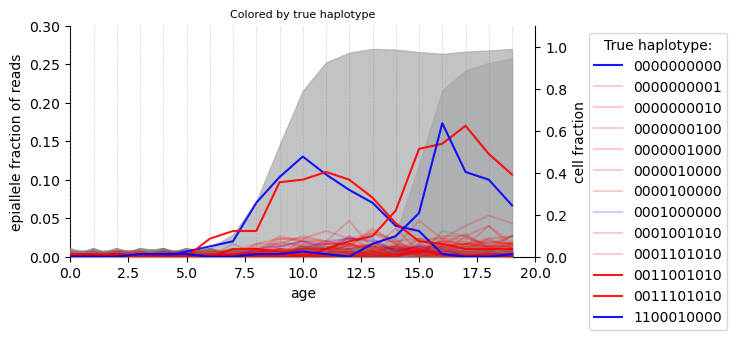

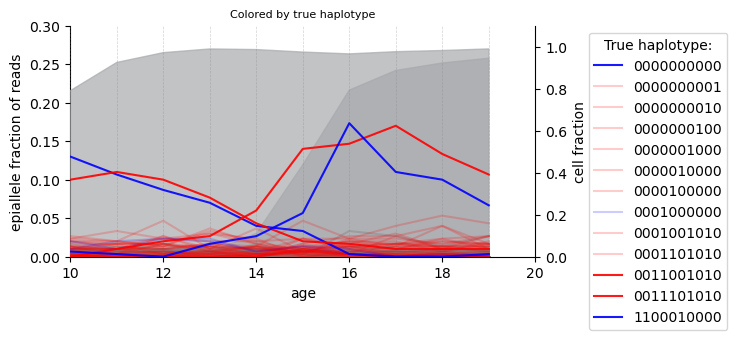

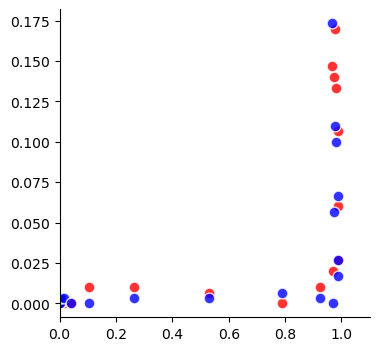

In [ ]:
## Time line with true haplotypes
min_hap_hamming_dist = 1

#print epialleles of mutated cells (clone and subclones) and assign top two for labelling
mutant_epialleles = []
for i, cell in enumerate(mutated_cells):
    epiallele_i = cell[1]
    e_hap1_str = ''.join([str(e) for e in list(zip(*epiallele_i))[0]])
    e_hap2_str = ''.join([str(e) for e in list(zip(*epiallele_i))[1]])
    print('Clone:', i)
    print(f'   Haploid A:', e_hap1_str)
    print(f'   Haploid B:', e_hap2_str)
    mutant_epialleles.append(str(e_hap1_str))
    mutant_epialleles.append(str(e_hap2_str))
    if i+1 == number_of_selection_events:
        top_2 = [str(e_hap1_str),str(e_hap2_str)]
distance = hamming_distance(top_2)
print('epialleles_to_label:', mutant_epialleles)
print(f'hamming distance between clone {number_of_selection_events} top 2 epialleles:', distance)

## create true haplotype dictionary of barcodes from subsampled cells
hap_1_barcodes = []
hap_2_barcodes = []

sn = 'all' ## sample number to run k-means (depricated option, set to 'all')
clonal_cell_fraction_color = 'k'
subclonal_cell_fraction_color = 'grey'
plot_ccf_lines = False
fill_ccf = True
plot_reg =  False#

minimum_fBF = 0.01 #threshold to start coloring lines by haploid
cluster_dif = 0.1 # maximum difference between k-means cluster fractions in Dx (0.1 = 10%) (used in next code block)
colors = ['r','b'] #['#27AAE1','#662D91'] #,'purple','r','k','grey']

## (Req) Get CpG positions SIMULATOR SPECS
chromosome = 'S'
L = C
#L = 10 ## length of simulated epialleles
cpg_list = [e for e in range(1,L+1)]
start, stop = cpg_list[0], cpg_list[-1]
fa_cpg_locs = cpg_list
#print(fa_cpg_locs)

## (R) Option 1: get epiallel objects generated in subsampler above
title_i = f'barcode: {cpg_list}'
#print(title_i)
number_of_tps = len(cycles)

hap = None
ages=[]
clonal_cfs = []
species_counts_dicts = [] ## this will be a list of counter objects (dictionaries)
sample_epimatrix_dict = {}
sample_barcode_dict = {}
cnt=0
for epiallele_objects in epiallele_objects_selected_cycles:
        matrix_objects, matrix_readnames, epiallele_matrix = build_epiallele_matrix(epiallele_objects, 
                                                                                    chromosome='S',
                                                                                    qstart=cpg_list[0], 
                                                                                    qstop=cpg_list[-1], 
                                                                                    hap=hap,
                                                                                    use_these_CpGs_only=cpg_list, # list of cpg positions; overides qstart and qstop if provided
                                                                                    )
        #print(matrix_objects[0].__dict__)
        sample_epimatrix_dict[f'sim_{matrix_objects[0].timepoint}'] = epiallele_matrix 
        ages.append(matrix_objects[0].age)
        clonal_cfs.append(matrix_objects[0].clonal_cf)
        mu = matrix_objects[0].nametag.split('_')[1]
        gamma = matrix_objects[0].nametag.split('_')[-1]
        ## Count species
        epimatrix_dict = {}
        epiallele_matrix_as_strings = []
        for idx, e in enumerate(epiallele_matrix): ## Note: epimatrix is defined by qstart and stop boundaries
            #print(e)
            if np.nan in e: continue ## remove any reads where all CpGs are not covered (should change to fraction for long-read data)
            e_str = [str(bit) for bit in e]
            if '1' in matrix_objects[idx].hap:
                hap_1_barcodes.append(''.join(e_str))
            if '2' in matrix_objects[idx].hap:
                hap_2_barcodes.append(''.join(e_str))
            epiallele_matrix_as_strings.append(''.join(e_str))
            epimatrix_dict[idx] = e
        species_counts_dict = dict(collections.Counter(epiallele_matrix_as_strings))            
        #print(species_counts_dict)
        species_counts_dicts.append(collections.Counter(epiallele_matrix_as_strings))
        #species_counts_dicts.append(species_counts_dict) # better but haven't tested with older downstream stuff
        cnt += 1

species_counts_dict_s1toDx = species_counts_dicts
## (REQ) Plot distributions all time points (and get "x" - used later)
L = len(cpg_list)
possible_epialleles = ["".join(seq) for seq in itertools.product("01", repeat=L)] ## get possible epialleles (not currently used)
#print(len(possible_epialleles))
#x = possible_epialleles #plot all possible epiallele strings

x=[] ## get epiallele string ONLY if in ANY s1 to s7
all_exisiting_epialleles = [j for js in [list(e_i.keys()) for e_i in species_counts_dict_s1toDx] for j in js] ## flattens list of lists but has duplicates
for e in possible_epialleles: ## get non-duplicated list of existing epialleles
    if e in all_exisiting_epialleles:
        x.append(e)

## Define VAFs/CFs
clonal_cell_fractions = []
subclonal_cell_fractions_1 = []
#subclonal_cell_fractions_2 = []
for c_i in cycles:
    clonal_cell_fractions.append(mut_id_cf[list(mut_id_cf.keys())[0]][c_i]) ## get cfs of first mutation (assuming model is monoclonal)
    subclonal_cell_fractions_1.append(mut_id_cf[list(mut_id_cf.keys())[1]][c_i]) ## get cfs of second mutation (assuming model is monoclonal)
    subclonal_cell_fractions_2 = []
    #subclonal_cell_fractions_2.append(mut_id_cf[list(mut_id_cf.keys())[2]][c_i]) ## get cfs of second mutation (assuming model is monoclonal)

## (REQ) Plot and color according to true haplotype and mutant progenitor cell epialleles
def plot_time_course_zoom(left=0,right=cycles_total/10):
    n = len(x)
    w,h = 6,3
    fig,ax = plt.subplots(figsize=(w,h))
    #x_t = ['s1','s3','s5','s7']
    x_t = ages
    lines = []
    #epialleles_to_label = list(set(top_4 + top_2_s1))
    #colors = ['r','b'] #['#27AAE1','#662D91'] #,'purple','r','k','grey']
    labels = []
    max_lines_to_color = 10
    color_cntr = 0
    top_2_fBFs_hap1 = []
    top_2_fBFs_hap2 = []
    for i, barcode_i in enumerate(x): ## iterate through species and plot trajectory over time points
        # get closest hamming distance to mutant cell progenitor epialleles:
        ham_dists = []
        for mut_epiallele in mutant_epialleles:
            ham_dists.append(hamming_distance([barcode_i, mut_epiallele]))
        best_hamming  = min(ham_dists)
        #plot each time point
        y = []
        for k in species_counts_dict_s1toDx: ## this is a list of counter objects (dictionaries)
            if barcode_i in k.keys():
                #y_k = k[e]/len(x)
                y_k = k[barcode_i]/sum(list(k.values()))
            else:
                y_k = 0
            y.append(y_k)
        #print(x_t,y) ##DEBUG
        ## check barcode hamming distance to clonal progenitor epialleles, get haploid and assign color and alpha
        if barcode_i in mutant_epialleles: # if barcode is an exact match to progenitor mutant cell epiallele, than alpha is higher and it gets called out in scatter plot
            a = 0.9
            if mutant_epialleles.index(barcode_i) % 2 == 0: ## using location in mutant_epialleles (even vs odd index) to determine haplotype (instead of dearching larger list)
                color='r'
                top_2_fBFs_hap1 = y # for scatter plot
                zorder = 10
            else:
                color='b'
                top_2_fBFs_hap2 = y # for scatter plot
                zorder = 10
            lines.append(ax.plot([], [],alpha=a,color=color)) ## for legend
            labels.append(barcode_i)
            color_cntr += 1
        elif best_hamming != 0 and best_hamming <= min_hap_hamming_dist:  # (note !=0 is redundant with elif) check if barcode is within min hamming of originally mutated progenitor cell epialleles 
            a = 0.2
            if barcode_i in hap_1_barcodes:
                color='r'
            elif barcode_i in hap_2_barcodes: ## it is possible that a barcode is in both haplotype lists by chance!! (less likely that they would meet hamming dist criteria)
                color='b'
            else:
                print(f'haplotype for barcode {barcode_i} not found')
            zorder = 9
            if color_cntr < max_lines_to_color: 
                lines.append(ax.plot([], [],alpha=a,color=color)) ## for legend
                labels.append(barcode_i)
                color_cntr += 1
        else:
            color='grey'
            a = 0.4
            zorder = 5
        ax.plot(x_t,y, color=color, alpha=a, zorder=zorder)
    ax2 = ax.twinx()
    #clonal_cell_fraction_color = 'k'
    #subclonal_cell_fraction_color = 'grey'
    if plot_ccf_lines:
        ax2.plot(x_t, clonal_cell_fractions, color=clonal_cell_fraction_color, alpha=0.8, linestyle='--')
        lines.append(ax.plot([], [], color=clonal_cell_fraction_color, alpha=0.5, linestyle='--'))
        ax2.plot(x_t, subclonal_cell_fractions_1, color=subclonal_cell_fraction_color, alpha=0.8, linestyle='--')
        lines.append(ax.plot([], [], color=subclonal_cell_fraction_color, alpha=0.5, linestyle='--'))
        ax2.plot(x_t, subclonal_cell_fractions_2, color=subclonal_cell_fraction_color, alpha=0.8, linestyle='--')
        lines.append(ax.plot([], [], color=subclonal_cell_fraction_color, alpha=0.5, linestyle='--'))
        legend_texts=  labels + ['clonal cell fraction','subclonal cell fraction','subclonal cell fraction']
    else:
        legend_texts=  labels
    ax2.set_ylabel('cell fraction')
    ax.set_xlabel('age')
    if fill_ccf:
        ax2.fill_between(
            x= x_t, y1 = clonal_cell_fractions,
            #where= (-1 < t)&(t < 1),
            color= "#A8AAAD",
            alpha= 0.7,
            zorder=10,
            )
        ax2.fill_between(
            x= x_t, y1 = subclonal_cell_fractions_1,
            #where= (-1 < t)&(t < 1),
            color= "#A7A9AC",
            alpha= 0.7,
            zorder=11,
            )
        if len(subclonal_cell_fractions_2) != 0:
            ax2.fill_between(
                x= x_t, y1 = subclonal_cell_fractions_2,
                #where= (-1 < t)&(t < 1),
                color= "#6D6E71",
                alpha= 0.7,
                zorder=10,
                )
    ax.set_zorder(1)  # default zorder is 0 for ax1 and ax2
    ax.set_frame_on(False)
    ax.set_ylabel('epiallele fraction of reads')
    lines_i = [line[0] for line in lines]
    ax.legend(lines_i, 
            legend_texts,
            title='True haplotype:',
            loc='upper left',
            bbox_to_anchor=(1.1, 1),
            )
    ax.spines['top'].set_visible(False) ## Remove border 
    ax2.spines['top'].set_visible(False) ## Remove border
    #ax.set_yscale('log')
    #ax2.set_yscale('log')
    #ax.set_ylim(0.04,.4)
    #ax.set_ylim(0,0.3)
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(0,0.3)
    #ax.set_ylim(0,.5)
    ax2.set_ylim(0,1.1)
    ax.set_xlim(left,right)
    ax2.set_xlim(left,right)
    #plt.margins(0, 0)
    ax.vlines(x_t, 0, 0.5, alpha=0.35, color='grey',linestyles='dashed',linewidth=.5) ## plot tp lines
    plt.title('Colored by true haplotype', fontsize=8)
    plt.show()
    return top_2_fBFs_hap1,  top_2_fBFs_hap2

top_2_fBFs_hap1, top_2_fBFs_hap2 = plot_time_course_zoom()
top_2_fBFs_hap1, top_2_fBFs_hap2 = plot_time_course_zoom(left=10)
if len(top_2_fBFs_hap1) == 0: top_2_fBFs_hap1 = [0]*len(clonal_cell_fractions)
if len(top_2_fBFs_hap2) == 0: top_2_fBFs_hap2 = [0]*len(clonal_cell_fractions)

## Plot Scatter
def plot_scatter():
    wd = 4
    ht = 4
    s=100
    fig, ax1 = plt.subplots(1, 1, figsize=(wd,ht))
    x1 = clonal_cell_fractions
    if plot_reg: ## get regression
            try:
                sns.regplot(x=x1,
                        y=top_2_fBFs_hap1,
                        scatter_kws = {'color':'r', 'alpha': 1, 's':s, 'edgecolors':'w','zorder':2}, 
                        line_kws = {'color':'black','linewidth':1,'zorder':1}, order=1,
                        #ax=ax1,
                        ci=None,
                        )
                sns.regplot(x=x1,
                        y=top_2_fBFs_hap2,
                        scatter_kws = {'color':'b', 'alpha': 1, 's':s, 'edgecolors':'w','zorder':2}, 
                        line_kws = {'color':'black','linewidth':1,'zorder':1}, order=1,
                        #ax=ax1,
                        ci=None,
                        )
            except:
                ax1.scatter(x1, top_2_fBFs_hap1, color='r', s=s, alpha=0.9,  edgecolors='w')
                ax1.scatter(x1, top_2_fBFs_hap2, color='b', s=s, alpha=0.9,  edgecolors='w')
    else:
        ax1.scatter(x1, top_2_fBFs_hap1, 
                    color='r', 
                    s=60,
                    alpha=0.8,
                    edgecolors='w',
                    )#, color='r',  s=s, edgecolors=w)
        ax1.scatter(x1, top_2_fBFs_hap2,
                    color='b', 
                    s=60,
                    alpha=0.8,
                    edgecolors='w',
                    )
    #print(x1, top_2_fBFs_hap1)
    #print(x1, top_2_fBFs_hap2)
    y_min, y_max = ax1.get_ylim()
    ax1.set_xlim(0,1.1)
    #ax1.set_ylim(0,0.45)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    #plt.savefig('/home/groups/CEDAR/boniface/blundell_lab/EM-Seq/C92_002_fCpG_variance_vs_cell_fraction_no_titles_240515.pdf', bbox_inches='tight',transparent=True)
    #plt.title(caseID)
    plt.show()    

plot_scatter()


### Haploid assignment by inference (kmeans clustering)

In [ ]:
## Single barcode (same script used for samples)

#print epialleles of mutated cells (clone and subclones)
for i, cell in enumerate(mutated_cells):
    epiallele_i = cell[1]
    e_hap1_str = ''.join([str(e) for e in list(zip(*epiallele_i))[0]])
    e_hap2_str = ''.join([str(e) for e in list(zip(*epiallele_i))[1]])
    print('Clone:', i)
    print(f'   Haploid A:', e_hap1_str)
    print(f'   Haploid B:', e_hap2_str)

sn = 'all' ## sample number to run k-means (depricated option, set to 'all')
clonal_cell_fraction_color = 'k'
subclonal_cell_fraction_color = 'grey'
plot_ccf_lines = False
fill_ccf = True
plot_reg =  False#

minimum_fBF = 0.01 #threshold to start coloring lines by haploid
cluster_dif = 0.1 # maximum difference between k-means cluster fractions in Dx (0.1 = 10%) (used in next code block)
colors = ['r','b'] #['#27AAE1','#662D91'] #,'purple','r','k','grey']

## (Req) Get CpG positions SIMULATOR SPECS
chromosome = 'S'
L = C
#L = 10 ## length of simulated epialleles
cpg_list = [e for e in range(1,L+1)]
start, stop = cpg_list[0], cpg_list[-1]
fa_cpg_locs = cpg_list
#print(fa_cpg_locs)

## (R) Option 1: get epiallel objects generated in subsampler above
title_i = f'barcode: {cpg_list}'
#print(title_i)
number_of_tps = len(cycles)

hap = None
ages=[]
clonal_cfs = []
species_counts_dicts = [] ## this will be a list of counter objects (dictionaries)
sample_epimatrix_dict = {}
sample_barcode_dict = {}
cnt=0
for epiallele_objects in epiallele_objects_selected_cycles:
        matrix_objects, matrix_readnames, epiallele_matrix = build_epiallele_matrix(epiallele_objects, 
                                                                                    chromosome='S',
                                                                                    qstart=cpg_list[0], 
                                                                                    qstop=cpg_list[-1], 
                                                                                    hap=hap,
                                                                                    use_these_CpGs_only=cpg_list, # list of cpg positions; overides qstart and qstop if provided
                                                                                    )
        #print(matrix_objects[0].__dict__)
        sample_epimatrix_dict[f'sim_{matrix_objects[0].timepoint}'] = epiallele_matrix 
        ages.append(matrix_objects[0].age)
        clonal_cfs.append(matrix_objects[0].clonal_cf)
        mu = matrix_objects[0].nametag.split('_')[1]
        gamma = matrix_objects[0].nametag.split('_')[-1]
        ## Count species
        epimatrix_dict = {}
        epiallele_matrix_as_strings = []
        for idx, e in enumerate(epiallele_matrix): ## Note: epimatrix is defined by qstart and stop boundaries
            #print(e)
            if np.nan in e: continue ## remove any reads where all CpGs are not covered (should change to fraction for long-read data)
            e_str = [str(bit) for bit in e]
            epiallele_matrix_as_strings.append(''.join(e_str))
            epimatrix_dict[idx] = e
        species_counts_dict = dict(collections.Counter(epiallele_matrix_as_strings))            
        #print(species_counts_dict)
        species_counts_dicts.append(collections.Counter(epiallele_matrix_as_strings))
        #species_counts_dicts.append(species_counts_dict) # better but haven't tested with older downstream stuff
        cnt += 1

species_counts_dict_s1toDx = species_counts_dicts
## (REQ) Plot distributions all time points (and get "x" - used later)
L = len(cpg_list)
possible_epialleles = ["".join(seq) for seq in itertools.product("01", repeat=L)] ## get possible epialleles (not currently used)
#print(len(possible_epialleles))
#x = possible_epialleles #plot all possible epiallele strings

x=[] ## get epiallele string ONLY if in any s1 to s7
all_exisiting_epialleles = [j for js in [list(e_i.keys()) for e_i in species_counts_dict_s1toDx] for j in js] ## flattens list of lists but has duplicates
for e in possible_epialleles: ## get non-duplicated list of existing epialleles
    if e in all_exisiting_epialleles:
        x.append(e)

#get s1 top 2
sorted_dict = dict(sorted(species_counts_dict_s1toDx[0].items(), key=lambda item: item[1])) ## sort epiallele:counts dictionary by counts (this is accending)
top_2_s1 = list(sorted_dict.keys())[-2:]
#print('s1:', top_2_s1)
top_4_s1 = list(sorted_dict.keys())[-4:]
#print('s1 top_4_s1:', top_4_s1)
#print('S1 dict:', sorted_dict)

if sn == 'all':
    for sn_i, sample in enumerate(list(sample_epimatrix_dict.keys())):
        #get sn_i top 2
        sorted_dict = dict(sorted(species_counts_dict_s1toDx[sn_i].items(), key=lambda item: item[1])) ## sort epiallele:counts dictionary by counts (this is accending)
        sample_barcode_dict[sample] = sorted_dict
        #top_2_sn = list(sorted_dict.keys())[-2:]
        #top_4_sn = list(sorted_dict.keys())[-4:]
        #print(f's{sn_i} top_4_{sn_i}:', top_4_sn)
        #print(f'S{sn_i+1} dict:', sorted_dict)
    #print(sample_barcode_dict)
else:
    #get sn top 2
    sorted_dict = dict(sorted(species_counts_dict_s1toDx[sn].items(), key=lambda item: item[1])) ## sort epiallele:counts dictionary by counts (this is accending)
    top_2_sn = list(sorted_dict.keys())[-2:]
    #print('s1:', top_2_s1)
    top_4_sn = list(sorted_dict.keys())[-4:]
    #print(f's{sn+1} top_4_{sn}:', top_4_sn)
    #print(f'S{sn+1} dict:', sorted_dict)

## (REQ) get top two epialleles from final tp ("Dx")
sorted_dict = dict(sorted(species_counts_dict_s1toDx[-1].items(), key=lambda item: item[1])) ## sort epiallele:counts dictionary by counts (this is accending)
top_8 = list(sorted_dict.keys())[-8:]
top_4 = list(sorted_dict.keys())[-4:]
top_2 = list(sorted_dict.keys())[-2:]
distance = hamming_distance(top_2)
#print('Dx top_4:', top_4)
#print('Dx dict:', sorted_dict)
#print('Dx:',top_8)
#print('Dx:',top_2)
#print(f"Hamming distance between {top_2} : {distance}")


## Define VAFs/CFs
clonal_cell_fractions = []
subclonal_cell_fractions_1 = []
#subclonal_cell_fractions_2 = []
for c_i in cycles:
    clonal_cell_fractions.append(mut_id_cf[list(mut_id_cf.keys())[0]][c_i]) ## get cfs of first mutation (assuming model is monoclonal)
    subclonal_cell_fractions_1.append(mut_id_cf[list(mut_id_cf.keys())[1]][c_i]) ## get cfs of second mutation (assuming model is monoclonal)
    #subclonal_cell_fractions_2.append(mut_id_cf[list(mut_id_cf.keys())[2]][c_i]) ## get cfs of second mutation (assuming model is monoclonal)

#subclonal_cell_fractions = subclonal_cell_fractions_2 = [0]*number_of_tps

## CASE EXAMPLES FOR REFERENCE
## 002 VAFs
#C92_002_cf_var = [[16.0383004, 19.560341, 42.8911834, 48.515477000000004, 61.7414248, 75.7490636, 82.4675324], [0.016210374039614263, 0.018246480646082596, 0.02409934949437985, 0.028991219365632166, 0.03605904849173834, 0.05114441649682374, 0.05763732452158607]] ## for 002
#cf_var = [[e/200 for e in C92_002_cf_var[0]], [0.016210374039614263, 0.018246480646082596, 0.02409934949437985, 0.028991219365632166, 0.03605904849173834, 0.05114441649682374, 0.05763732452158607]] ## for 002
#clonal_cell_fractions = cell_fractions = [e*2 for e in cf_var[0]]
#clonal_cell_fractions = clonal_cfs
#subclonal_cell_fractions_1 = subclonal_cell_fractions = subclonal_cell_fractions_2 = [0]*number_of_tps
## 007 VAFs
#cf_var = [[0.025824176,0.026315789,0.063772049,0.042857143,0.091151793,0.195991091,0.310452962,0.399374348,0.434159061,0.492512479],[0,0,0,0,0,0,0,0,0,0]] ## for 007 (SRSF2)
#clonal_cell_fractions = cell_fractions = [e*2 for e in cf_var[0]]
#subclonal_cell_fractions_1 = subclonal_cell_fractions= [e*2 for e in [0,0,0.004934211,0.022869023,0.045939295,0.160167131,0.269556552,0.377690802,0.421671827,0.460627178]] # 007 IDH2
#subclonal_cell_fractions_2 = [e*2 for e in [0.02633617,0.019769357,0.016809728,0.021611002,0.015015015,0.00927357,0.008561644,0.003754693,0,0]] # 007 CHEK2
## 039
#clonal_cell_fractions = cell_fractions = [0 for e in tps] ## for 039 with no detectable muts
#subclonal_cell_fractions_1 = subclonal_cell_fractions = subclonal_cell_fractions_2 =[0 for e in tps] ## for 039 with no detectable muts
## 019
#clonal_cell_fractions = cell_fractions = [e*2  for e in [0.488452656,0.495264624,0.491293532,0.477287268,0.476873265,0.506482282,0.46778043,0.480666903]] ## 019 BCORL1
#subclonal_cell_fractions_1 = subclonal_cell_fractions = subclonal_cell_fractions_2 = [ e*2 for e in [0.004310345,0.004486317,0.006232295,0.007856341,0.008298755,0.012006861,0.017171717,0.016848816]] ## for 019 TET2
## 033 VAFs
#C92_033_TET2_vaf = [0.4917,0.4749,0.483,0.4937,0.4912,0.4946,0.4628]
#C92_033_SRSF2_vaf = [0.474141876,0.471382637,0.509010433,0.480669359,0.484338476,0.481742473,0.482429205]
#C92_033_MPL_vaf = [0.001480385,0.021138913,0.185869565,0.393914474,0.479904497,0.483510341,0.512139258]
#clonal_cell_fractions = [e*2 for e in C92_033_SRSF2_vaf]
#subclonal_cell_fractions = subclonal_cell_fractions_1 = subclonal_cell_fractions_2 = [e*2 for e in C92_033_MPL_vaf]

## (REQ) define barcodes to label
epialleles_to_label = list(set(top_4 + top_2_s1))
epialleles_to_label = top_8
#print(epialleles_to_label)

## (REQ) K-means clustering for top families: ## this uses the last epiallele matrix generated (make sure it is the one you want to cluster, i.e., Dx)
# 1) The lists of 1/0s are converted into arrays of integers (0 and 1)
# 2) KMeans Clustering: We use KMeans clustering from scikit-learn to create 2 clusters (since we want the top two clusters). The fit method groups the binary strings into these clusters.
# 3) Cluster Output: The script will output which binary string belongs to which cluster.

# Convert binary strings to numeric arrays (list of integers)
epiallele_matrix_plus_s1 = epiallele_matrix 
#print('>>>>>>>>>>>>>>>>>>>epiallele_matrix_plus_s1',epiallele_matrix_plus_s1) ## Debug
#print('>>>>>>>>>>>>>>>>>>>top_2_s1',top_2_s1) ## Debug
# add top_2 from s1 to epiallele matrix for clustering
for i in top_2_s1:
    #print('>>>>>>>>>>>>>>>>>>> i',i) ## Debug
    epiallele_matrix_plus_s1.append([int(e) for e in list(i)])
#print('>>>>>>>>>>>>>>>>>>>epiallele_matrix_plus_s1',epiallele_matrix_plus_s1) ## Debug
X = np.array(epiallele_matrix_plus_s1) ## this uses the last epiallele matrix generated plus the top 2 from s1
if len(X) == 0:
    print('Empty array was input for Dx kmeans clustering, check your code and data')
#print(X) ## Debug

# Apply K-means clustering (let's assume we want to cluster into 2 groups)
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(X)

# Output the cluster labels for each string
#print("Cluster labels for each binary string:")
cluster_dict = {} # format = barcode:[count,cluster]
for i, label in enumerate(kmeans.labels_):
    barcode = ''.join([str(e) for e in epiallele_matrix[i]])
    #print(f"barcode {barcode} -> Cluster: {label}")
    cluster_dict[barcode] = [species_counts_dict_s1toDx[-1][barcode], int(label)]

## cluster S1 barcodes by kmeans    
X_s1 = np.array(sample_epimatrix_dict[list(sample_epimatrix_dict.keys())[0]]) ## this uses the last epiallele matrix generated plus the top 2 from s1
if len(X_s1) == 0:
    print('Empty array was input for S1 kmeans clustering, check your code and data')
#print(X) ## Debug

# Apply K-means clustering (let's assume we want to cluster into 2 groups for haplotyping)
kmeans_s1 = KMeans(n_clusters=2, random_state=0)
kmeans_s1.fit(X_s1)

# Output the cluster labels for each string
#print("Cluster labels for each binary string:")
cluster_dict_s1 = {} # format = barcode:[count,cluster]
for i, label in enumerate(kmeans_s1.labels_):
    barcode = ''.join([str(e) for e in sample_epimatrix_dict[list(sample_epimatrix_dict.keys())[0]][i]])
    #print(f"barcode {barcode} -> Cluster: {label}")
    cluster_dict_s1[barcode] = [species_counts_dict_s1toDx[0][barcode], int(label)]

cnts_of_0_1 = [0,0]
for k,v in cluster_dict.items():
    if v[1] == 0:
        cnts_of_0_1[0] += v[0]
    if v[1] == 1:
        cnts_of_0_1[1] += v[0]

if cnts_of_0_1[0]/sum(cnts_of_0_1) < (0.5-cluster_dif) or cnts_of_0_1[0]/sum(cnts_of_0_1) > (0.5+cluster_dif):
    print(f'Warning - Clusters fractions differ by more than -/+ 10%  {cnts_of_0_1}')

## (REQ) Plot and color according to kmeans cluster
n = len(x)
w,h = 6,3
fig,ax = plt.subplots(figsize=(w,h))
#x_t = ['s1','s3','s5','s7']
x_t = ages
lines = []
#epialleles_to_label = list(set(top_4 + top_2_s1))
#colors = ['r','b'] #['#27AAE1','#662D91'] #,'purple','r','k','grey']
labels = []
max_lines_to_color = 100
color_cntr = 0
top_2_fBFs_hap1 = []
top_2_fBFs_hap2 = []
for i, barcode_i in enumerate(x): ## iterate through species and plot trajectory over time points
    #color = color_list[int(i)]
    #plot each time point
    y = []
    for k in species_counts_dict_s1toDx: ## this is a list of counter objects (dictionaries)
        if barcode_i in k.keys():
            #y_k = k[e]/len(x)
            y_k = k[barcode_i]/sum(list(k.values()))
        else:
            y_k = 0
        y.append(y_k)
    #print(x_t,y) ##DEBUG
    if barcode_i in cluster_dict.keys() and color_cntr < max_lines_to_color: 
        if y[-1] > minimum_fBF or (y[0] > minimum_fBF and barcode_i in top_2_s1): ## is fBF > threshold in Dx (y[-1]) or > thresh in S1 (y[0]) AND in top_2_s1 
            k_clust = cluster_dict[barcode_i][1] ## get cluster assignment (haploid, ie 0 or 1) for barcode from cluster_dict values (barcode:[count,cluster])
            if barcode_i in top_2:
                a = 0.9
                if k_clust == 0:
                    top_2_fBFs_hap1 = y
                if k_clust == 1:
                    top_2_fBFs_hap2 = y
            else:
                a = 0.2
            ax.plot(x_t,y, color=colors[k_clust],alpha=a,zorder=10)
            if barcode_i in epialleles_to_label:
                lines.append(ax.plot([], [],color=colors[k_clust],alpha=a,zorder=10))
                labels.append(barcode_i)
            #print(e)
            #print(y)
            color_cntr += 1
    elif barcode_i in top_2_s1:
        ax.plot(x_t,y, alpha=0.7, color="grey")
        lines.append(ax.plot([], [],color="grey",zorder=9))
        labels.append(barcode_i)
    else:
        ax.plot(x_t,y, alpha=0.4, color="grey")
        if barcode_i in epialleles_to_label:
            lines.append(ax.plot([], [],color="grey",zorder=10))
            labels.append(barcode_i)
ax2 = ax.twinx()
#clonal_cell_fraction_color = 'k'
#subclonal_cell_fraction_color = 'grey'
if plot_ccf_lines:
    ax2.plot(x_t, clonal_cell_fractions, color=clonal_cell_fraction_color, alpha=0.8, linestyle='--')
    lines.append(ax.plot([], [], color=clonal_cell_fraction_color, alpha=0.5, linestyle='--'))
    ax2.plot(x_t, subclonal_cell_fractions_1, color=subclonal_cell_fraction_color, alpha=0.8, linestyle='--')
    lines.append(ax.plot([], [], color=subclonal_cell_fraction_color, alpha=0.5, linestyle='--'))
    ax2.plot(x_t, subclonal_cell_fractions_2, color=subclonal_cell_fraction_color, alpha=0.8, linestyle='--')
    lines.append(ax.plot([], [], color=subclonal_cell_fraction_color, alpha=0.5, linestyle='--'))
    legend_texts=  labels + ['clonal cell fraction','subclonal cell fraction','subclonal cell fraction']
else:
    legend_texts=  labels
ax2.set_ylabel('cell fraction')
ax.set_xlabel('age')
if fill_ccf:
    ax2.fill_between(
        x= x_t, y1 = clonal_cell_fractions,
        #where= (-1 < t)&(t < 1),
        color= "#A8AAAD",
        alpha= 0.7,
        zorder=10,
        )
    ax2.fill_between(
        x= x_t, y1 = subclonal_cell_fractions_1,
        #where= (-1 < t)&(t < 1),
        color= "#A7A9AC",
        alpha= 0.7,
        zorder=11,
        )
    ax2.fill_between(
        x= x_t, y1 = subclonal_cell_fractions_2,
        #where= (-1 < t)&(t < 1),
        color= "#6D6E71",
        alpha= 0.7,
        zorder=10,
        )
ax.set_zorder(1)  # default zorder is 0 for ax1 and ax2
ax.set_frame_on(False)
ax.set_ylabel('epiallele fraction of reads')
lines_i = [line[0] for line in lines]
ax.legend(lines_i, 
        legend_texts,
        title='Top families:',
        loc='upper left',
        bbox_to_anchor=(1.1, 1),
        )
ax.spines['top'].set_visible(False) ## Remove border 
ax2.spines['top'].set_visible(False) ## Remove border
#ax.set_yscale('log')
#ax2.set_yscale('log')
#ax.set_ylim(0.04,.4)
#ax.set_ylim(0,0.3)
ymin, ymax = ax.get_ylim()
ax.set_ylim(0,0.3)
#ax.set_ylim(0,.5)
ax2.set_ylim(0,1.1)
#plt.margins(0, 0)
ax.vlines(x_t, 0, 0.5, alpha=0.35, color='grey',linestyles='dashed',linewidth=.5) ## plot tp lines
#plt.title(title_i, fontsize=8)
plt.show()

## ZOOMED IN line plot
n = len(x)
w,h = 6,3
fig,ax = plt.subplots(figsize=(w,h))
#x_t = ['s1','s3','s5','s7']
x_t = ages
lines = []
#epialleles_to_label = list(set(top_4 + top_2_s1))
#colors = ['r','b'] #['#27AAE1','#662D91'] #,'purple','r','k','grey']
labels = []
max_lines_to_color = 100
color_cntr = 0
top_2_fBFs_hap1 = []
top_2_fBFs_hap2 = []
for i, barcode_i in enumerate(x): ## iterate through species and plot trajectory over time points
    #color = color_list[int(i)]
    #plot each time point
    y = []
    for k in species_counts_dict_s1toDx: ## this is a list of counter objects (dictionaries)
        if barcode_i in k.keys():
            #y_k = k[e]/len(x)
            y_k = k[barcode_i]/sum(list(k.values()))
        else:
            y_k = 0
        y.append(y_k)
    #print(x_t,y) ##DEBUG
    if barcode_i in cluster_dict.keys() and color_cntr < max_lines_to_color: 
        if y[-1] > minimum_fBF or (y[0] > minimum_fBF and barcode_i in top_2_s1): ## is fBF > threshold in Dx (y[-1]) or > thresh in S1 (y[0]) AND in top_2_s1 
            k_clust = cluster_dict[barcode_i][1] ## get cluster assignment (haploid, ie 0 or 1) for barcode from cluster_dict values (barcode:[count,cluster])
            if barcode_i in top_2:
                a = 0.9
                if k_clust == 0:
                    top_2_fBFs_hap1 = y
                if k_clust == 1:
                    top_2_fBFs_hap2 = y
            else:
                a = 0.2
            ax.plot(x_t,y, color=colors[k_clust],alpha=a,zorder=10)
            if barcode_i in epialleles_to_label:
                lines.append(ax.plot([], [],color=colors[k_clust],alpha=a,zorder=10))
                labels.append(barcode_i)
            #print(e)
            #print(y)
            color_cntr += 1
    elif barcode_i in top_2_s1:
        ax.plot(x_t,y, alpha=0.7, color="grey")
        lines.append(ax.plot([], [],color="grey",zorder=9))
        labels.append(barcode_i)
    else:
        ax.plot(x_t,y, alpha=0.4, color="grey")
        if barcode_i in epialleles_to_label:
            lines.append(ax.plot([], [],color="grey",zorder=10))
            labels.append(barcode_i)
ax2 = ax.twinx()
#clonal_cell_fraction_color = 'k'
#subclonal_cell_fraction_color = 'grey'
if plot_ccf_lines:
    ax2.plot(x_t, clonal_cell_fractions, color=clonal_cell_fraction_color, alpha=0.8, linestyle='--')
    lines.append(ax.plot([], [], color=clonal_cell_fraction_color, alpha=0.5, linestyle='--'))
    ax2.plot(x_t, subclonal_cell_fractions_1, color=subclonal_cell_fraction_color, alpha=0.8, linestyle='--')
    lines.append(ax.plot([], [], color=subclonal_cell_fraction_color, alpha=0.5, linestyle='--'))
    ax2.plot(x_t, subclonal_cell_fractions_2, color=subclonal_cell_fraction_color, alpha=0.8, linestyle='--')
    lines.append(ax.plot([], [], color=subclonal_cell_fraction_color, alpha=0.5, linestyle='--'))
    legend_texts=  labels + ['clonal cell fraction','subclonal cell fraction','subclonal cell fraction']
else:
    legend_texts=  labels
ax2.set_ylabel('cell fraction')
ax.set_xlabel('age')
if fill_ccf:
    ax2.fill_between(
        x= x_t, y1 = clonal_cell_fractions,
        #where= (-1 < t)&(t < 1),
        color= "#A8AAAD",
        alpha= 0.7,
        zorder=10,
        )
    ax2.fill_between(
        x= x_t, y1 = subclonal_cell_fractions_1,
        #where= (-1 < t)&(t < 1),
        color= "#A7A9AC",
        alpha= 0.7,
        zorder=11,
        )
    ax2.fill_between(
        x= x_t, y1 = subclonal_cell_fractions_2,
        #where= (-1 < t)&(t < 1),
        color= "#6D6E71",
        alpha= 0.7,
        zorder=10,
        )
ax.set_zorder(1)  # default zorder is 0 for ax1 and ax2
ax.set_frame_on(False)
ax.set_ylabel('epiallele fraction of reads')
lines_i = [line[0] for line in lines]
ax.legend(lines_i, 
        legend_texts,
        title='Top families:',
        loc='upper left',
        bbox_to_anchor=(1.1, 1),
        )
ax.spines['top'].set_visible(False) ## Remove border 
ax2.spines['top'].set_visible(False) ## Remove border
#ax.set_yscale('log')
#ax2.set_yscale('log')
#ax.set_ylim(0.04,.4)
#ax.set_ylim(0,0.3)
ymin, ymax = ax.get_ylim()
ax.set_ylim(0,0.3)
#ax.set_ylim(0,.5)
ax2.set_ylim(0,1.1)
ax.set_xlim(13,cycles_total/10)
ax2.set_xlim(13,cycles_total/10)
#plt.margins(0, 0)
ax.vlines(x_t, 0, 0.5, alpha=0.35, color='grey',linestyles='dashed',linewidth=.5) ## plot tp lines
#plt.title(title_i, fontsize=8)
plt.show()

## Plot Scatter
wd = 4
ht = 4
s=100
fig, ax1 = plt.subplots(1, 1, figsize=(wd,ht))
x1 = clonal_cell_fractions
if len(top_2_fBFs_hap1) == 0: top_2_fBFs_hap1 = [0]*len(x1)
if len(top_2_fBFs_hap2) == 0: top_2_fBFs_hap2 = [0]*len(x1)
if plot_reg: ## get regression
        try:
            sns.regplot(x=x1,
                    y=top_2_fBFs_hap1,
                    scatter_kws = {'color':'r', 'alpha': 1, 's':s, 'edgecolors':'w','zorder':2}, 
                    line_kws = {'color':'black','linewidth':1,'zorder':1}, order=1,
                    #ax=ax1,
                    ci=None,
                    )
            sns.regplot(x=x1,
                    y=top_2_fBFs_hap2,
                    scatter_kws = {'color':'b', 'alpha': 1, 's':s, 'edgecolors':'w','zorder':2}, 
                    line_kws = {'color':'black','linewidth':1,'zorder':1}, order=1,
                    #ax=ax1,
                    ci=None,
                    )
        except:
            ax1.scatter(x1, top_2_fBFs_hap1, color='r', s=s, alpha=0.9,  edgecolors='w')
            ax1.scatter(x1, top_2_fBFs_hap2, color='b', s=s, alpha=0.9,  edgecolors='w')
else:
    ax1.scatter(x1, top_2_fBFs_hap1, 
                color='r', 
                s=60,
                alpha=0.8,
                edgecolors='w',
                )#, color='r',  s=s, edgecolors=w)
    ax1.scatter(x1, top_2_fBFs_hap2,
                color='b', 
                s=60,
                alpha=0.8,
                edgecolors='w',
                )
#print(x1, top_2_fBFs_hap1)
#print(x1, top_2_fBFs_hap2)
y_min, y_max = ax1.get_ylim()
ax1.set_xlim(0,1.1)
#ax1.set_ylim(0,0.45)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
#plt.savefig('/home/groups/CEDAR/boniface/blundell_lab/EM-Seq/C92_002_fCpG_variance_vs_cell_fraction_no_titles_240515.pdf', bbox_inches='tight',transparent=True)
#plt.title(caseID)
plt.show()    

Clone: 0
   Haploid A: 0011001010
   Haploid B: 0000000000
Clone: 1
   Haploid A: 0011101010
   Haploid B: 1100010000


/home/groups/CEDAR/boniface/java_tmp/ipykernel_1493484/3614946610.py:114: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  return sum(el1 != el2 for el1, el2 in zip(seq1, seq2))


ValueError: operands could not be broadcast together with shapes (20,) (0,) 